# 9 · Surapprentissage et sous-apprentissage — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch09_overfitting/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 9.Q1 à 9.Q10, 9.R2, 9.R3, 9.1 à 9.7, 9.9 | vérifier tes réponses courtes | 🧠 🔁 ✏️ ∂ 📈 | ★ à ★★★ | |
| A | 9.12 | Le tempo de la boutique : polynômes de degré 1, 4 et 15 | 📦 | ★ | 15 |
|  | 9.13 | Erreurs d'entraînement et de test selon le degré : ta courbe d'abord | 🔮 | ★ | 15 |
|  | 9.14 | mean_squared_error, mean_absolute_error et r2_score | 🔨 | ★★ | 20 |
|  | 9.15 | polynomial_features, interactions comprises | 🔨 | ★★ | 25 |
|  | 9.16 | LinearRegression par moindres carrés | 🔨 | ★★ | 30 |
|  | 9.17 | Ridge en forme fermée, intercept non pénalisé | 🔨 | ★★ | 30 |
| B | 9.18 | Courbes de validation : le degré, puis λ | 🔬 | ★★ | 30 |
|  | 9.19 | Que deviennent les coefficients quand λ grandit ? | 🔮 | ★★ | 15 |
|  | 9.20 | Early stopping d'une descente de gradient sur un polynôme de degré 12 | 🔨 | ★★ | 30 |
|  | 9.21 | Courbes d'apprentissage sur California avec learning_curve | 📦 | ★★ | 30 |
|  | 9.22 | Ridge contre Lasso sur California : chemins de régularisation | 📦 | ★★ | 30 |
|  | 9.23 | Lasso par descente de coordonnées et soft_threshold | 🔨 | ★★★ | 60 |
| C | 9.24 | Biais et variance mesurés : 50 sous-échantillons de 30 points | 🔨 | ★★★ | 45 |
|  | 9.25 | Reproduire les figures 9.13 et 9.15, puis la courbe en U | 🎨 | ★★★ | 40 |
|  | 9.26 | Le posterior des droites sur une grille pente-ordonnée | 🔨 | ★★★ | 45 |
|  | 9.27 | Reproduire la figure 9.20 : prior, vraisemblances, posteriors et droites tirées | 🎨 | ★★★ | 40 |
| D | 9.28 | Régularisation piégée : quatre erreurs qui faussent Ridge | 🐛 | ★★★ | 30 |
|  | 9.29 | Refactoriser l'expérience biais-variance en fonction testée | 🛠️ | ★★★ | 30 |
|  | 9.30 | Double descente avec des features aléatoires | 🔬 | ★★★ | 45 |
|  | 9.31 | Défi California : le meilleur modèle linéaire régularisé | 🏆 | ★★★ | 90 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        if pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Diagnostiquer l'underfitting et l'overfitting sur des courbes d'entraînement, de validation et d'apprentissage.
- Écrire et vérifier contre scikit-learn les mesures d'erreur d'une régression, les features polynomiales, les moindres carrés, Ridge et Lasso.
- Appliquer l'early stopping avec patience, et choisir la régularisation par validation croisée.
- Mesurer le biais² et la variance d'une famille de modèles, et ajuster une droite à la manière bayésienne.

**Rappel express.** $\mathrm{MSE} = \frac{1}{n}\sum_i (y_i - \hat{y}_i)^2$, $\mathrm{MAE} = \frac{1}{n}\sum_i |y_i - \hat{y}_i|$, $R^2 = 1 - SS_{\text{res}}/SS_{\text{tot}}$ ; moindres carrés : $a = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$, $b = \bar{y} - a\bar{x}$ ; Ridge : $(\mathbf{X}_c^\top\mathbf{X}_c + \alpha\mathbf{I})\mathbf{w} = \mathbf{X}_c^\top\mathbf{y}_c$ ; Lasso : $w_j = S(\rho_j, \alpha)/z_j$ avec $S(z, \gamma) = \operatorname{signe}(z)\max(|z| - \gamma, 0)$ ; erreur attendue = biais² + variance + $\sigma^2$. En Python : `np.linalg.lstsq`, `np.linalg.solve`, `sklearn.preprocessing.PolynomialFeatures`, `sklearn.linear_model.LinearRegression`, `Ridge`, `Lasso`, `sklearn.model_selection.learning_curve`, `validation_curve`.

## Partie 0 · Vérifier tes réponses courtes (quiz, rappels, ✏️ 9.1, 9.4, 9.5 et 9.7, ∂ 9.2, 9.3 et 9.6, 📈 9.9)

Fais d'abord les quiz, les rappels et les exercices de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse courte ici : **la valeur** que tu as trouvée, pas l'expression Python, sinon tu ne vérifies rien. Un nombre : `42` ou `0.3` (en Python, le séparateur décimal est un **point** ; `0,3` sans guillemets serait un couple de deux nombres) ; un vrai ou faux : `True` ou `False` ; un choix : la lettre seule, entre guillemets (`"E"`) ; plusieurs choix : les lettres collées (`"BD"`) ; plusieurs nombres : une liste (`[4, 7]`). Arrondis comme l'énoncé le demande, et seulement à la fin du calcul. Les réponses pas encore remplies affichent ⏳. Les questions « dans ta copie », le quiz Q11, le rappel R1, la réflexion et l'entretien se corrigent avec `05_solutions.md`.

In [2]:
# The short answers only use the numbers of their statements (02_exercices.md)
import math

import numpy as np

# R2: probabilities given to the right class of four examples
P_R2 = np.array([0.9, 0.6, 0.25, 0.8])
CE_R2 = float(-np.mean(np.log(P_R2)))                          # nats

# R3: four measurements
S_R3 = np.array([3.0, 5.0, 6.0, 10.0])

# 9.1: five targets and five predictions
Y_91 = np.array([3.0, 5.0, 4.0, 8.0, 10.0])
YHAT_91 = np.array([2.0, 5.5, 5.0, 7.5, 9.0])
R_91 = Y_91 - YHAT_91
SST_91 = float(np.sum((Y_91 - Y_91.mean()) ** 2))
Y2_91 = Y_91.copy()
Y2_91[4] = 20.0                                                # the 5th target becomes 20
R2_91 = Y2_91 - YHAT_91

# 9.2: five points and their least squares line
X_92 = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
Y_92 = np.array([1.0, 3.0, 2.0, 5.0, 7.0])
A_92 = float(np.sum((X_92 - X_92.mean()) * (Y_92 - Y_92.mean())) / np.sum((X_92 - X_92.mean()) ** 2))
B_92 = float(Y_92.mean() - A_92 * X_92.mean())
RES_92 = Y_92 - (A_92 * X_92 + B_92)

# 9.3 and 9.6: one feature, no intercept
X_93 = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
Y_93 = np.array([-3.0, -1.0, 0.0, 2.0, 2.0])
SXY_93, SXX_93 = float(X_93 @ Y_93), float(X_93 @ X_93)


def ridge_1d(lam):
    """The weight of the 1-D ridge regression without intercept (∂ 9.3)."""
    return SXY_93 / (SXX_93 + lam)


def soft_threshold(z, gamma):
    """S(z, gamma) = sign(z) max(|z| - gamma, 0)."""
    return math.copysign(max(abs(z) - gamma, 0.0), z) + 0.0


N_96 = len(X_93)
RHO_96, Z_96 = SXY_93 / N_96, SXX_93 / N_96

# 9.4: four models at three points, and the ideal curve
P_94 = np.array([[1.5, 2.0, 2.0], [0.5, 3.0, 2.5], [1.0, 2.5, 1.5], [1.0, 2.5, 2.0]])
F_94 = np.array([1.0, 2.0, 3.0])
AVG_94 = P_94.mean(axis=0)
BIAS2_94 = float(np.mean((AVG_94 - F_94) ** 2))
VAR_94 = float(np.mean(P_94.var(axis=0)))                       # ddof=0: divide by the 4 models

# 9.5: the validation losses of 15 epochs
VAL_95 = [0.90, 0.72, 0.61, 0.55, 0.53, 0.54, 0.52, 0.53, 0.55, 0.54, 0.56, 0.57, 0.58, 0.60, 0.61]


def early_stopping(losses, patience, min_delta=0.0):
    """(epoch of the stop, epoch whose weights are kept), epochs numbered from 1 (the rule of the fiche)."""
    best, kept, wait = math.inf, None, 0
    for epoch, loss in enumerate(losses, start=1):
        if loss < best - min_delta - 1e-12:                    # a strict improvement (1e-12: float rounding)
            best, kept, wait = loss, epoch, 0
        else:
            wait += 1
            if wait == patience:
                return epoch, kept
    return len(losses), kept


# 9.7: nine lines (a, b), a prior with weights 4, 2 and 1, a coarse likelihood of the gap r
LINES_97 = [(a, b) for a in (-1, 0, 1) for b in (-1, 0, 1)]
PRIOR_97 = {line: {0: 4, 1: 2, 2: 1}[abs(line[0]) + abs(line[1])] / 16 for line in LINES_97}


def likelihood_97(line, point):
    gap = abs(point[1] - (line[0] * point[0] + line[1]))
    return {0: 1.0, 1: 0.5, 2: 0.1}.get(gap, 0.0)


def normalised(weights):
    total = sum(weights.values())
    return {line: weight / total for line, weight in weights.items()}


POST1_97 = normalised({line: PRIOR_97[line] * likelihood_97(line, (1, 1)) for line in LINES_97})
POST2_97 = normalised({line: POST1_97[line] * likelihood_97(line, (-1, 0)) for line in LINES_97})

**9.Q1 — Sur- ou sous-apprentissage ? Définitions et symptômes**

In [3]:
wb.record("9.Q1a", "B", mistakes={"18 % sur la validation contre 0,5 % sur l'entraînement : regarde l'écart": "A",
          "l'erreur d'entraînement est très basse : le modèle réussit ses propres exemples": "C"})
wb.record("9.Q1b", "C", mistakes={"les deux erreurs sont proches, mais compare leur niveau à celui d'un humain": "A",
          "l'écart est petit : ce n'est pas le symptôme de l'overfitting": "B"})
wb.record("9.Q1c", "A", mistakes={"un écart d'un point n'est pas le symptôme de l'overfitting": "B",
          "3 % contre 2 % pour un humain, et un seul point d'écart avec la validation : est-ce le portrait d'un modèle qui n'a pas appris ?": "C"})
wb.record("9.Q1d", False, mistakes={"cherche, parmi les trois modèles, un contre-exemple à cette phrase": True})

WB_ANSWER {"hash": "f5cd94f63650588ae24ed82037b88730fc3aa15822fa26bde0258efd7033bd13", "id": "9.Q1a", "kind": "str", "mistakes": {"8d08051b54d6fe7eabaa5004d8131a6ea2bd5fcbeca3f88110353588b17b9aa8": "18 % sur la validation contre 0,5 % sur l'entraînement : regarde l'écart", "9ea17edab9fc8c86cfa6fb6bf24529617676267b8752004deb7e260d9303ad0b": "l'erreur d'entraînement est très basse : le modèle réussit ses propres exemples"}}
📝 Ex 9.Q1a : réponse enregistrée (str).
WB_ANSWER {"hash": "15acae4c61c1172a5dd745ef142724470ff38054efa78372584c44bfae968c1f", "id": "9.Q1b", "kind": "str", "mistakes": {"9fad303251e446f18707020ff7e61090e0dd7d70f3f35cec90666589c1ca0506": "les deux erreurs sont proches, mais compare leur niveau à celui d'un humain", "bee012e210e417633d65f82100ffdc9c07c7983069b12f745ed578ad40556daf": "l'écart est petit : ce n'est pas le symptôme de l'overfitting"}}
📝 Ex 9.Q1b : réponse enregistrée (str).
WB_ANSWER {"hash": "050c902d9e3c5b7c2ba33c661bc87ecd6d9ebd43f9f107e29ff31d5f1b64b0f

**9.Q2 — Walter et sa moustache : qu'est-ce qui a été mal appris ?**

In [4]:
wb.record("9.Q2a", "C", mistakes={"les prénoms ont bien été retenus : on les a même ressortis": "A",
          "c'est le lien entre l'apparence et le prénom qui a trompé, pas la mémoire de l'apparence": "B",
          "l'histoire montre une règle qui trompe, pas un oubli": "D"})
wb.record("9.Q2b", "B", mistakes={"pendant le mariage, chaque invité déjà rencontré était reconnu": "A"})
wb.record("9.Q2c", True, mistakes={"relis le §9.5 du livre : ce qu'on aurait pu remarquer d'autre chez Walter": False})
wb.record("9.Q2d", "D", mistakes={"le learning rate règle la taille des pas, pas ce que le modèle remarque": "A",
          "un test plus grand ne changerait pas ce qui a été appris": "B",
          "le problème vient de ce qui permet de reconnaître les exemples, pas de la loss": "C"})

WB_ANSWER {"hash": "de649ae36fb2b3719bc4e3337c48720108184702162008fe53a101f431c7773a", "id": "9.Q2a", "kind": "str", "mistakes": {"04168d90ffbea3501bfdf47c7ee40ecfffcf6e00a2934354c3d7252d6c2b4a93": "les prénoms ont bien été retenus : on les a même ressortis", "81371f702d5649995f228a84b3afbf5cc41e54aa48817ca81140e53e3f188897": "l'histoire montre une règle qui trompe, pas un oubli", "d3b998dc42cc53a73297969abe0ad7a26e5315006bcc1068769ca572e078cb0a": "c'est le lien entre l'apparence et le prénom qui a trompé, pas la mémoire de l'apparence"}}
📝 Ex 9.Q2a : réponse enregistrée (str).
WB_ANSWER {"hash": "202c50f0914c7261dc1320bd61b5c18a97757c0f82af6ecd48e324a4c1ad8f46", "id": "9.Q2b", "kind": "str", "mistakes": {"f990dd74fb804a9dd7b5bce2e6b56547e5d2d664caff3fc71b360bf3c3f9160b": "pendant le mariage, chaque invité déjà rencontré était reconnu"}}
📝 Ex 9.Q2b : réponse enregistrée (str).
WB_ANSWER {"hash": "37be688c5945951dbe2bcca2f73e0101be0a516b2eefe29b135a3e5ca965ae69", "id": "9.Q2c", "kind": 

**9.Q3 — Sous-apprentissage : les vrais remèdes**

In [5]:
wb.record("9.Q3a", "D", mistakes={"une fuite donnerait un score trop beau, pas un score bas": "A",
          "l'écart entre entraînement et validation est minuscule": "B",
          "un modèle plus souple fait bien mieux sur la même validation": "C"})
wb.record("9.Q3b", "ACE", mistakes={"plus d'exemples du même genre rend-il une régression linéaire plus souple ? (fiche §9.2.2)": "ABCE",
          "augmenter la régularisation rend le modèle encore plus rigide": "ACDE",
          "une pénalité plus faible donne-t-elle plus ou moins de liberté au modèle ?": "AE",
          "relis le diagnostic de a) : le problème est-il la variance ?": "B",
          "un modèle plus souple atteint 0,80 sur la même validation : ce remède-là ne serait-il pas utile ?": "AC",
          "ajouter des puissances et des produits de features, c'est aussi rendre le modèle plus souple": "CE"})
wb.record("9.Q3c", False, mistakes={"les deux R² sont déjà presque égaux : sur quoi plus d'exemples agiraient-ils ?": True})

WB_ANSWER {"hash": "6949dbcb296e249bddb7308ed7c7de602f524475d2d4e6709aae41ff6c3300f8", "id": "9.Q3a", "kind": "str", "mistakes": {"033871b01bf140f36b8bb306a6e9525d4bd0d9938ee437ab8ec166812a13eed5": "un modèle plus souple fait bien mieux sur la même validation", "4a9937de369835e7fdc16ebd98d77375f823c99d45622e8931364bca52eeac5b": "une fuite donnerait un score trop beau, pas un score bas", "bfb7335ae8ca4ba2482c4fa0c0c639453881092fcff50bbc5bec10fad7642769": "l'écart entre entraînement et validation est minuscule"}}
📝 Ex 9.Q3a : réponse enregistrée (str).
WB_ANSWER {"hash": "c73ac5519a1212e635de1c9b6b469bf6d9fbc35ebaa34a06d8a33ca915c345b8", "id": "9.Q3b", "kind": "str", "mistakes": {"01ba5b01378bf013685abb2020163e3cf00f6fe35e518f349b140d42c788c27b": "une pénalité plus faible donne-t-elle plus ou moins de liberté au modèle ?", "50a59068b9ad43e181d139e68d0fea9bc71f3f36da4b96a513a08bc9d982207c": "plus d'exemples du même genre rend-il une régression linéaire plus souple ? (fiche §9.2.2)", "8944

**9.Q4 — Courbes d'erreur : où commence le surapprentissage ?**

In [6]:
wb.record("9.Q4a", 20, mistakes={"c'est l'epoch de la plus basse erreur d'entraînement : la question porte sur la validation": 40,
          "lis toute la ligne de validation : la question demande sa plus petite valeur, pas le moment où elle se met à remonter": 25})
wb.record("9.Q4b", True, mistakes={"regarde la ligne « entraînement » au-delà de cette epoch": False})
wb.record("9.Q4c", "A", mistakes={"à l'epoch 35, l'erreur d'entraînement est basse et l'écart avec la validation est grand": "B",
          "la validation suffit pour ce diagnostic ; le test est gardé pour l'évaluation finale": "C"})
wb.record("9.Q4d", False, mistakes={"l'erreur de validation est mesurée sur un échantillon de données nouvelles : relis l'encadré ⚠️ de la fiche §9.3": True})

WB_ANSWER {"hash": "3a35a850ded68fbbefd5d55605e0bd548ac1b921441214ace22482398d2d0007", "id": "9.Q4a", "kind": "int", "magnitude": 1, "mistakes": {"a361cdb279131c72f0e2503144d635f45eb777ec27cc9024b82a2c7fdc42f9ed": "lis toute la ligne de validation : la question demande sa plus petite valeur, pas le moment où elle se met à remonter", "f0b380a25f62accd7bd379029dbab453284bbc70bc097e7de1fdddc852e77792": "c'est l'epoch de la plus basse erreur d'entraînement : la question porte sur la validation"}, "sign": 1}
📝 Ex 9.Q4a : réponse enregistrée (int).
WB_ANSWER {"hash": "8825fa7b60aabe66b7eecde70785bf61316013508c11ba1de9b0f03a05e93458", "id": "9.Q4b", "kind": "bool", "mistakes": {"6101105a0e06f88913be7d05d9159d543e96140faaa43872e43ef1fa6f836a43": "regarde la ligne « entraînement » au-delà de cette epoch"}}
📝 Ex 9.Q4b : réponse enregistrée (bool).
WB_ANSWER {"hash": "681e4e9afce24f0da254b0269f817591ea13dd766d8b8688d8f48a4801c70c5f", "id": "9.Q4c", "kind": "str", "mistakes": {"7a33b685ac8b5a95c24

**9.Q5 — Un point isolé : frontière tordue ou frontière simple ?**

In [7]:
wb.record("9.Q5a", "D", mistakes={"un centroïde est le centre d'un groupe de points": "A",
          "une fuite fait passer une information du test vers le modèle": "B",
          "ce point est remarquable par sa position au milieu de l'autre classe (les vecteurs de support viendront avec les SVM, ch. 13)": "C"})
wb.record("9.Q5b", True, mistakes={"compte les points d'entraînement mal classés par chacune des deux frontières": False})
wb.record("9.Q5c", "A", mistakes={"regarde de quel côté de la frontière simple tombe tout ce voisinage": "B"})
wb.record("9.Q5d", False, mistakes={"un point aberrant peut être une vraie valeur, rare : il faut d'abord savoir d'où il vient": True})

WB_ANSWER {"hash": "b8070469e0eaa969325ab02bde2c868cbd50c91d0385d79276d1271d5c823f6d", "id": "9.Q5a", "kind": "str", "mistakes": {"00e4655477632da82e813285d93762e2e612c046d33d7eee9f1393170ed9fb55": "ce point est remarquable par sa position au milieu de l'autre classe (les vecteurs de support viendront avec les SVM, ch. 13)", "11d421d9e522b0bedcdc19ebf45f7439c07965d9bf65f42376f088a3487d7f78": "un centroïde est le centre d'un groupe de points", "8d29a8fbd2fae2aa98ebcbbb907350ed9946f5876e6b7e104260f31f2cda36ed": "une fuite fait passer une information du test vers le modèle"}}
📝 Ex 9.Q5a : réponse enregistrée (str).
WB_ANSWER {"hash": "95c75aa3316513d59ff277dced8b241f4796fe71e37d503a253a70786826fa1b", "id": "9.Q5b", "kind": "bool", "mistakes": {"d5cb4fef57131a52393e33e76b47341fe391ac189190869912900fdad130f88a": "compte les points d'entraînement mal classés par chacune des deux frontières"}}
📝 Ex 9.Q5b : réponse enregistrée (bool).
WB_ANSWER {"hash": "1742ddc13ab13da47f75142c72216adc2298ef0

**9.Q6 — Early stopping : quand s'arrêter, et pourquoi c'est délicat**

In [8]:
wb.record("9.Q6a", "D", mistakes={"décider sur le test, c'est déjà s'en servir pour régler le modèle (ch. 8)": "A",
          "l'erreur d'entraînement baisse presque toujours : elle ne signale pas l'overfitting": "B",
          "le learning rate est un réglage, pas une mesure de la généralisation": "C"})
wb.record("9.Q6b", "B", mistakes={"l'erreur d'entraînement continue en général de baisser": "A",
          "le test n'est pas consulté pendant l'entraînement": "C",
          "28 epochs est la valeur d'une figure du livre, pas une règle": "D"})
wb.record("9.Q6c", 5, fractional="un nombre d'epochs est entier",
          mistakes={"compte les epochs sans amélioration nécessaires pour que l'attente atteigne la patience": 4,
          "l'epoch de la meilleure loss ne compte pas dans l'attente": 6})
wb.record("9.Q6d", "A", mistakes={"la dernière epoch suit plusieurs epochs sans amélioration : ses poids ne sont pas les meilleurs": "B",
          "moyenner des poids est une autre technique, qui n'est pas l'early stopping": "C",
          "la première epoch n'a presque rien appris": "D"})

WB_ANSWER {"hash": "3952f40a6cc12e374975fc8adae0a086f848b146b0452dafcacb9a955b820212", "id": "9.Q6a", "kind": "str", "mistakes": {"32a14543e8bad7533ff50bd1aae3ab1e3a8f51842708f55693935b3d0a638e60": "l'erreur d'entraînement baisse presque toujours : elle ne signale pas l'overfitting", "c5b597632a7d4fb52baae0b4499ab6883b75169c8738d7bd7ce7b063c84136b5": "décider sur le test, c'est déjà s'en servir pour régler le modèle (ch. 8)", "d6f3de849d890298c2dc70317a817d375654b6b6268fe71a2f44378d5fb9f738": "le learning rate est un réglage, pas une mesure de la généralisation"}}
📝 Ex 9.Q6a : réponse enregistrée (str).
WB_ANSWER {"hash": "990fa93a4183142876a140477a00f0d159ce96c84e2646b558d6dcad02b7945a", "id": "9.Q6b", "kind": "str", "mistakes": {"55a444d3210a163d3ec9457ea2e6c4ab8c1e86d74b371e7969e05ec8262feed0": "28 epochs est la valeur d'une figure du livre, pas une règle", "8a0aaffa6c5d739dc5d3864991b15d4f76fcb672c09ffdf793751079928babf4": "l'erreur d'entraînement continue en général de baisser", "

**9.Q7 — Régularisation : ce que change λ**

In [9]:
wb.record("9.Q7a", "C", mistakes={"la pénalité grandit avec la taille des poids : que fait la minimisation quand elle pèse plus lourd ?": "A",
          "la pénalité dépend des poids : elle les change": "B",
          "la pénalité ne rend pas les poids égaux": "D"})
wb.record("9.Q7b", "A", mistakes={"la loss sur les données est la plus basse sans pénalité : que se passe-t-il quand la solution s'en éloigne ?": "B"})
wb.record("9.Q7c", False, mistakes={"si l'on minimisait la loss d'entraînement en λ, quelle valeur obtiendrait-on toujours ?": True})
wb.record("9.Q7d", "A", mistakes={"C joue le rôle de l'inverse de λ (encadré 💼 de la fiche §9.5)": "B"})
wb.record("9.Q7e", True, mistakes={"avec des poids écrasés à 0, que reste-t-il de la prédiction, l'ordonnée à l'origine n'étant pas pénalisée ?": False})

WB_ANSWER {"hash": "3521d71eb7f9d7f0f3783029550be01b78ad58c42639cd2b114dc7c1a4bc3825", "id": "9.Q7a", "kind": "str", "mistakes": {"48349e78131ebc2ffb1fa983b3feb9848a4d922e10928c208cfc1c71b13fcd4f": "la pénalité dépend des poids : elle les change", "58e7d4a6a12ccd2f4e7d488801511a14afea6a19cdcf4aef3feaa52444738ec4": "la pénalité grandit avec la taille des poids : que fait la minimisation quand elle pèse plus lourd ?", "74df0918f512960d6a203f4b7b7b4ae42f2fbe6d8b161649b7640ec76fc1c80c": "la pénalité ne rend pas les poids égaux"}}
📝 Ex 9.Q7a : réponse enregistrée (str).
WB_ANSWER {"hash": "d4cae3a85d33b9c4ec5ca053ffead0c6982149f3a587bbb21014a9ac6ee25869", "id": "9.Q7b", "kind": "str", "mistakes": {"94eebe9b413b0ed90060430733f7fc2d1effa1f5f79a273b1ab8ee0b6699f1b2": "la loss sur les données est la plus basse sans pénalité : que se passe-t-il quand la solution s'en éloigne ?"}}
📝 Ex 9.Q7b : réponse enregistrée (str).
WB_ANSWER {"hash": "c01f382261faf46236409fd95986ccb0e22cfbddbc786994dd86e0c87

**9.Q8 — Pénalité sur les poids, dropout, batchnorm : même objectif ?**

In [10]:
wb.record("9.Q8a", "ABCE", mistakes={"l'early stopping est aussi une régularisation : il empêche d'apprendre le détail": "ABE",
          "l'augmentation de données vise aussi à mieux généraliser": "ABC",
          "un learning rate plus grand sert d'abord à aller plus vite": "ABCDE",
          "le dropout est une régularisation propre aux réseaux": "ACE",
          "une pénalité L2 sur les poids est le premier exemple de régularisation de la fiche §9.5": "BCE"})
wb.record("9.Q8b", True, mistakes={"relis l'encadré ⚠️ de la fiche §9.5 sur l'intention des auteurs de la batchnorm": False})
wb.record("9.Q8c", "C", mistakes={"le dropout agit sur les neurones, pas sur les exemples": "A",
          "le dropout est temporaire : à chaque pas, d'autres neurones sont éteints": "B",
          "aucun neurone n'est supprimé pour de bon": "D"})
wb.record("9.Q8d", False, mistakes={"compare les deux panneaux de la figure l1_l2.png : laquelle des deux pénalités met des poids exactement à zéro ?": True})

WB_ANSWER {"hash": "682e56268f617eea140dc461b14d157731efe46cf36ddf48592bbef67881801d", "id": "9.Q8a", "kind": "str", "mistakes": {"49bba5e0dfb13f3300584a84ea24561459127a71541256cdc7df5ba6282dbd1e": "l'augmentation de données vise aussi à mieux généraliser", "5019d1d42dd4861bdbcd79b973e573d4df6d0ebbf8ff424c1bd6d1521227705f": "l'early stopping est aussi une régularisation : il empêche d'apprendre le détail", "5d797a8852f4b9ab9da099cb09885638227682ccb1639fbfb42b4c4ec6bc6f00": "une pénalité L2 sur les poids est le premier exemple de régularisation de la fiche §9.5", "94d9439893e0374b9b8097c4bbda359d9de3894eaa65870832795ced96f74351": "le dropout est une régularisation propre aux réseaux", "9d1e1410ec3ab695dbe025ebbe016245b00c5eca74396a9b8f51ad02ecfb05f3": "un learning rate plus grand sert d'abord à aller plus vite"}}
📝 Ex 9.Q8a : réponse enregistrée (str).
WB_ANSWER {"hash": "b8520f927bdaf70bd6f499bf234675270c0bbad73e2fa40bc72f0bc5e674d7d7", "id": "9.Q8b", "kind": "bool", "mistakes": {"898e

**9.Q9 — Biais et variance : des propriétés d'une famille de courbes**

In [11]:
wb.record("9.Q9a", False, mistakes={"il faut une moyenne et une dispersion : sur combien de courbes les calculer ?": True})
wb.record("9.Q9b", "A", mistakes={"comparer aux points bruités, c'est mesurer l'erreur d'entraînement": "B",
          "le test sert à l'évaluation, pas à définir le biais": "C",
          "la courbe moyenne est la référence de la variance": "D"})
wb.record("9.Q9c", "D", mistakes={"c'est la définition du biais": "A",
          "c'est le troisième terme de la décomposition": "B",
          "l'erreur d'entraînement ne mesure pas la dispersion entre modèles": "C"})
wb.record("9.Q9d", "B", mistakes={"même un modèle parfait se trompe sur des mesures bruitées": "A",
          "le biais est nul par hypothèse": "C",
          "l'erreur dépend de la taille du bruit, pas d'une constante": "D"})

WB_ANSWER {"hash": "51b5b15674549ee9a9d5fac0b8e2481eb1936f18f75bdf70d7cd888e853de83e", "id": "9.Q9a", "kind": "bool", "mistakes": {"14ef982ee3095e714e11cbc660e88f2e039a980924df0c6a877819421ad5a035": "il faut une moyenne et une dispersion : sur combien de courbes les calculer ?"}}
📝 Ex 9.Q9a : réponse enregistrée (bool).
WB_ANSWER {"hash": "5c1580fbee12c7edc39412f6c9a32a46552f1fb8cee07b5038162257ef293b58", "id": "9.Q9b", "kind": "str", "mistakes": {"3fcfa5ccc907e9a2b9904670ab1c1c2ef0900de6af105a461e6664d87f7052ac": "le test sert à l'évaluation, pas à définir le biais", "abb9c158b7392ef245a26879d6f3328d138b041044ecfedcc22ef106cd3a4ebd": "comparer aux points bruités, c'est mesurer l'erreur d'entraînement", "c10ce5568fde86a23a951dd2a9df67e3f04f93f30ab782b96b91ddb4e2e2073d": "la courbe moyenne est la référence de la variance"}}
📝 Ex 9.Q9b : réponse enregistrée (str).
WB_ANSWER {"hash": "905c78dde2f8ef29d8a7559328418ae90766aa45b52b34c20f3040309b5647c7", "id": "9.Q9c", "kind": "str", "mistake

**9.Q10 — Courbes raides ou souples : qui a quel biais, quelle variance ?**

In [12]:
wb.record("9.Q10a", "A", mistakes={"un polynôme de degré 15 peut suivre une courbe ondulée, en moyenne sur les jeux": "B"})
wb.record("9.Q10b", "B", mistakes={"des droites ajustées à des jeux de 30 points se ressemblent beaucoup": "A"})
wb.record("9.Q10c", True, mistakes={"où les points qui retiennent le polynôme sont-ils les plus rares ?": False})
wb.record("9.Q10d", True, mistakes={"avec plus de points par jeu, chaque polynôme dépend-il autant des points tirés ?": False})

WB_ANSWER {"hash": "851fa4610f9444973f2071360820f24bf160cda5276b1c9c8c1e1a9e4586e51b", "id": "9.Q10a", "kind": "str", "mistakes": {"0e23e85b06f4cd79863179ede8bf3f9fd609cd6b72856984d5e519f5db658344": "un polynôme de degré 15 peut suivre une courbe ondulée, en moyenne sur les jeux"}}
📝 Ex 9.Q10a : réponse enregistrée (str).
WB_ANSWER {"hash": "2eaf7bc01823a4e51152ddd4c564f7155a67d7ff411adfe6a409f5b6f7aae703", "id": "9.Q10b", "kind": "str", "mistakes": {"1a37e187f4d86206b401fa8e3e051d48c162af54e075f45e01de14e4f0be42b3": "des droites ajustées à des jeux de 30 points se ressemblent beaucoup"}}
📝 Ex 9.Q10b : réponse enregistrée (str).
WB_ANSWER {"hash": "c62f0cfea97cccb5173f1b792dfde086e6537beba3da9391cb959fbd4d7e18f6", "id": "9.Q10c", "kind": "bool", "mistakes": {"b7ff3d300c48b1afbd76de88ce44e9647c73758f1ce56af389e71e13ba4df4ee": "où les points qui retiennent le polynôme sont-ils les plus rares ?"}}
📝 Ex 9.Q10c : réponse enregistrée (bool).
WB_ANSWER {"hash": "39d95d3d4aabd9689efd85823f2800

**9.R2 — Ch. 6 : ce que mesure une cross-entropy utilisée comme loss**

In [13]:
wb.record("9.R2a", CE_R2, decimals=3, mistakes={"utilise le logarithme népérien (ln), pas log10": float(-np.mean(np.log10(P_R2))),
          "la cross-entropy est l'opposé du logarithme : elle est positive": -CE_R2,
          "c'est la valeur en bits : la question demande des nats": CE_R2 / math.log(2)})
wb.record("9.R2b", CE_R2 / math.log(2), decimals=3, mistakes={"pour passer des nats aux bits, on divise par ln 2": CE_R2 * math.log(2),
          "c'est la valeur en nats": CE_R2})
wb.record("9.R2c", 3, mistakes={"la plus grande loss vient de la plus petite probabilité donnée à la bonne classe": 1,
          "−ln 0,6 ≈ 0,51 : compare ce terme aux trois autres termes de la somme": 2,
          "−ln 0,8 ≈ 0,22 : compare ce terme aux trois autres termes de la somme": 4})
wb.record("9.R2d", True, mistakes={"une probabilité de 0,9 pour la bonne classe donne-t-elle une loss nulle ?": False})

WB_ANSWER {"decimals": 3, "hash": "f8d4844102fff4cd807eaa50221d13222dcc143db65ed59cc3c87e86f80d23e9", "hash_coarse": "b916ca16e2e6c5665ea75f70b04a2f15315288aba8f421a56b29012516f7e036", "id": "9.R2a", "kind": "float", "magnitude": -1, "mistakes": {"0da8efae609c04fe9535e50777d38c818402b44a94ffa9233ae9797c0584dae6": "la cross-entropy est l'opposé du logarithme : elle est positive", "7ddb812d6f0db8e87686d087b15c990c3b6f5a2ab88587cbca85d20e2fdfa35d": "utilise le logarithme népérien (ln), pas log10", "d98e89ab1c1b6f84bdeea47ef83b1625bbf8d8b087aa860c36267006d6c3c87f": "c'est la valeur en bits : la question demande des nats"}, "sign": 1}
📝 Ex 9.R2a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "68222c9f815f14acfbfffbc98bfc1dee213f83c4813add7eca9787c34a683345", "hash_coarse": "2dcdb1f16b517a08ec8dbba394b065b43d25f3d640fffdc1f5a9405048081946", "id": "9.R2b", "kind": "float", "magnitude": -1, "mistakes": {"6a6ae87b0b85025e9dbeaa556f4b4f909152999d2a7db6c202ac3fcf2

**9.R3 — Ch. 2 : biais et variance d'un estimateur, et le bootstrap**

In [14]:
wb.record("9.R3a", float(S_R3.var()), decimals=3, mistakes={"c'est la division par n − 1 : la question demande la division par n": float(S_R3.var(ddof=1)),
          "c'est la somme des carrés des écarts : divise-la": 26.0})
wb.record("9.R3b", float(S_R3.var(ddof=1)), decimals=3, mistakes={"c'est la division par n : la question demande n − 1": float(S_R3.var())})
wb.record("9.R3c", -0.25, decimals=2, mistakes={"c'est le rapport (n − 1)/n : le biais est la différence avec 1": 0.75,
          "en moyenne, l'estimateur sous-estime la variance : quel est donc le signe du biais ?": 0.25,
          "le biais est E[estimateur] − σ², exprimé en fraction de σ²": -0.75})
wb.record("9.R3d", False, mistakes={"rééchantillonner un échantillon biaisé ne crée pas les personnes qui y manquent": True})

WB_ANSWER {"decimals": 3, "hash": "e58f71eeadee16131e2ee768acb9c1c82b3baaebccb0bd3dbd83d927123df830", "hash_coarse": "d7dea6c8972c122eb70582227fee6d8cf743498ae2c0b554935baad14dbfe646", "id": "9.R3a", "kind": "float", "magnitude": 0, "mistakes": {"b588e9fb1af828f3ba3d97e66cb29beb760aaef672e7405da4177c8f2c16ed51": "c'est la somme des carrés des écarts : divise-la", "d9e2733e76c2f48d06619a52391570221b00ad8e6b17a7852a13053dd6e9bf90": "c'est la division par n − 1 : la question demande la division par n"}, "sign": 1}
📝 Ex 9.R3a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "6847d046c321cb6702c446f8f5a8dcaf80f18b822e7e33fc9b58976908d420d3", "hash_coarse": "b9125fa99aa5e181abbf0bf4d942ec66fa4079d3ca4bbe729e96ffff16d434c1", "id": "9.R3b", "kind": "float", "magnitude": 0, "mistakes": {"1bf2963dc8063d44d00a68de99f517fc25d819011a9851fc64be12e459bf7026": "c'est la division par n : la question demande n − 1"}, "sign": 1}
📝 Ex 9.R3b : réponse enregistrée (float, 3 dé

**Ex 9.1 — MSE et R² à la main sur cinq points**

In [15]:
wb.record("9.1a", float(np.mean(R_91 ** 2)), decimals=3, mistakes={"c'est la somme des carrés : la MSE en est la moyenne": float(np.sum(R_91 ** 2)),
          "on divise par n = 5, pas par n − 1": float(np.sum(R_91 ** 2) / 4)})
wb.record("9.1b", math.sqrt(np.mean(R_91 ** 2)), decimals=3, mistakes={"c'est la MSE : la RMSE est sa racine": float(np.mean(R_91 ** 2))})
wb.record("9.1c", float(np.mean(np.abs(R_91))), decimals=3, mistakes={"les résidus de signes opposés se compensent : prends leurs valeurs absolues": float(np.mean(R_91))})
wb.record("9.1d", 1 - float(np.sum(R_91 ** 2)) / SST_91, decimals=3, mistakes={"c'est le rapport SS_res / SS_tot : R² vaut 1 moins ce rapport": float(np.sum(R_91 ** 2)) / SST_91,
          "SS_tot se calcule autour de la moyenne des cibles": 1 - float(np.sum(R_91 ** 2)) / float(np.sum((Y_91 - YHAT_91.mean()) ** 2))})
wb.record("9.1e", 1 - float(np.sum((Y_91 - 8) ** 2)) / SST_91, decimals=3, mistakes={"un R² peut être négatif : ne l'arrondis pas à 0": 0.0,
          "ce modèle fait moins bien que la moyenne : quel est le signe de son R² ?": -(1 - float(np.sum((Y_91 - 8) ** 2)) / SST_91),
          "c'est le rapport SS_res / SS_tot : R² vaut 1 moins ce rapport": float(np.sum((Y_91 - 8) ** 2)) / SST_91})
wb.record("9.1f", float(np.mean(R2_91 ** 2)), decimals=2, mistakes={"c'est la somme des carrés : divise-la par n": float(np.sum(R2_91 ** 2))})
wb.record("9.1g", float(np.mean(np.abs(R2_91))), decimals=2, mistakes={"c'est la somme des valeurs absolues : divise-la par n": float(np.sum(np.abs(R2_91)))})

WB_ANSWER {"decimals": 3, "hash": "052b1256d0774993c9d62e061910ea41b87958ea906165277a70139b43e78da7", "hash_coarse": "47ad184ad1f0a6acf54d91ea242300fef8d18156ee0c66cbc8afd209487b2790", "id": "9.1a", "kind": "float", "magnitude": -1, "mistakes": {"3ce568a5198fc0922a81e1579748d5e247cdd71b143bb49b077d24aeb57d0b47": "c'est la somme des carrés : la MSE en est la moyenne", "94117e666112774c1d2ebbc9b1e242132535363901b86495cdc7d0cda5341385": "on divise par n = 5, pas par n − 1"}, "sign": 1}
📝 Ex 9.1a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "76bc9541b9e9cc54d315b4aae73f37e550b8848a273f2cc99b6c4aab89e494ed", "hash_coarse": "3f8bc9db56a893cf5fe706efc2245b4f2686da79ee0bbc5f450a7da178e5c7fe", "id": "9.1b", "kind": "float", "magnitude": -1, "mistakes": {"f9f51b85e227781d3f99196dc829a9ebd9d2409545b56a3245f8acfcb8762c5f": "c'est la MSE : la RMSE est sa racine"}, "sign": 1}
📝 Ex 9.1b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": 

**Ex 9.2 — Moindres carrés : la meilleure droite par dérivées partielles**

In [16]:
wb.record("9.2a", A_92, decimals=3, mistakes={"c'est la pente de la droite forcée de passer par l'origine : centre les données": float(X_92 @ Y_92 / (X_92 @ X_92))})
wb.record("9.2b", B_92, decimals=3, mistakes={"l'ordonnée à l'origine vaut ȳ − a·x̄": float(Y_92.mean() - A_92)})
wb.record("9.2c", round(float(np.sum(RES_92))), fractional="la démonstration 3 donne cette somme sans calcul : vérifie-la avec la pente et l'ordonnée de a) et b), en gardant leurs valeurs exactes")
wb.record("9.2d", float(np.sum(RES_92 ** 2)), decimals=3, mistakes={"c'est la MSE : la question demande la somme des carrés": float(np.mean(RES_92 ** 2))})
wb.record("9.2e", A_92 * 6 + B_92, decimals=3, mistakes={"la prédiction est a·x + b": A_92 * 6})
wb.record("9.2f", 5 * 30 - 10 ** 2, mistakes={"le déterminant de [[p, q], [q, r]] vaut p·r − q²": 5 * 30})

WB_ANSWER {"decimals": 3, "hash": "72c5da3b10d64c4d1bb3f68606ca38301af1b71f317c6f085ec3103f51a6ae2a", "hash_coarse": "150e1630549f317863163a4bec41a3ee781ca17e1194480e32b22e4232464f6c", "id": "9.2a", "kind": "float", "magnitude": 0, "mistakes": {"4859e0087b38178db93751ae34761a4a7badb0f61e4ef32c71ce408df3720ce5": "c'est la pente de la droite forcée de passer par l'origine : centre les données"}, "sign": 1}
📝 Ex 9.2a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "b77e1c382c11b49476dc92bfd712fb3abff2cf8bacc4494fd7cc75e4477f4505", "hash_coarse": "3cad4ff0e8862b3f5212ba6564297d631a0fd6343d8b2b0bbd9c0856dd522c86", "id": "9.2b", "kind": "float", "magnitude": -1, "mistakes": {"cc80a501590623d62d003da7452d2f740fe49d9208a0cc3bcc7ba0f815c1c47b": "l'ordonnée à l'origine vaut ȳ − a·x̄"}, "sign": 1}
📝 Ex 9.2b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"fractional": "la démonstration 3 donne cette somme sans calcul : vérifie-la avec la pente et l'ordonné

**Ex 9.3 — Ridge en dimension 1 : w* = Σxy / (Σx² + λ)**

In [17]:
wb.record("9.3a", ridge_1d(0), decimals=3)
wb.record("9.3b", ridge_1d(2.5), decimals=3, mistakes={"λ s'ajoute à Σx², au dénominateur, pas au poids": ridge_1d(0) + 2.5})
wb.record("9.3c", ridge_1d(5), decimals=4, mistakes={"λ s'ajoute à Σx², au dénominateur": SXY_93 / (SXX_93 * 5)})
wb.record("9.3d", SXX_93, decimals=3, mistakes={"c'est la valeur de Σxy": SXY_93,
          "c'est la valeur du dénominateur Σx² + λ : la question demande λ": 2 * SXX_93})
wb.record("9.3e", float(np.sum((Y_93 - ridge_1d(10) * X_93) ** 2)), decimals=3, mistakes={"la question demande la somme des carrés des résidus seule, sans ajouter la pénalité": float(np.sum((Y_93 - ridge_1d(10) * X_93) ** 2)) + 10 * ridge_1d(10) ** 2,
          "c'est la somme des carrés sans pénalité (λ = 0)": float(np.sum((Y_93 - ridge_1d(0) * X_93) ** 2))})
wb.record("9.3f", True, mistakes={"la somme des carrés est minimale au poids des moindres carrés : que se passe-t-il quand w* s'en éloigne ?": False})

WB_ANSWER {"decimals": 3, "hash": "d2189ed5d1ca2cb0df783cf2e1d8583672529b7a88a1ecdf2d77b893b899a02b", "hash_coarse": "2aaf569444ec331ebaa14358c14adb765b56181e280e36f16b560f0ebbb85aab", "id": "9.3a", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 9.3a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "0dc9dbc5b10a390e7d59011e30d3dfe518595cd726b0e359542336d926e594a6", "hash_coarse": "ac8d77b5ecdb9b17b82218b805f4a2d0ae963236d23eb9efb889caed6c241639", "id": "9.3b", "kind": "float", "magnitude": 0, "mistakes": {"74ec57f748eae17e9232ce7f4caee839e485cbc7e4824431ddb12743c14eb5b4": "λ s'ajoute à Σx², au dénominateur, pas au poids"}, "sign": 1}
📝 Ex 9.3b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "6254b7b4ce27953bc5d491a6aa1a6dc3229a63efca376f327201481eb096f29e", "hash_coarse": "029c9f2ba31b18c5aa852a08a712183afab45e6472f70f32f5b57e0bbcdc942b", "id": "9.3c", "kind": "float", "magnitude": -1, "mistakes": {"18e5c7dc8f3de54d5aa271

**Ex 9.4 — Biais² et variance à partir d'un tableau de prédictions**

In [18]:
wb.record("9.4a", AVG_94.tolist(), decimals=3, mistakes={"ce sont les valeurs de la courbe idéale f ; le modèle moyen se calcule à partir des quatre modèles": F_94.tolist()})
wb.record("9.4b", BIAS2_94, decimals=3, mistakes={"élève chaque écart au carré avant de faire la moyenne": float(np.mean(AVG_94 - F_94) ** 2),
          "c'est l'erreur quadratique moyenne des modèles ; le biais² se calcule avec le modèle moyen": float(np.mean((P_94 - F_94) ** 2)),
          "le biais² est une moyenne de carrés : il ne peut pas être négatif": float(np.mean(AVG_94 - F_94))})
wb.record("9.4c", VAR_94, decimals=3, mistakes={"la variance divise par le nombre de modèles (4), comme bias_variance_decomposition": float(np.mean(P_94.var(axis=0, ddof=1)))})
wb.record("9.4d", float(np.mean((P_94 - F_94) ** 2)), decimals=3, mistakes={"c'est le biais² seul : la question porte sur les douze erreurs des modèles": BIAS2_94,
          "divise la somme par le nombre de couples (modèle, point)": float(np.sum((P_94 - F_94) ** 2) / 4)})
wb.record("9.4e", float(np.mean((P_94 - F_94) ** 2)) + 0.09, decimals=3, mistakes={"sur des mesures bruitées, il faut ajouter le bruit": float(np.mean((P_94 - F_94) ** 2)),
          "le bruit s'ajoute par sa variance σ², pas par son écart-type": float(np.mean((P_94 - F_94) ** 2)) + 0.3})
wb.record("9.4f", True, mistakes={"l'erreur du modèle moyen face à f, c'est l'un des termes déjà calculés : compare-le à d)": False})

WB_ANSWER {"decimals": 3, "element_coarse": [["47643de286d917e11a66d4f9e55a36b9864bbd5633445c4ea01e2e81ca737202"], ["5741c16933515af952bbf60799db420cb6d3c04390206c81e8e74107e955190c"], ["430d1dc0955617a367e32cfe5b21360dbc3b0bbe81da6a254f347501566622e7"]], "element_hashes": ["4b402183f8260dd6f205a7dbbdcd281efd5fa5160f32a1e59296994135dc9ffd", "9783d11748db330b7c4da85c9ae4911445d8cd789c2fb9b03852656c75ff10d5", "302ab48dfe07bcb0c001a9d64a0ae7e64a040d6f325657b7666a3d3d53619ea1"], "hash": "10f6047987904e20323ebae64b073d0a23be385a208c0492ab0d50bfcf5d8b1e", "id": "9.4a", "kind": "array", "mistakes": {"6fb52e8e72991fc880ddd0901f6e6c383897f4479e63d48eff61c820b1ccf1cc": "ce sont les valeurs de la courbe idéale f ; le modèle moyen se calcule à partir des quatre modèles"}, "shape": [3]}
📝 Ex 9.4a : réponse enregistrée (array, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "859cbc6cf87cc5c12f90fe08a9fdd2edd8105a6cf6bb3384261bdc26efcb2fde", "hash_coarse": "4e54e061057dd2ee45c6393ddd707c11cba0de9e4

**Ex 9.5 — Early stopping avec patience sur une courbe de loss**

In [19]:
wb.record("9.5a", early_stopping(VAL_95, 2)[0], mistakes={"l'epoch de la meilleure loss ne compte pas dans l'attente": 8,
          "une loss de 0,52 est une amélioration sur 0,53 : l'attente repart de zéro": 7})
wb.record("9.5b", early_stopping(VAL_95, 2)[1], mistakes={"on recharge les poids de la meilleure epoch, pas ceux de l'arrêt": 9,
          "une loss de 0,52 bat la meilleure loss précédente": 5})
wb.record("9.5c", early_stopping(VAL_95, 1)[0], mistakes={"avec une patience de 1, une seule epoch sans amélioration suffit à arrêter": 9,
          "on s'arrête à la fin d'une epoch sans amélioration, pas à la fin de la meilleure": 5})
wb.record("9.5d", early_stopping(VAL_95, 1)[1], mistakes={"on recharge les poids de la meilleure epoch, pas ceux de l'arrêt": 6,
          "cette epoch n'a pas été atteinte : l'entraînement s'est arrêté avant": 7})
wb.record("9.5e", early_stopping(VAL_95, 4)[0], mistakes={"l'epoch de la meilleure loss ne compte pas dans l'attente": 10,
          "une loss de 0,52 est une amélioration sur 0,53 : l'attente repart de zéro": 9})
wb.record("9.5f", early_stopping(VAL_95, 2, 0.02)[0], mistakes={"avec min_delta, une baisse ne compte que si elle dépasse 0,02 : refais le suivi": 9,
          "une baisse d'exactement 0,02 n'est pas une amélioration avec min_delta = 0,02 (comparaison stricte)": 7})
wb.record("9.5g", early_stopping(VAL_95, 2, 0.02)[1], mistakes={"une baisse d'exactement 0,02 n'est pas une amélioration avec min_delta = 0,02 (comparaison stricte)": 5,
          "avec min_delta, une baisse ne compte que si elle dépasse 0,02 : refais le suivi": 7,
          "on recharge les poids de la dernière amélioration, pas ceux de l'epoch d'arrêt": 6})

WB_ANSWER {"hash": "aaee722ec9a3d4110a3b4325f616413ff9a7aea2ad3c18a12e743d88b1a1f65c", "id": "9.5a", "kind": "int", "magnitude": 0, "mistakes": {"565106c73bacd5587499e2c56047c772080c0fec4f8422880f7adad1176e2551": "l'epoch de la meilleure loss ne compte pas dans l'attente", "d5de3336fa34e80bfff6201f197c08f253c777e3dfbc3305207a3761453da2c9": "une loss de 0,52 est une amélioration sur 0,53 : l'attente repart de zéro"}, "sign": 1}
📝 Ex 9.5a : réponse enregistrée (int).
WB_ANSWER {"hash": "29ac1a6fa213c2bf79196507a5ef0c270642f109405953b318a77166416ec997", "id": "9.5b", "kind": "int", "magnitude": 0, "mistakes": {"ca71619d9606010296a1d000d0e08d1811be034fa54058124617f1d7523989ff": "une loss de 0,52 bat la meilleure loss précédente", "edc6f616637dde7af18cb3ab812e94f1acef66d3297d429bb27bf437cc35ab56": "on recharge les poids de la meilleure epoch, pas ceux de l'arrêt"}, "sign": 1}
📝 Ex 9.5b : réponse enregistrée (int).
WB_ANSWER {"hash": "f20cd9600bff711fc8553d29b6cdb484a86cf623ef35aaca9e0a3cd1d

**Ex 9.6 — Lasso en dimension 1 : le seuillage doux et les zéros exacts**

In [20]:
wb.record("9.6a", soft_threshold(2.5, 1), decimals=3, mistakes={"le seuillage rapproche z de 0 : pour un z positif, on retire γ": 3.5})
wb.record("9.6b", soft_threshold(-0.4, 0.5), decimals=3, mistakes={"si |z| ≤ γ, le seuillage doux donne exactement 0": -0.4 + 0.5,
          "c'est z sans seuillage : compare d'abord |z| au seuil γ": -0.4,
          "le seuillage rapproche z de 0, il ne l'en éloigne jamais": -0.4 - 0.5})
wb.record("9.6c", soft_threshold(-3, 0.5), decimals=3, mistakes={"le seuillage rapproche z de 0 : pour un z négatif, on ajoute γ": -3.5,
          "le seuillage doux garde le signe de z": 2.5})
wb.record("9.6d", RHO_96, decimals=3, mistakes={"ρ divise Σxy par n": SXY_93,
          "c'est le poids des moindres carrés, Σxy / Σx²": SXY_93 / SXX_93})
wb.record("9.6e", soft_threshold(RHO_96, 0.6) / Z_96, decimals=3, mistakes={"le seuillage doux se divise ensuite par z = Σx² / n": soft_threshold(RHO_96, 0.6),
          "le seuil porte sur ρ, avant la division par z": RHO_96 / Z_96 - 0.6})
wb.record("9.6f", soft_threshold(RHO_96, 1.3) / Z_96, decimals=3, mistakes={"le seuillage doux se divise ensuite par z = Σx² / n": soft_threshold(RHO_96, 1.3)})
wb.record("9.6g", abs(RHO_96), decimals=3, mistakes={"c'est le poids des moindres carrés : le seuil porte sur ρ": SXY_93 / SXX_93})
wb.record("9.6h", True, mistakes={"relis la démonstration 2 de l'exercice 9.3 : le numérateur de w* change-t-il avec λ ?": False})

WB_ANSWER {"decimals": 3, "hash": "424f7f58b701b13d6d48aa3f019192597780a85da0445f3679ff87c650d17488", "hash_coarse": "fd078f477226183ae3b0cfbc7ab3cdaf18145214629a6c12d117c8a5c4d2ad12", "id": "9.6a", "kind": "float", "magnitude": 0, "mistakes": {"564a4eefadf9b2425708121372ea0794f0efcb92afbe666f1df1c87c9292dd1f": "le seuillage rapproche z de 0 : pour un z positif, on retire γ"}, "sign": 1}
📝 Ex 9.6a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "51ed8dae759b1e17a78622036a8d2be1e86f8bfae94c48bf77a8a1a2f09c9467", "hash_coarse": "78352c2f2ed9414871d012146a92f32162e5d427e2afe4092dc3a1584e3da27e", "id": "9.6b", "kind": "float", "magnitude": null, "mistakes": {"09275a01bc0d386f75f53f7baf4539cc4708ac3cc3f96290775e795450615415": "si |z| ≤ γ, le seuillage doux donne exactement 0", "3986f7b7bbb42dcd0f3c1c3ff9a82bb971c5c2b3c3acef213b85eb1c53737ab1": "le seuillage rapproche z de 0, il ne l'en éloigne jamais", "7c097f97d8ae69b66b116eac2f50434771f681eea0ec6675839e47a3

**Ex 9.7 — Mise à jour bayésienne d'une droite sur une grille 3 × 3**

In [21]:
wb.record("9.7a", PRIOR_97[(0, 0)], decimals=3, mistakes={"c'est un poids : divise-le par la somme des neuf poids": 4})
wb.record("9.7b", POST1_97[(0, 1)], decimals=3, mistakes={"multiplie le prior par la vraisemblance, puis normalise par la somme des neuf produits": PRIOR_97[(0, 1)] * likelihood_97((0, 1), (1, 1)),
          "un écart de 3 a une vraisemblance nulle, pas 0,1 : refais la somme des neuf produits": 0.25})
wb.record("9.7c", sum(1 for line in LINES_97 if POST1_97[line] == 0), mistakes={"une probabilité a posteriori est nulle quand la vraisemblance est nulle : regarde les écarts de 3 ou plus": 0})
wb.record("9.7d", POST2_97[(0, 0)], decimals=3, mistakes={"multiplie par la vraisemblance du second point, puis normalise par la somme des neuf nouveaux produits": POST1_97[(0, 0)] * likelihood_97((0, 0), (-1, 0))})
wb.record("9.7e", POST2_97[(1, 1)], decimals=3, mistakes={"c'est la probabilité après le premier point seulement": POST1_97[(1, 1)]})
wb.record("9.7f", True, mistakes={"le posterior final est proportionnel au produit prior × L1 × L2 : l'ordre des facteurs compte-t-il ?": False})
wb.record("9.7g", list(max(LINES_97, key=POST2_97.get)), decimals=1, mistakes={"c'est la droite exacte de h), mais elle n'est pas dans la grille : la réponse est l'une des neuf droites": [0.5, 0.5],
          "c'est l'une des droites les plus probables après P1 seulement : tiens compte aussi de P2": [0, 1],
          "après P1 seulement, cette droite était à égalité en tête : multiplie aussi par la vraisemblance de P2": [1, 0],
          "elle passe exactement par P2, mais pas par P1, et son prior est faible : compare les produits prior × L1 × L2": [1, 1]})

WB_ANSWER {"decimals": 3, "hash": "2ce56536106e1551039f0c9f6877eb54d7b805f988ce0be0fee27067f47f6971", "hash_coarse": "71c2a687c35177fd12438d8a592c608d53a7388b9bbd0575df460bf0d69cc481", "id": "9.7a", "kind": "float", "magnitude": -1, "mistakes": {"607e7b79e9db528da25d788027d0f2d0c1dc06d19164454cc3c5a21573b20078": "c'est un poids : divise-le par la somme des neuf poids"}, "sign": 1}
📝 Ex 9.7a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "8b1be946750254f4f568f5ee2bdd4bf26914b2fe7480c1db896ae472c76707e8", "hash_coarse": "18c6783bb96310ce2ceb6038bb56493b0adeb68885721c686a321c9d00029f3d", "id": "9.7b", "kind": "float", "magnitude": -1, "mistakes": {"77e48f07fd432a906ef1792483e395c307e8bf95bd0c111735b4af4eb617172c": "un écart de 3 a une vraisemblance nulle, pas 0,1 : refais la somme des neuf produits", "eb129a50d665b3d1f64b357571a3d22b3f0df83ccc3bda58ee6e9aef1d906b85": "multiplie le prior par la vraisemblance, puis normalise par la somme des neuf produits"},

**Ex 9.9 — Diagnostiquer quatre paires de courbes d'entraînement et de validation**

In [22]:
wb.record("9.9a", 4, mistakes={"dans ce panneau, la loss de validation reste sous celle d'entraînement : ce n'est pas le symptôme cherché": 2,
          "dans ce panneau, la loss d'entraînement est très basse : le modèle réussit ses propres exemples": 1,
          "dans ce panneau, les deux losses descendent bas et restent proches : le modèle apprend sans rester bloqué": 3})
wb.record("9.9b", 1, mistakes={"dans ce panneau, les deux losses sont hautes et collées": 4,
          "dans ce panneau, les deux losses descendent bas et restent proches": 3,
          "dans ce panneau, la loss de validation reste sous celle d'entraînement : ce n'est pas le symptôme cherché": 2})
wb.record("9.9c", 30, choices=[10, 30, 60, 100],
          mistakes={"c'est la fin de l'entraînement : compare la loss de validation à cet endroit avec celle des autres choix": 100,
          "lis la loss de validation à cette epoch et compare-la avec celle des autres choix": 60,
          "suis la courbe de validation (orange) sur toute sa longueur, et cherche son point le plus bas": 10})
wb.record("9.9d", "AC", mistakes={"un modèle qui sous-apprend a une validation au-dessus de l'entraînement, pas au-dessous": "ABC",
          "un learning rate trop petit ralentit les deux courbes sans changer leur ordre": "ACD",
          "une validation plus facile que l'entraînement (cas plus nets, labels plus sûrs) explique aussi ce panneau": "A",
          "une technique active seulement pendant l'entraînement explique aussi ce panneau": "C"})
wb.record("9.9e", False, mistakes={"le panneau 4 montre de l'underfitting : plus de données le rendrait-il plus souple ?": True})

WB_ANSWER {"hash": "51c0931baebf33446e4d1ebf9e0c5f67bb9d955ecf3643b89321c90892186626", "id": "9.9a", "kind": "int", "magnitude": 0, "mistakes": {"2c529d86566f44a6ff7ccc525c2de2a6cf702e215fa5644f4f7544923a9c7e95": "dans ce panneau, la loss de validation reste sous celle d'entraînement : ce n'est pas le symptôme cherché", "5bf4412f4734422217aca57aefb74429d76963178c599f46f899cdae616d172d": "dans ce panneau, les deux losses descendent bas et restent proches : le modèle apprend sans rester bloqué", "75990814476db3a161347a6ffbb8c7061cc29a4527adc80cf3aa44779eda8b9c": "dans ce panneau, la loss d'entraînement est très basse : le modèle réussit ses propres exemples"}, "sign": 1}
📝 Ex 9.9a : réponse enregistrée (int).
WB_ANSWER {"hash": "32ae19037ae5aa2337c13e66d2b8ad8facc349c8b38cee139a44a77da41337ee", "id": "9.9b", "kind": "int", "magnitude": 0, "mistakes": {"30303d267983664a40b59c7c9f8823888b90b23da83c53fcc5bb0b6d671973b0": "dans ce panneau, la loss de validation reste sous celle d'entraînemen

## Partie A · Sous- et surapprentissage, et les premiers modèles linéaires

Deux fils rouges dans cette partie. La **boutique** du livre (§9.3) : `tempo_ideal` est le tempo que vise la propriétaire heure par heure, que personne ne connaît ; `hour_day1` et `tempo_day1` sont ses 16 réglages d'une journée (toutes les demi-heures de 9 h à 16 h 30), `hour_day2` et `tempo_day2` les 15 réglages du lendemain (au quart d'heure), qui servent de test ; `x_day1` et `x_day2` sont ces heures ramenées dans $[-1, 1]$ (`to_unit`), pour que les puissances de $x$ restent entre −1 et 1. Et **California** (ch. 8, data card dans `data/cards`) : on écarte les districts dont la valeur est plafonnée à 5 et ceux dont les moyennes par ménage sont atypiques (plus de 10 pièces ou de 2 chambres, moins de 1,5 ou plus de 6 occupants, plus de 6 000 habitants : foyers, résidences), soit 18 980 districts ; `X_cal` contient leurs 8 features, `y_cal` leur valeur médiane, et `TRAIN_CAL` et `TEST_CAL` les indices d'un découpage 80 % / 20 % (graine 916). La cellule suivante définit aussi les outils des parties A à D, dont `PolyRidge`, une régression polynomiale régularisée qui utilise **ta** `Ridge` (9.17). Les valeurs que tu calcules dans une cellule à compléter ne s'arrondissent pas : la vérification s'en charge.

In [23]:
# Tools for the notebook exercises (parts A to D)
import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import NotFittedError
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def filled(*values):
    """True when none of the values is still `...` (or None): the answer has been written."""
    return all(value is not ... and value is not None for value in values)


def fr(x, digits=3):
    """A number written the French way, with a decimal comma (for the messages in French)."""
    return f"{x:.{digits}f}".replace(".", ",")


def returned(ex_id, name, value):
    """False, with a ❌ message, when the function `name` returned None (a forgotten return); True otherwise."""
    if value is None:
        print(f"❌ Ex {ex_id} : {name} renvoie None : as-tu oublié le return ?")
        return False
    return True


def fitted(model, X, y):
    """The model after model.fit(X, y): no chained call, so that a fit that forgets `return self` (the tests
    report it) does not stop the check cells."""
    model.fit(X, y)
    return model


def has_weights(ex_id, model):
    """False, with a ❌ message, when fit did not create coef_ and intercept_; True otherwise."""
    missing = [name for name in ("coef_", "intercept_") if not hasattr(model, name)]
    if missing:
        print(f"❌ Ex {ex_id} : après fit, le modèle n'a pas d'attribut {' ni '.join(missing)} : fit doit les créer.")
    return not missing


def as_letters(value):
    """Letters given as a list, a tuple, a set or an array (["D", "B"]) -> one string ("BD"); other values unchanged
    (wb.check reads every written format itself: "B, D", "bd", "B et D")."""
    if isinstance(value, np.ndarray):
        value = value.ravel().tolist()
    if isinstance(value, (list, tuple, set)):
        return "".join(sorted(str(item) for item in value))
    return value


def print_answer(ex_id, value, **_):
    """Solutions notebook: show the value that the exercise notebook checks with wb.check."""
    print(f"{ex_id}:", np.round(value, 4).tolist() if isinstance(value, (np.ndarray, list)) else value)


def mse(y_true, y_pred):
    """The mean squared error, with NumPy (for the experiments; yours is mylearn.linear.mean_squared_error).
    Both arguments are flattened: a column of predictions, shape (n, 1), never broadcasts into an (n, n) table."""
    y_true, y_pred = np.ravel(np.asarray(y_true, dtype=float)), np.ravel(np.asarray(y_pred, dtype=float))
    if y_true.shape != y_pred.shape:
        raise ValueError(f"mse: {y_true.size} targets but {y_pred.size} predictions")
    return float(np.mean((y_true - y_pred) ** 2))


TEST_FILE = "tests/test_ch09_linear.py"


def run_mylearn_tests(keyword, impl="learner"):
    """Run the tests of mylearn.linear selected by `keyword` (on YOUR code by default)."""
    command = [sys.executable, "-m", "pytest", TEST_FILE, "-k", keyword, "-q", "-p", "no:cacheprovider",
               "--color=no", "-rf", "--tb=no"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    failed = [line for line in lines if line.startswith("FAILED ")]
    if any("'NoneType' object has no attribute" in line for line in failed):
        print("💡 un attribut est lu sur None : une fonction oublie-t-elle son return ?")
    for line in failed[:8]:                                  # the test, then the reason of its failure
        name, _, reason = line.removeprefix(f"FAILED {TEST_FILE}::").partition(" - ")
        print(f"❌ {name}\n   {reason[:800]}")
    if len(failed) > 8:
        print(f"   ... and {len(failed) - 8} other failed test(s)")
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


# The shop of the book (§9.3): the tempo of the music, set by the owner during the day
def tempo_ideal(hour):
    """The tempo the owner aims at, hour by hour (0 = slow, 1 = lively), without her daily hesitations."""
    u = (np.asarray(hour, dtype=float) - 12.75) / 3.75
    return 0.52 + 0.16 * u - 0.10 * np.cos(2.6 * u + 0.4) + 0.06 * u ** 3


def to_unit(hour):
    """The hours of the opening (9:00 to 16:30) mapped to [-1, 1]: every power of x stays between -1 and 1."""
    return (np.asarray(hour, dtype=float) - 12.75) / 3.75


hour_day1 = np.arange(9.0, 16.75, 0.5)                # 16 settings: every half hour from 9:00 to 16:30
tempo_day1 = tempo_ideal(hour_day1) + np.random.default_rng(912).normal(0, 0.04, len(hour_day1))
hour_day2 = np.arange(9.25, 16.5, 0.5)                # the next day: 15 settings, at a quarter past and to
tempo_day2 = tempo_ideal(hour_day2) + np.random.default_rng(9120).normal(0, 0.04, len(hour_day2))
x_day1, x_day2 = to_unit(hour_day1), to_unit(hour_day2)

# California (1990 census), without the capped values and the atypical households (data card: data/cards)
california = wb.datasets.load_california()
FEATURES_CAL = california.columns[:8].tolist()
ordinary = ((california["MedHouseVal"] < 5) & (california["AveRooms"] <= 10) & (california["AveBedrms"] <= 2)
            & california["AveOccup"].between(1.5, 6) & (california["Population"] <= 6000)).to_numpy()
X_cal = california[FEATURES_CAL].to_numpy()[ordinary]       # the 8 features of each district
y_cal = california["MedHouseVal"].to_numpy()[ordinary]      # median house value (hundreds of thousands of $)
PERM_CAL = np.random.default_rng(916).permutation(len(y_cal))
TEST_CAL, TRAIN_CAL = PERM_CAL[:len(y_cal) // 5], PERM_CAL[len(y_cal) // 5:]


class PolyRidge:
    """Polynomial regression of y on a single feature x: the polynomial features of x (without the column of
    ones), z-scored with the statistics of the training rows, then YOUR Ridge (9.17). Two knobs of capacity:
    the degree and alpha."""

    def __init__(self, degree=1, alpha=1.0):
        self.degree = degree
        self.alpha = alpha

    def _features(self, x):
        return PolynomialFeatures(self.degree, include_bias=False).fit_transform(np.asarray(x, dtype=float).reshape(-1, 1))

    def fit(self, x, y):
        P = self._features(x)
        self.mean_, self.std_ = P.mean(axis=0), P.std(axis=0)
        try:
            self.ridge_ = mylearn.linear.Ridge(alpha=self.alpha)
            self.ridge_.fit((P - self.mean_) / self.std_, np.asarray(y, dtype=float))
        except NotImplementedError:
            raise NotImplementedError("PolyRidge utilise ta Ridge de mylearn.linear (9.17) : écris d'abord son fit") from None
        return self

    def predict(self, x):
        try:
            prediction = self.ridge_.predict((self._features(x) - self.mean_) / self.std_)
        except NotImplementedError:
            raise NotImplementedError("PolyRidge utilise ta Ridge de mylearn.linear (9.17) : écris d'abord son predict") from None
        return np.asarray(prediction, dtype=float)


print(f"shop: {len(hour_day1)} settings on day 1, {len(hour_day2)} on day 2 · California: {len(y_cal)} districts "
      f"({len(TRAIN_CAL)} for training, {len(TEST_CAL)} for the test)")

shop: 16 settings on day 1, 15 on day 2 · California: 18980 districts (15184 for training, 3796 for the test)


### Ex 9.12 — Le tempo de la boutique : polynômes de degré 1, 4 et 15 📦 ★ ⏱️ 15 min
**Objectif :** ajuster trois polynômes avec scikit-learn et comparer leurs erreurs sur le jour d'entraînement et sur le lendemain.  
**Prérequis :** ch. 8 (entraînement et test, `PolyFit`) · livre §9.3 (la boutique, figures 9.2 à 9.5) · fiche §9.2 · **Fil rouge :** synthétique (la boutique) · **Parcours :** R, C

Pour chaque degré $d$ parmi 1, 4 et 15, construis avec scikit-learn le modèle `make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())` et entraîne-le sur la première journée (`x_day1.reshape(-1, 1)`, `tempo_day1`). Ici, `mean_squared_error` et `LinearRegression` sont ceux de scikit-learn (les tiens viendront en 9.14 et 9.16).
- `models_12` : le dictionnaire `{degré: modèle entraîné}` ;

a) `train_mse_12` : la liste des trois MSE sur la première journée, dans l'ordre des degrés 1, 4 et 15 ;
b) `day2_mse_12` : la liste des trois MSE sur le lendemain.

La vérification dessine ensuite les trois courbes, avec les réglages des deux journées.

Dans tes notes : quelle courbe joue le rôle de chacune des figures 9.3, 9.4 et 9.5 du livre ? Pourquoi le degré 15 passe-t-il exactement par les 16 réglages ? Que propose-t-il pour 16 h 15, et pourquoi justement près d'un bord ?

a) ['7.17e-03', '8.14e-04', '1.50e-25'] · b) ['0.00838', '0.00246', '0.30569']
9.12a: [0.0072, 0.0008, 0.0]
9.12b: [0.0084, 0.0025, 0.3057]


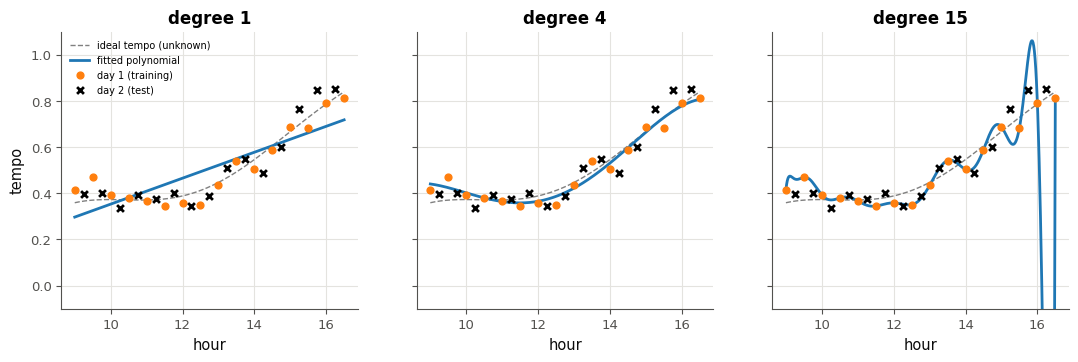

In [24]:
models_12 = {degree: make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())
             .fit(x_day1.reshape(-1, 1), tempo_day1) for degree in (1, 4, 15)}
train_mse_12 = [mean_squared_error(tempo_day1, models_12[d].predict(x_day1.reshape(-1, 1))) for d in (1, 4, 15)]
day2_mse_12 = [mean_squared_error(tempo_day2, models_12[d].predict(x_day2.reshape(-1, 1))) for d in (1, 4, 15)]
print("a)", [f"{value:.2e}" for value in train_mse_12], "· b)", [f"{value:.5f}" for value in day2_mse_12])
print_answer("9.12a", train_mse_12)
print_answer("9.12b", day2_mse_12)
curves_12, hours_12 = None, np.linspace(9, 16.5, 400)
if filled(models_12):
    if not (isinstance(models_12, dict) and all(hasattr(models_12.get(d), "predict") for d in (1, 4, 15))):
        print("❌ Ex 9.12 : models_12 doit être un dictionnaire {1: modèle, 4: modèle, 15: modèle} de modèles entraînés.")
    else:
        try:
            curves_12 = {d: models_12[d].predict(to_unit(hours_12).reshape(-1, 1)) for d in (1, 4, 15)}
        except NotFittedError:
            print("❌ Ex 9.12 : un modèle de models_12 n'est pas entraîné : appelle fit sur la première journée.")
if curves_12 is not None:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
    for ax, degree_12 in zip(axes, (1, 4, 15)):
        ax.plot(hours_12, tempo_ideal(hours_12), color="gray", ls="--", lw=1, label="ideal tempo (unknown)")
        ax.plot(hours_12, curves_12[degree_12], color="tab:blue", lw=2, label="fitted polynomial")
        ax.scatter(hour_day1, tempo_day1, color="tab:orange", s=24, zorder=3, label="day 1 (training)")
        ax.scatter(hour_day2, tempo_day2, color="black", marker="x", s=24, zorder=3, label="day 2 (test)")
        ax.set(title=f"degree {degree_12}", xlabel="hour", ylim=(-0.1, 1.1))
    axes[0].set_ylabel("tempo")
    axes[0].legend(fontsize=7, loc="upper left")
    plt.show()

In [25]:
raw_12 = {d: make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
          .fit(hour_day1.reshape(-1, 1), tempo_day1) for d in (1, 4, 15)}       # the raw hours: a classic slip
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    raw_train_12 = [mean_squared_error(tempo_day1, raw_12[d].predict(hour_day1.reshape(-1, 1))) for d in (1, 4, 15)]
    raw_day2_12 = [mean_squared_error(tempo_day2, raw_12[d].predict(hour_day2.reshape(-1, 1))) for d in (1, 4, 15)]
wb.record("9.12a", train_mse_12, decimals=5, mistakes={
    "c'est la RMSE (la racine) : la question demande la MSE": np.sqrt(train_mse_12).tolist(),
    "avec les heures brutes (9 à 16,5), les puissances jusqu'à 15 dépassent 10¹⁸ et le calcul perd sa précision : travaille avec x_day1": raw_train_12})
wb.record("9.12b", day2_mse_12, decimals=5, mistakes={
    "c'est la MSE de la première journée : la question porte sur le lendemain": train_mse_12,
    "c'est la RMSE (la racine) : la question demande la MSE": np.sqrt(day2_mse_12).tolist(),
    "avec les heures brutes (9 à 16,5), les puissances jusqu'à 15 dépassent 10¹⁸ et le calcul perd sa précision : travaille avec x_day2": raw_day2_12})

WB_ANSWER {"decimals": 5, "element_coarse": [["8edb8825971e14011f77cafc28e72ae2b9f222838eabb1d5fcf1c4f0262e89dc"], ["a28ca72b36b697d5ea7f6954a062d48b9f79210255d176ff7dccddf70da0882f"], ["2767c0e8672573abab1dc955fe2bbb3b124101f6889ccc84f5eb3bc0c413cc15"]], "element_hashes": ["049f885a365759a305cbce28fd5a17d9f7704086ad347e86c1e6cfca0e5fb694", "2ad9eecccb6608c49dfdfbc424e0cbb82178b406fee203bfbbe45d091bba1939", "6babe40c673f85d1e8546bbc247ae4337681fca1e3454cd49545c8b7503868b9"], "hash": "e06fa82368193514e9dade7263cafcaa162dcc1519834e2dc660c18cb0086993", "id": "9.12a", "kind": "array", "mistakes": {"9d05798f7e62f1c20a8ea304f14d1be399bab6c61093f71970a064fb4fcfb50f": "avec les heures brutes (9 à 16,5), les puissances jusqu'à 15 dépassent 10¹⁸ et le calcul perd sa précision : travaille avec x_day1", "d09cf416dc700b710e5a74f461f99093507b033d7cbd33038d4fc0fc69fe209f": "c'est la RMSE (la racine) : la question demande la MSE"}, "shape": [3]}
📝 Ex 9.12a : réponse enregistrée (array, 5 décimale(s)).

💡 Le degré 1 rate la forme de la journée (le calme du matin, l'entrain de la fin d'après-midi) : ses deux MSE sont proches et hautes, c'est l'underfitting, le rôle de la figure 9.4 du livre. Le degré 4 suit la forme sans suivre chaque hésitation : la plus petite MSE du lendemain, le rôle de la figure 9.5. Le degré 15 a 16 coefficients (avec l'ordonnée à l'origine) pour 16 réglages : il passe exactement par chacun (MSE d'entraînement de l'ordre de $10^{-25}$, c'est-à-dire 0 aux arrondis près), et le lendemain sa MSE est la plus grande des trois, c'est l'overfitting de la figure 9.3. Entre deux réglages il oscille, surtout près des bords, où rien ne le retient : pour 16 h 15, il propose −1,27, un tempo impossible, et ce seul réglage fait 99 % de sa MSE du lendemain.

### Ex 9.13 — Erreurs d'entraînement et de test selon le degré : ta courbe d'abord 🔮 ★ ⏱️ 15 min
**Objectif :** prévoir, avant de les mesurer, l'erreur d'entraînement et l'erreur de test des polynômes de degré 0 à 15.  
**Prérequis :** Ex 9.12 · fiche §9.2.1 et §9.2.2 · **Fil rouge :** synthétique (la boutique) · **Parcours :** C

Sur la boutique de 9.12, on va ajuster les polynômes de tous les degrés de 0 (une constante : la moyenne des 16 réglages) à 15 et mesurer, pour chacun, la MSE sur la première journée et celle du lendemain. 9.12 t'a montré trois de ces seize polynômes. Avant tout calcul, esquisse sur papier les deux courbes en fonction du degré ; la fiche (« L'essentiel », point 8) annonce la forme en U de la seconde. Prédis maintenant trois détails :

a) `prediction_13a` : parmi les degrés 0 à 15, **combien** font strictement mieux que le degré 1 le lendemain (une MSE du lendemain plus petite) ? Un entier de 0 à 15 ;
b) `prediction_13b` : la tranche où tombe le degré de la plus petite MSE du lendemain : `"A"` de 0 à 2 ; `"B"` de 3 à 6 ; `"C"` de 7 à 11 ; `"D"` de 12 à 15 ;
c) `prediction_13c` : le plus petit degré dont la MSE du lendemain dépasse celle de la constante (degré 0), un entier de 1 à 15.

Puis exécute l'expérience ; les questions à noter viennent après elle.

In [26]:
prediction_13a, prediction_13b, prediction_13c = 10, "B", 14   # the answers, for the record

In [27]:
wb.record("9.13a", prediction_13a, fractional="un nombre de degrés est entier", mistakes={
    "le degré 1 lui-même ne compte pas : la question demande ceux qui font strictement mieux que lui": 11})
wb.record("9.13b", prediction_13b, mistakes={
    "les degrés 2 et 3 font presque aussi bien, mais le minimum est un peu plus loin : relis le tableau de l'expérience": "A",
    "au-delà du degré 6, la MSE du lendemain remonte : relis le tableau de l'expérience": "C",
    "les grands degrés suivent les hésitations du premier jour : leur MSE du lendemain est la plus grande": "D"})
wb.record("9.13c", prediction_13c, fractional="un degré est un nombre entier", mistakes={
    "au degré 15, la MSE du lendemain dépasse bien celle de la constante, mais un degré plus petit la dépasse déjà : relis le tableau": 15,
    "aux degrés 12 et 13, la MSE du lendemain (environ 0,011) reste sous celle de la constante (0,030) : relis le tableau": 12})

WB_ANSWER {"fractional": "un nombre de degrés est entier", "hash": "5895837bae682f58ecc99f7fd1aede1cb58cdafac860bf2c5a88c4c2f3a04888", "id": "9.13a", "kind": "int", "magnitude": 1, "mistakes": {"be3fc4b39a509d0170e6856e34a92795187417920041a2a4e3ec947be21de016": "le degré 1 lui-même ne compte pas : la question demande ceux qui font strictement mieux que lui"}, "sign": 1}
📝 Ex 9.13a : réponse enregistrée (int).
WB_ANSWER {"hash": "42684ac5926b2ad14a74dfda9dc4a74bf7e650bce57cf57e3b9ba998af6d5aa8", "id": "9.13b", "kind": "str", "mistakes": {"1c67cba2183ea664797905b3e0a3019e6300680e0c77611ed947220095fdfbd6": "au-delà du degré 6, la MSE du lendemain remonte : relis le tableau de l'expérience", "4fed0d43bb1cd83ccacc02558eeec17209a49f3204bd00ed7ef5f33daadaa2fd": "les grands degrés suivent les hésitations du premier jour : leur MSE du lendemain est la plus grande", "7cceb9ad21613ec3a66a8f0927669cdded718e38bdb2c34117aee0e75b13bd07": "les degrés 2 et 3 font presque aussi bien, mais le minimum est

degree  0: MSE day 1 2.39e-02 · day 2 2.98e-02
degree  1: MSE day 1 7.17e-03 · day 2 8.38e-03
degree  2: MSE day 1 1.30e-03 · day 2 2.68e-03
degree  3: MSE day 1 1.08e-03 · day 2 2.68e-03
degree  4: MSE day 1 8.14e-04 · day 2 2.46e-03
degree  5: MSE day 1 6.70e-04 · day 2 3.09e-03
degree  6: MSE day 1 6.31e-04 · day 2 2.97e-03
degree  7: MSE day 1 6.28e-04 · day 2 2.92e-03
degree  8: MSE day 1 5.64e-04 · day 2 3.01e-03
degree  9: MSE day 1 5.11e-04 · day 2 2.92e-03
degree 10: MSE day 1 4.42e-04 · day 2 3.58e-03
degree 11: MSE day 1 2.70e-04 · day 2 3.28e-03
degree 12: MSE day 1 1.29e-04 · day 2 1.11e-02
degree 13: MSE day 1 1.21e-04 · day 2 1.14e-02
degree 14: MSE day 1 3.59e-06 · day 2 1.46e-01
degree 15: MSE day 1 1.50e-25 · day 2 3.06e-01
a) degrees with a smaller MSE on day 2 than degree 1: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11] -> 10
b) degree of the smallest MSE on day 2: 4
c) smallest degree whose MSE on day 2 is larger than that of the constant: 14
   smallest degree with a zero trai

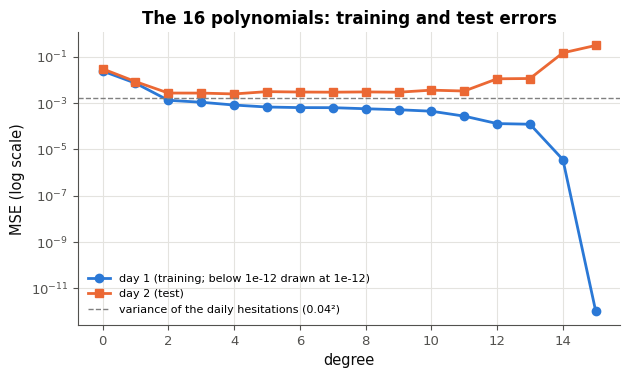

In [28]:
if any(answer is ... or answer is None for answer in [prediction_13a, prediction_13b, prediction_13c]):
    print("⏳ Ex 9.13 : écris d'abord tes trois prédictions, puis relance cette cellule.")
else:
    train_13, day2_13 = [], []
    for degree_13 in range(16):
        if degree_13 == 0:                                 # degree 0: a constant, the mean of the 16 settings
            pred1_13 = np.full(len(tempo_day1), tempo_day1.mean())
            pred2_13 = np.full(len(tempo_day2), tempo_day1.mean())
        else:
            model_13 = make_pipeline(PolynomialFeatures(degree_13, include_bias=False), LinearRegression())
            model_13.fit(x_day1.reshape(-1, 1), tempo_day1)
            pred1_13 = model_13.predict(x_day1.reshape(-1, 1))
            pred2_13 = model_13.predict(x_day2.reshape(-1, 1))
        train_13.append(mean_squared_error(tempo_day1, pred1_13))
        day2_13.append(mean_squared_error(tempo_day2, pred2_13))
    for degree_13 in range(16):
        print(f"degree {degree_13:2d}: MSE day 1 {train_13[degree_13]:.2e} · day 2 {day2_13[degree_13]:.2e}")
    print("a) degrees with a smaller MSE on day 2 than degree 1:", [d for d in range(16) if day2_13[d] < day2_13[1]],
          "->", sum(day2_13[d] < day2_13[1] for d in range(16)))
    print("b) degree of the smallest MSE on day 2:", int(np.argmin(day2_13)))
    print("c) smallest degree whose MSE on day 2 is larger than that of the constant:",
          next(d for d in range(1, 16) if day2_13[d] > day2_13[0]))
    print("   smallest degree with a zero training MSE (< 1e-10):", next(d for d in range(16) if train_13[d] < 1e-10))
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.semilogy(range(16), np.maximum(train_13, 1e-12), "o-", label="day 1 (training; below 1e-12 drawn at 1e-12)")
    ax.semilogy(range(16), day2_13, "s-", label="day 2 (test)")
    ax.axhline(0.04 ** 2, color="gray", ls="--", lw=1, label="variance of the daily hesitations (0.04²)")
    ax.set(xlabel="degree", ylabel="MSE (log scale)", title="The 16 polynomials: training and test errors")
    ax.legend(fontsize=8)
    plt.show()

**Ex 9.13, après l'expérience.** Dans tes notes : compare ton esquisse aux deux courbes. À partir de quel degré la MSE d'entraînement est-elle nulle, et pourquoi celui-là ? Pourquoi ne remonte-t-elle jamais quand le degré augmente ? Et pourquoi la MSE du lendemain ne descend-elle pas sous la ligne pointillée ?

💡 a) **10** : les degrés 2 à 11 font tous mieux que le degré 1 (0,0084), avec des MSE du lendemain entre 0,0025 et 0,0036 : le fond de la vallée est large et plat. b) **B** : le minimum est au degré 4, mais de peu, et le degré exact qui gagne dépend des hésitations de ces deux journées. c) **14** : les degrés 12 et 13 font encore mieux que la constante (0,011 contre 0,030) ; le degré 14 fait cinq fois pire (0,15), le degré 15 dix fois pire (0,31). La MSE d'entraînement est nulle à partir du degré 15 : avec 16 abscisses distinctes, il faut 16 coefficients pour passer par les 16 points (le degré 14 laisse une erreur de l'ordre de $10^{-6}$). Elle ne remonte jamais : un polynôme de degré $d + 1$ peut reproduire n'importe quel polynôme de degré $d$ (il suffit d'un coefficient nul), donc les moindres carrés font au moins aussi bien. La MSE du lendemain ne descend pas sous la variance des hésitations ($0{,}04^2$) : même la courbe idéale se tromperait d'autant sur des réglages bruités (§9.6 de la fiche).

### Ex 9.14 — mean_squared_error, mean_absolute_error et r2_score 🔨 ★★ ⏱️ 20 min
**Objectif :** écrire les trois mesures d'erreur d'une régression et les vérifier contre scikit-learn.  
**Prérequis :** Ex 9.1 (papier) · fiche §9.2 (encadré 🧮) · **Fil rouge :** synthétique (la boutique) · **mylearn :** `linear.py` · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme aux chapitres précédents) : ouvre `mon_travail/mylearn/linear.py` (créé par `python tools/start_chapter.py 9`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. NumPy et `itertools` sont permis ; scikit-learn non : ses fonctions (`mean_squared_error`, `PolynomialFeatures`, `LinearRegression`, `Ridge`, `Lasso`) sont les **oracles** des tests. La cellule de vérification recharge ta librairie, montre quelques résultats, puis lance les tests de ta fonction ; `python -m pytest tests/test_ch09_linear.py -q` les lance tous dans un terminal.

Écris `mean_squared_error(y_true, y_pred)`, `mean_absolute_error(y_true, y_pred)` et `r2_score(y_true, y_pred)` (lis leurs docstrings) :
- accepte des listes comme des tableaux (`np.asarray(..., dtype=float)`), et renvoie un `float` Python (`float(...)`), pas un tableau NumPy de dimension 0 ;
- lève une `ValueError` si les deux longueurs diffèrent, **même 1 contre n** (NumPy, sinon, diffuserait la valeur unique sur tout le tableau sans rien dire), ou si les tableaux sont vides ; `r2_score` exige au moins 2 exemples ;
- cible constante ($SS_{\text{tot}} = 0$) : comme scikit-learn, `r2_score` rend 1.0 si les prédictions sont parfaites, 0.0 sinon ;
- un $R^2$ peut être négatif : ne le ramène pas à 0.

La vérification essaie les exemples des docstrings, compare tes fonctions à celles de scikit-learn sur les prédictions du lendemain des trois polynômes de 9.12 (refaits ici, pour ne pas dépendre de ta réponse), puis lance leurs tests ; une fonction pas encore écrite affiche ⏳, sans empêcher la vérification des autres.

Dans tes notes : sur le lendemain, quel est le $R^2$ du degré 15, et que veut dire son signe ? Pourquoi l'écart entre le degré 4 et le degré 15 est-il plus grand en MSE qu'en MAE ?

In [29]:
REF_MODELS_14 = {degree: make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())
                 .fit(x_day1.reshape(-1, 1), tempo_day1) for degree in (1, 4, 15)}   # the three models of 9.12

In [30]:
if True:
    lin_14 = mylearn.linear
    y_doc_14, pred_doc_14 = [3, -0.5, 2, 7], [2.5, 0.0, 2, 8]
    metrics_14 = {"mean_squared_error": (lin_14.mean_squared_error, mean_squared_error, 0.375),
                  "mean_absolute_error": (lin_14.mean_absolute_error, mean_absolute_error, 0.5),
                  "r2_score": (lin_14.r2_score, r2_score, 0.9486)}
    written_14 = {}
    for name_14, (mine_14, oracle_14, doc_value_14) in metrics_14.items():
        try:
            value_14 = mine_14(y_doc_14, pred_doc_14)
        except NotImplementedError:
            print(f"⏳ Ex 9.14 : {name_14} pas encore écrite.")
            continue
        if returned("9.14", name_14, value_14):
            print(f"docstring example of {name_14}: {value_14!r} (expected {doc_value_14})")
            written_14[name_14] = (mine_14, oracle_14)
    if not written_14:
        raise NotImplementedError
    for name_14, (mine_14, oracle_14) in written_14.items():
        mine_values_14, oracle_values_14 = [], []
        for degree_14, model_14 in REF_MODELS_14.items():
            pred_14 = model_14.predict(x_day2.reshape(-1, 1))
            mine_values_14.append(mine_14(tempo_day2, pred_14))
            oracle_values_14.append(oracle_14(tempo_day2, pred_14))
        if any(value is None for value in mine_values_14):
            print(f"❌ Ex 9.14 : {name_14} renvoie None : as-tu oublié le return ?")
            continue
        print(f"{name_14} on day 2, degrees 1, 4 and 15:", [round(float(value), 5) for value in mine_values_14])
        verdict("9.14", np.allclose(np.asarray(mine_values_14, dtype=float), oracle_values_14, rtol=1e-9, atol=1e-12),
                f"{name_14} donne les valeurs de scikit-learn sur les trois polynômes.",
                f"{name_14} diffère de scikit-learn ({np.round(oracle_values_14, 5).tolist()}) : relis sa formule dans "
                "l'encadré 🧮 de la fiche (§9.2).")
    run_mylearn_tests(impl="ref", keyword=" or ".join(f"test_{name_14}_" for name_14 in written_14))

docstring example of mean_squared_error: 0.375 (expected 0.375)
docstring example of mean_absolute_error: 0.5 (expected 0.5)
docstring example of r2_score: 0.9486081370449679 (expected 0.9486)
mean_squared_error on day 2, degrees 1, 4 and 15: [0.00838, 0.00246, 0.30569]
✅ Ex 9.14 : mean_squared_error donne les valeurs de scikit-learn sur les trois polynômes.
mean_absolute_error on day 2, degrees 1, 4 and 15: [0.07539, 0.04386, 0.18652]
✅ Ex 9.14 : mean_absolute_error donne les valeurs de scikit-learn sur les trois polynômes.
r2_score on day 2, degrees 1, 4 and 15: [0.71867, 0.91753, -9.26003]
✅ Ex 9.14 : r2_score donne les valeurs de scikit-learn sur les trois polynômes.


pytest: 35 passed, 118 deselected in 0.74s


💡 Sur le lendemain : MSE 0,00838 ; 0,00246 et 0,306 ; MAE 0,075 ; 0,044 et 0,187 ; $R^2$ 0,72 ; 0,92 et −9,26. Un $R^2$ négatif dit que le degré 15 fait bien pire que la constante égale à la moyenne des réglages du lendemain. La MSE met chaque erreur au carré : les grosses erreurs du degré 15 près des bords pèsent beaucoup plus que dans la MAE (rapport 124 entre degré 15 et degré 4 en MSE, 4 en MAE). Dans la référence, une petite fonction auxiliaire contrôle les deux tableaux (même longueur, taille minimale) avant chaque calcul.

### Ex 9.15 — polynomial_features, interactions comprises 🔨 ★★ ⏱️ 25 min
**Objectif :** écrire les features polynomiales (puissances et interactions) dans l'ordre de scikit-learn.  
**Prérequis :** 0A (`itertools`, produits de colonnes) · fiche §9.3 (encadré 🧮 sur les features polynomiales) · **mylearn :** `linear.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/linear.py`, mêmes règles qu'en 9.14 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `polynomial_features(X, degree=2, include_bias=False)` (lis sa docstring) :
- un tableau à **une** dimension est **une** feature (une colonne), pas un exemple ;
- les colonnes viennent degré par degré (le degré 1, puis 2…), et, dans chaque degré, dans l'ordre de `itertools.combinations_with_replacement(range(p), d)` : chaque combinaison d'indices donne le produit des colonnes correspondantes (par exemple `(0, 0, 2)` donne $x_0^2 x_2$) ;
- `include_bias=True` ajoute d'abord une colonne de 1 ; par défaut (`False`), il n'y en a pas, contrairement à `PolynomialFeatures` de scikit-learn, qui l'ajoute par défaut ;
- le résultat est un tableau de `float` ; lève une `ValueError` si `degree < 1` ou si `X` a plus de 2 dimensions.

a) Avant d'exécuter quoi que ce soit, calcule à la main `n_columns_15` : le nombre de colonnes que ta fonction doit produire pour 4 features et le degré 3, sans la colonne de 1 (formule de l'encadré de la fiche).

La vérification contrôle ton nombre, essaie les exemples de la docstring, compare ta fonction à `PolynomialFeatures` sur des données à 4 features, puis lance les tests.

Dans tes notes : combien de colonnes pour les 8 features de California au degré 3 ? Quelle part de ces colonnes sont des interactions (des produits d'au moins deux features différentes) ?

In [31]:
n_columns_15 = math.comb(4 + 3, 3) - 1                      # C(p + d, d) - 1
print("a)", n_columns_15)
print_answer("9.15", n_columns_15)
if True:
    lin_15 = mylearn.linear
    print("docstring examples:")
    print(lin_15.polynomial_features(np.array([[2.0, 3.0], [1.0, -1.0]]), degree=2))
    print(lin_15.polynomial_features(np.array([2.0, 3.0]), degree=3, include_bias=True))
    X_15 = np.random.default_rng(915).normal(size=(6, 4))
    P_15 = lin_15.polynomial_features(X_15, degree=3)
    if returned("9.15", "polynomial_features", P_15):
        P_15 = np.asarray(P_15)
        oracle_15 = PolynomialFeatures(3, include_bias=False).fit_transform(X_15)
        verdict("9.15", P_15.shape == oracle_15.shape and np.allclose(P_15, oracle_15),
                f"4 features au degré 3 : {oracle_15.shape[1]} colonnes, celles de PolynomialFeatures, dans le même ordre.",
                f"attendu un tableau de forme {oracle_15.shape}, les colonnes de PolynomialFeatures(3, include_bias=False) "
                f"dans le même ordre ; reçu une forme {P_15.shape}.")
        P8_15 = lin_15.polynomial_features(X_cal[:5], degree=3)
        if returned("9.15", "polynomial_features", P8_15) and np.ndim(P8_15) == 2:
            print("the 8 features of California at degree 3:", np.shape(P8_15)[1], "columns")
    run_mylearn_tests(impl="ref", keyword="test_polynomial_features_")

a) 34
9.15: 34
docstring examples:
[[ 2.  3.  4.  6.  9.]
 [ 1. -1.  1. -1.  1.]]
[[ 1.  2.  4.  8.]
 [ 1.  3.  9. 27.]]
✅ Ex 9.15 : 4 features au degré 3 : 34 colonnes, celles de PolynomialFeatures, dans le même ordre.
the 8 features of California at degree 3: 164 columns


pytest: 18 passed, 135 deselected in 0.73s


In [32]:
wb.record("9.15", n_columns_15, fractional="un nombre de colonnes est entier", mistakes={
    "c'est le nombre avec la colonne de 1 : la question l'exclut": 35,
    "il manque les produits croisés (les interactions)": 12,
    "ce sont seulement les monômes de degré 3 exactement : ajoute ceux de degré 1 et 2": 20,
    "x₀x₁ et x₁x₀ sont le même monôme : compte les combinaisons, pas les suites ordonnées": 84})

WB_ANSWER {"fractional": "un nombre de colonnes est entier", "hash": "de2a7f8dd7ba7e0b1201984bc83b6dd2b57570170187e96d137de16af3158ea0", "id": "9.15", "kind": "int", "magnitude": 1, "mistakes": {"2124b66689cf9020be2833b1037fe1b1554d7d896d9d2d982566c7b71032c46a": "il manque les produits croisés (les interactions)", "69eb6f20a8c09b7aa1f72571c8d7cff88543686640209baff91f4ef35acb42ea": "c'est le nombre avec la colonne de 1 : la question l'exclut", "90312a426da3546b2da46c1e70627598e4a34ec4baea77afddb4a8bb383c85ab": "x₀x₁ et x₁x₀ sont le même monôme : compte les combinaisons, pas les suites ordonnées", "a7a20fabda3448db9ab517c9009e270797f4ed09636c4e62c8ffdf96776c92c7": "ce sont seulement les monômes de degré 3 exactement : ajoute ceux de degré 1 et 2"}, "sign": 1}
📝 Ex 9.15 : réponse enregistrée (int).


💡 $\binom{4+3}{3} - 1 = 34$ colonnes : 4 de degré 1, 10 de degré 2 et 20 de degré 3. Pour les 8 features de California, $\binom{11}{3} - 1 = 164$ colonnes, dont 8 puissances pures de degré 1, 8 de degré 2 et 8 de degré 3 : les 140 autres (85 %) sont des interactions. La référence parcourt les degrés, puis `combinations_with_replacement`, et multiplie les colonnes avec `np.prod(X[:, combo], axis=1)` ; une version plus rapide multiplie une colonne du degré précédent par une feature, au lieu de tout recalculer.

### Ex 9.16 — LinearRegression par moindres carrés 🔨 ★★ ⏱️ 30 min
**Objectif :** écrire la régression linéaire par moindres carrés, avec centrage et `np.linalg.lstsq`, et la vérifier contre scikit-learn.  
**Prérequis :** Ex 9.14 · ∂ 9.2 · 0B (produit matriciel, transposée) · fiche §9.3 (« Les moindres carrés ») · **Fil rouge :** California · **mylearn :** `linear.py` · **Parcours :** R, C, M

> **mylearn** : dans `mon_travail/mylearn/linear.py`, mêmes règles qu'en 9.14 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris la classe `LinearRegression` (lis sa docstring) :
- `fit(X, y)` : avec `fit_intercept=True`, **centre** `X` et `y` (retire à chaque colonne de `X` sa moyenne, à `y` la sienne), résous les moindres carrés sur les données centrées avec `np.linalg.lstsq(Xc, yc, rcond=None)[0]`, puis retrouve $b = \bar{y} - \bar{\mathbf{x}} \cdot \mathbf{w}$ ; avec `fit_intercept=False`, résous directement sur `X` et `y`, et `intercept_` vaut `0.0` ;
- quand des colonnes sont redondantes (deux colonnes identiques, ou plus de features que d'exemples), `lstsq` rend la solution de norme minimale **sur les données centrées** : c'est celle qu'attendent les tests, comme scikit-learn ;
- `coef_` est un tableau de forme `(n_features,)`, `intercept_` un `float` Python ; `fit` renvoie `self` et ne crée que des attributs appris, dont le nom finit par `_`, ou privés, dont le nom commence par `_` : jamais un attribut public comme `self.x_mean` (la convention de `clone`, ch. 8 ; un test le vérifie) ;
- `predict(X)` rend `X @ coef_ + intercept_` ; `score(X, y)` rend le $R^2$ de tes prédictions, avec **ton** `r2_score` (9.14) ;
- lève une `ValueError` si `X` n'a pas 2 dimensions ou si `len(X) != len(y)`.

La vérification essaie l'exemple de la docstring, ajuste ta régression sur les 15 184 districts d'entraînement de California (`X_cal[TRAIN_CAL]`), compare ses poids à ceux de scikit-learn, vérifie son $R^2$ sur les 3 796 districts de test, puis lance les tests.

Dans tes notes : quel poids est le plus grand en valeur absolue ? Peux-tu en conclure que cette feature est la plus importante ? (Regarde les unités des colonnes.)

In [33]:
if True:
    doc_16 = fitted(mylearn.linear.LinearRegression(), np.array([[1.0], [2.0], [3.0]]), np.array([3.0, 5.0, 7.0]))
    if not has_weights("9.16", doc_16):
        raise NotImplementedError("LinearRegression.fit ne crée pas encore coef_ et intercept_")
    print("docstring example: coef_ =", np.round(np.asarray(doc_16.coef_, dtype=float), 4).tolist(),
          "· intercept_ =", round(float(doc_16.intercept_), 4))
    model_16 = fitted(mylearn.linear.LinearRegression(), X_cal[TRAIN_CAL], y_cal[TRAIN_CAL])
    oracle_16 = LinearRegression().fit(X_cal[TRAIN_CAL], y_cal[TRAIN_CAL])
    coef_16 = np.asarray(model_16.coef_, dtype=float)
    same_16 = (coef_16.shape == (8,) and np.allclose(coef_16, oracle_16.coef_, rtol=1e-6, atol=1e-9)
               and abs(float(model_16.intercept_) - oracle_16.intercept_) < 1e-6)
    verdict("9.16", same_16, "les mêmes poids et la même ordonnée à l'origine que LinearRegression de scikit-learn.",
            "tes poids ou ton ordonnée à l'origine diffèrent de ceux de scikit-learn : centre X et y, résous avec "
            "np.linalg.lstsq, puis retrouve b avec les moyennes.")
    if coef_16.shape == (8,):
        print("weights:", ", ".join(f"{name} {weight:+.4f}" for name, weight in zip(FEATURES_CAL, coef_16)))
    r2_16 = model_16.score(X_cal[TEST_CAL], y_cal[TEST_CAL])
    if returned("9.16", "score", r2_16):
        print_answer("9.16", r2_16, computed=True)
    run_mylearn_tests(impl="ref", keyword="test_linear_regression_")

docstring example: coef_ = [2.0] · intercept_ = 1.0
✅ Ex 9.16 : les mêmes poids et la même ordonnée à l'origine que LinearRegression de scikit-learn.
weights: MedInc +0.4448, HouseAge +0.0103, AveRooms -0.1292, AveBedrms +1.0744, Population +0.0001, AveOccup -0.3198, Latitude -0.3900, Longitude -0.3861
9.16: 0.6473349834311188


pytest: 18 passed, 135 deselected in 0.74s


In [34]:
r2_train_16 = model_16.score(X_cal[TRAIN_CAL], y_cal[TRAIN_CAL])
wb.record("9.16", r2_16, decimals=4, mistakes={
    "c'est le R² sur les districts d'entraînement : la question porte sur les districts de test": r2_train_16})

WB_ANSWER {"decimals": 4, "hash": "49c4e9e830872d82a656b4b5c3b021b78f86654298dda4d4bb61e4c71410a730", "hash_coarse": "6687558e9f4aa05337c7448d36633f0cc6c9c426372d41691e7fada595e6bc12", "id": "9.16", "kind": "float", "magnitude": -1, "mistakes": {"f4aabcd643d89aaf5147f85a79d644e0ff352b151268025200aeba080aab8f63": "c'est le R² sur les districts d'entraînement : la question porte sur les districts de test"}, "sign": 1}
📝 Ex 9.16 : réponse enregistrée (float, 4 décimale(s)).


💡 Le $R^2$ de test vaut 0,647 (0,642 sur l'entraînement : un modèle aussi rigide ne sur-apprend pas, et ce découpage-là lui donne même un test un peu plus facile). Le plus grand poids en valeur absolue est celui de `AveBedrms` (+1,07 par chambre et par ménage), et celui de `Population` est minuscule ($6 \cdot 10^{-5}$ par habitant). Mais un poids s'exprime dans l'unité de sa feature : une chambre de plus par ménage est un écart énorme (l'écart-type de `AveBedrms` vaut 0,11), un habitant de plus un écart négligeable (écart-type : 880 habitants). Multipliés par l'écart-type de leur feature, les poids se classent tout autrement : `Latitude` (−0,84), `Longitude` (−0,77) et `MedInc` (+0,69) en tête, `AveBedrms` (+0,12) et `Population` (+0,05) en queue. Pour comparer des poids, il faut des features à la même échelle (le z-score, 9.22), et même alors, un poids ne mesure pas à lui seul l'importance d'une feature (ch. 15 et B6). La référence centre, appelle `lstsq`, puis retrouve l'ordonnée à l'origine ; `score` réutilise `r2_score`.

### Ex 9.17 — Ridge en forme fermée, intercept non pénalisé 🔨 ★★ ⏱️ 30 min
**Objectif :** écrire la régression Ridge par les équations normales pénalisées, sans pénaliser l'ordonnée à l'origine.  
**Prérequis :** Ex 9.14 · Ex 9.16 · ∂ 9.3 · fiche §9.5 (encadré 🧮 « Ridge en forme fermée ») · **Fil rouge :** synthétique (la boutique) · **mylearn :** `linear.py` · **Parcours :** R, C, M

> **mylearn** : dans `mon_travail/mylearn/linear.py`, mêmes règles qu'en 9.14 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris la classe `Ridge` (lis sa docstring) :
- `fit(X, y)` vérifie d'abord `alpha` : une `ValueError` si `alpha < 0`, levée dans `fit` (`__init__` ne fait que ranger ses deux hyperparamètres) ;
- puis, avec `fit_intercept=True`, centre `X` et `y`, et résous $(\mathbf{X}_c^\top\mathbf{X}_c + \alpha\,\mathbf{I})\,\mathbf{w} = \mathbf{X}_c^\top\mathbf{y}_c$ avec `np.linalg.solve` (jamais d'inverse) ; l'ordonnée à l'origine $b = \bar{y} - \bar{\mathbf{x}} \cdot \mathbf{w}$ n'est **pas** pénalisée ;
- `alpha = 0` redonne les moindres carrés (quand $\mathbf{X}_c^\top\mathbf{X}_c$ est inversible) ;
- mêmes conventions que `LinearRegression` : `coef_`, `intercept_` (un `float`, `0.0` sans ordonnée à l'origine), `fit` qui renvoie `self` sans créer d'attribut public, `predict`, `score` avec ton `r2_score`, et les mêmes `ValueError`.

La vérification essaie l'exemple de la docstring, compare tes poids à ceux de `Ridge` de scikit-learn sur les features polynomiales de degré 15 de la boutique (standardisées avec les 16 réglages de la première journée) pour trois valeurs de `alpha`, vérifie leurs trois MSE du lendemain, dessine les trois courbes, puis lance les tests.

Dans tes notes : avec quelle valeur de `alpha` le degré 15 devient-il raisonnable ? Que devient la courbe quand `alpha` est très grand, et pourquoi tend-elle vers une constante plutôt que vers 0 ?

In [35]:
poly_17 = PolynomialFeatures(15, include_bias=False)
P_day1_17 = poly_17.fit_transform(x_day1.reshape(-1, 1))
mean_17, std_17 = P_day1_17.mean(axis=0), P_day1_17.std(axis=0)          # statistics of day 1 only
Z_day1_17 = (P_day1_17 - mean_17) / std_17                                  # the 15 columns, z-scored
Z_day2_17 = (poly_17.fit_transform(x_day2.reshape(-1, 1)) - mean_17) / std_17
ALPHAS_17 = [1e-6, 0.1, 100.0]

docstring example: coef_ = [1.3333] · intercept_ = 2.3333
✅ Ex 9.17 : les mêmes poids et la même ordonnée à l'origine que Ridge de scikit-learn, pour les trois valeurs de alpha.
degree 15, alpha = 1e-06: MSE on day 2 0.00777
degree 15, alpha = 0.1: MSE on day 2 0.00280
degree 15, alpha = 100: MSE on day 2 0.01884
9.17: [0.0078, 0.0028, 0.0188]


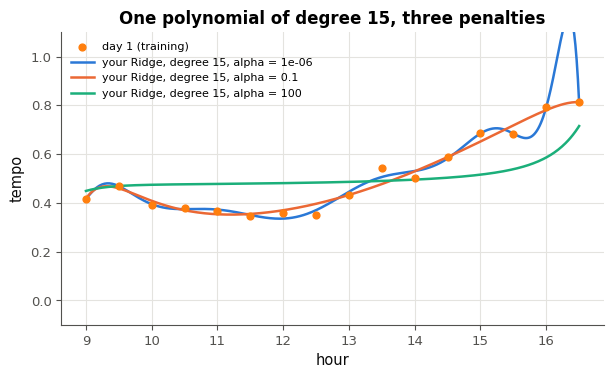

pytest: 19 passed, 134 deselected in 0.76s


In [36]:
if True:
    doc_17 = fitted(mylearn.linear.Ridge(alpha=1.0), np.array([[1.0], [2.0], [3.0]]), np.array([3.0, 5.0, 7.0]))
    if not has_weights("9.17", doc_17):
        raise NotImplementedError("Ridge.fit ne crée pas encore coef_ et intercept_")
    print("docstring example: coef_ =", np.round(np.asarray(doc_17.coef_, dtype=float), 4).tolist(),
          "· intercept_ =", round(float(doc_17.intercept_), 4))
    models_17 = {alpha: fitted(mylearn.linear.Ridge(alpha=alpha), Z_day1_17, tempo_day1) for alpha in ALPHAS_17}
    oracles_17 = {alpha: Ridge(alpha=alpha).fit(Z_day1_17, tempo_day1) for alpha in ALPHAS_17}
    same_w_17 = all(np.allclose(np.asarray(models_17[alpha].coef_, dtype=float), oracles_17[alpha].coef_, rtol=1e-5,
                                atol=1e-7) for alpha in ALPHAS_17)
    same_b_17 = all(abs(float(models_17[alpha].intercept_) - oracles_17[alpha].intercept_) < 1e-7 for alpha in ALPHAS_17)
    verdict("9.17", same_w_17 and same_b_17,
            "les mêmes poids et la même ordonnée à l'origine que Ridge de scikit-learn, pour les trois valeurs de alpha.",
            "tes poids diffèrent de ceux de Ridge de scikit-learn : relis l'encadré 🧮 « Ridge en forme fermée »."
            if not same_w_17 else
            "tes poids sont justes, mais pas ton ordonnée à l'origine : elle vaut ȳ − x̄ · w, sans pénalité (centre X et y).")
    day2_17 = [mse(tempo_day2, model.predict(Z_day2_17)) for model in models_17.values()]
    for alpha_17, value_17 in zip(ALPHAS_17, day2_17):
        print(f"degree 15, alpha = {alpha_17:g}: MSE on day 2 {value_17:.5f}")
    print_answer("9.17", day2_17, computed=True)
    hours_17 = np.linspace(9, 16.5, 400)
    Z_grid_17 = (poly_17.fit_transform(to_unit(hours_17).reshape(-1, 1)) - mean_17) / std_17
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.scatter(hour_day1, tempo_day1, color="tab:orange", s=24, zorder=3, label="day 1 (training)")
    for alpha_17, model_17 in models_17.items():
        ax.plot(hours_17, model_17.predict(Z_grid_17), lw=1.8, label=f"your Ridge, degree 15, alpha = {alpha_17:g}")
    ax.set(xlabel="hour", ylabel="tempo", ylim=(-0.1, 1.1), title="One polynomial of degree 15, three penalties")
    ax.legend(fontsize=8)
    plt.show()
    run_mylearn_tests(impl="ref", keyword="test_ridge_")

In [37]:
ones_17 = np.ones((len(tempo_day1), 1)), np.ones((len(tempo_day2), 1))
penalised_17 = [mse(tempo_day2, Ridge(alpha=alpha, fit_intercept=False).fit(np.hstack([ones_17[0], Z_day1_17]), tempo_day1)
                    .predict(np.hstack([ones_17[1], Z_day2_17]))) for alpha in ALPHAS_17]
no_intercept_17 = [mse(tempo_day2, Ridge(alpha=alpha, fit_intercept=False).fit(Z_day1_17, tempo_day1).predict(Z_day2_17))
                   for alpha in ALPHAS_17]
wb.record("9.17", day2_17, decimals=4, mistakes={
    "ton ordonnée à l'origine est pénalisée (une colonne de 1 traitée comme un poids) : centre X et y, puis b = ȳ − x̄ · w": penalised_17,
    "ton modèle n'a pas d'ordonnée à l'origine : avec fit_intercept=True, centre X et y, puis retrouve b = ȳ − x̄ · w": no_intercept_17})

WB_ANSWER {"decimals": 4, "element_coarse": [["ed7475a11c35aec87518dc482530f89ac647e94e09118b40b9440303c76a6662"], ["5cd0b31d692d11d549518e7916e02a8d674fdaec5d0c2ac6ffbfd43d2deba8d3"], ["2edc2d9788933632063e926ea1e23494b4ad7ce53fa5b6a04f7638f2513bf60d"]], "element_hashes": ["e69469a7ee6e9977ac383b0670cc4ca16ef84d20acedbbf5c8f808118f1cbe54", "ea6a82f621eb94a10afa159fbe35fe5f3ea086aa070ffaae6d9462f71dd06f95", "2aba0872bc7b2b4e5b46f9072e4ab87b6f3e1ec6ef12ba9a7210fce4f7cd120d"], "hash": "460f75048c2b3ba9cc3b350643307cfcb886fbc615df489f8c6e7a7d58d8f3e4", "id": "9.17", "kind": "array", "mistakes": {"0fa6ee075f9ce5aadcd16be781511911b4e83a0d4423aa083084c71038331ce0": "ton ordonnée à l'origine est pénalisée (une colonne de 1 traitée comme un poids) : centre X et y, puis b = ȳ − x̄ · w", "45991e578ee03da4225ed017b38a326e5826423709301fde201c5ead851eb1c1": "ton modèle n'a pas d'ordonnée à l'origine : avec fit_intercept=True, centre X et y, puis retrouve b = ȳ − x̄ · w"}, "shape": [3]}
📝 Ex 9.17 : 

💡 MSE du lendemain : 0,0078 avec `alpha` = $10^{-6}$, 0,0028 avec 0,1 et 0,019 avec 100. Même la pénalité minuscule change tout par rapport au degré 15 sans pénalité de 9.12 (0,31) : l'interpolation exacte demande des poids énormes, et la pénalité les interdit ; la courbe ondule pourtant encore entre les réglages. Avec 0,1, elle suit la forme de la journée, presque aussi bien que le degré 4 (0,0025) : la pénalité règle la capacité en continu, là où le degré la règle par crans. Avec 100, elle est trop lisse. Quand `alpha` grandit encore, tous les poids tendent vers 0, mais pas l'ordonnée à l'origine, qui n'est pas pénalisée : la courbe tend vers la moyenne des réglages, pas vers 0. La référence vérifie `alpha`, centre, puis appelle `np.linalg.solve(Xc.T @ Xc + alpha * np.eye(p), Xc.T @ yc)`.

## Partie B · Choisir la capacité : validation, early stopping et régularisation

Nouveau fil rouge, le **vent au sommet d'une montagne** (livre §9.6.1) : une mesure par jour pendant un an. `f_year` est la courbe idéale (`wind_ideal`), que la scientifique ne connaît pas ; `wind_year` les 365 mesures, la courbe idéale plus un bruit d'écart-type `NOISE_STD` = 1,5 m/s (variance 2,25) ; `x_year` les jours ramenés dans $[-1, 1]$. California revient en 9.21 et 9.22.

In [38]:
# The wind at the top of a mountain (book §9.6.1): one measurement a day for a year, an ideal curve plus noise
def wind_ideal(day):
    """The ideal wind speed (m/s) on day `day` (0 to 364): the same every year, without the daily noise."""
    t = np.asarray(day, dtype=float) / 365
    return 6 + 3 * np.sin(2 * np.pi * t + 1) + 2 * np.sin(4 * np.pi * t + 0.5)


DAYS = np.arange(365)
x_year = (DAYS - 182) / 182                   # the days mapped to [-1, 1]
f_year = wind_ideal(DAYS)                     # the ideal curve, unknown to the scientist
NOISE_STD = 1.5                               # standard deviation of the daily noise (m/s): its variance is 2.25
wind_year = f_year + np.random.default_rng(960).normal(0, NOISE_STD, 365)
print(f"{len(DAYS)} daily measurements, from {wind_year.min():.1f} to {wind_year.max():.1f} m/s")

365 daily measurements, from 0.5 to 13.6 m/s


### Ex 9.18 — Courbes de validation : le degré, puis λ 🔬 ★★ ⏱️ 30 min
**Objectif :** tracer les courbes de validation d'un polynôme en fonction de son degré, puis de sa pénalité, et choisir les deux réglages par validation croisée.  
**Prérequis :** Ex 9.17 · Ex 9.15 · ch. 8 (validation croisée) · fiche §9.3 (courbes de validation) et §9.5 · **Fil rouge :** synthétique (le vent) · **Parcours :** R, C

La scientifique n'a mesuré le vent que 40 jours dans l'année (`DAYS_18` ; `x_18` et `y_18`). Pour régler la capacité d'un polynôme sur ces 40 jours, on trace des **courbes de validation** (fiche §9.3) avec une validation croisée à 5 folds : les paires `(train_idx, val_idx)` de `FOLDS_18` (indices dans les 40 jours). Le modèle est `PolyRidge(degree, alpha)`, fourni dans la partie A : il utilise ta `Ridge`.

Écris `validation_curve_18(make_model, values, x, y, folds)` : pour chaque valeur `v` de `values`, et pour chaque paire de `folds`, entraîne un **nouveau** modèle `make_model(v)` sur la partie d'entraînement du fold, puis mesure sa MSE sur cette partie et sur la partie de validation ; fais ensuite la moyenne de chacune des deux MSE sur les 5 folds. La fonction renvoie deux listes `(train_mse, val_mse)`, une valeur par élément de `values`.

La vérification trace deux courbes : en fonction du degré (1 à 15, avec `alpha = 1e-7`, presque sans pénalité, la valeur de la figure 9.10 du livre), puis de `alpha` (de $10^{-8}$ à $10^{3}$, au degré 15). Elle vérifie :
a) le degré de la plus petite MSE de validation ;
b) la valeur de `alpha` de la plus petite MSE de validation ;
c) les valeurs de tes courbes aux deux réglages choisis : `[MSE d'entraînement, MSE de validation]` au degré choisi, puis à l'`alpha` choisi (quatre nombres) ;
d) la MSE, sur les 325 autres jours, des deux modèles choisis, réentraînés sur les 40 jours : `[degré choisi, degré 15 avec l'alpha choisi]`.

Dans tes notes : pourquoi la courbe d'entraînement descend-elle toujours quand la capacité augmente ? Pourquoi la validation remonte-t-elle de façon irrégulière au-delà du degré 8 ? Compare l'erreur de validation des modèles choisis à leur erreur sur les 325 autres jours, puis au bruit (2,25).

In [39]:
DAYS_18 = np.sort(np.random.default_rng(9187).choice(365, size=40, replace=False))   # the 40 measured days
x_18, y_18 = x_year[DAYS_18], wind_year[DAYS_18]
FOLDS_18 = list(KFold(n_splits=5, shuffle=True, random_state=918).split(x_18))      # 5 pairs (train_idx, val_idx)
OTHER_DAYS_18 = np.setdiff1d(DAYS, DAYS_18)                                          # the 325 other days: a test
DEGREES_18 = list(range(1, 16))                                                      # 1, 2, ..., 15
ALPHAS_18 = [10.0 ** k for k in range(-8, 4)]                                        # 1e-8, 1e-7, ..., 1000

9.18a: 6
9.18b: 0.1
9.18c: [1.7491, 2.639, 1.7932, 2.4801]
degree 6 (alpha = 1e-7): validation MSE 2.639, MSE on the 325 other days 2.827
degree 15, alpha = 0.1: validation MSE 2.480, MSE on the 325 other days 3.074
9.18d: [2.8272, 3.0742]


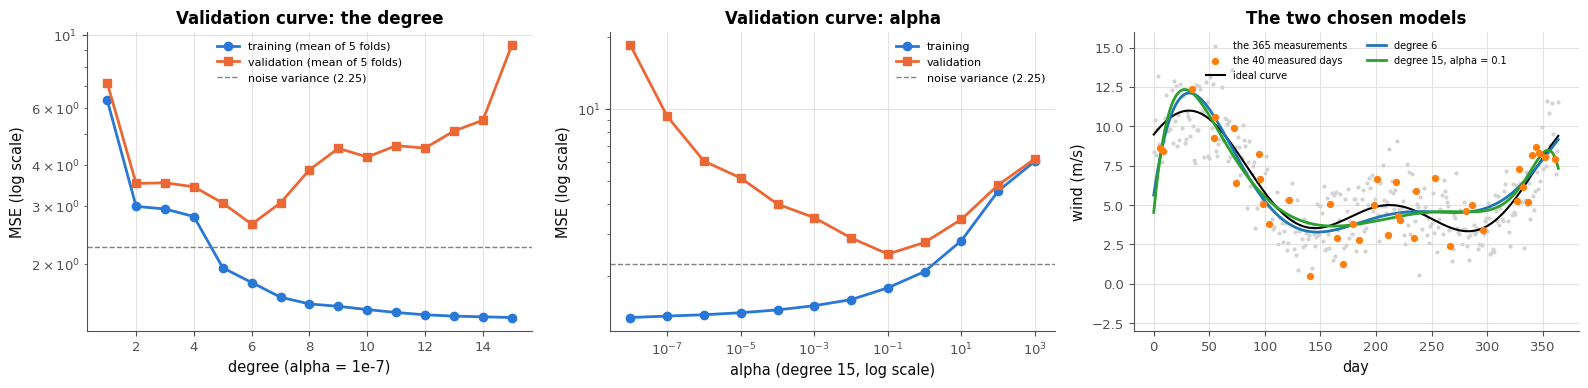

In [40]:
def validation_curve_18(make_model, values, x, y, folds):
    """For each value v of `values`: for each pair (train_idx, val_idx) of `folds`, fit make_model(v) on the
    training part, and measure its MSE on the training part and on the validation part; average over the folds.
    Returns two lists (train_mse, val_mse), one number per value, in the order of `values`."""
    train_mse, val_mse = [], []
    for value in values:
        train_scores, val_scores = [], []
        for train_idx, val_idx in folds:
            model = make_model(value)                       # a new model for each fold
            model.fit(x[train_idx], y[train_idx])
            train_scores.append(mse(y[train_idx], model.predict(x[train_idx])))
            val_scores.append(mse(y[val_idx], model.predict(x[val_idx])))
        train_mse.append(float(np.mean(train_scores)))
        val_mse.append(float(np.mean(val_scores)))
    return train_mse, val_mse


if True:
    by_degree_18 = validation_curve_18(lambda degree: PolyRidge(degree, alpha=1e-7), DEGREES_18, x_18, y_18, FOLDS_18)
    by_alpha_18 = validation_curve_18(lambda alpha: PolyRidge(15, alpha=alpha), ALPHAS_18, x_18, y_18, FOLDS_18)
    good_18 = True
    for what_18, result_18, size_18 in [("degré", by_degree_18, len(DEGREES_18)), ("alpha", by_alpha_18, len(ALPHAS_18))]:
        if not returned("9.18", "validation_curve_18", result_18):
            good_18 = False
        elif not (isinstance(result_18, (tuple, list)) and len(result_18) == 2
                  and all(np.shape(part) == (size_18,) for part in result_18)):
            print(f"❌ Ex 9.18 : validation_curve_18 doit renvoyer deux listes (train_mse, val_mse) de {size_18} nombres, "
                  f"un par {what_18}.")
            good_18 = False
    if good_18:
        train_d_18, val_d_18 = (np.asarray(part, dtype=float) for part in by_degree_18)
        train_a_18, val_a_18 = (np.asarray(part, dtype=float) for part in by_alpha_18)
        best_degree_18 = DEGREES_18[int(np.argmin(val_d_18))]
        best_alpha_18 = ALPHAS_18[int(np.argmin(val_a_18))]
        print_answer("9.18a", best_degree_18, computed=True)
        print_answer("9.18b", best_alpha_18, computed=True)
        at_choice_18 = [float(train_d_18[DEGREES_18.index(best_degree_18)]), float(val_d_18.min()),
                        float(train_a_18[ALPHAS_18.index(best_alpha_18)]), float(val_a_18.min())]
        print_answer("9.18c", at_choice_18, computed=True)
        chosen_18 = [fitted(PolyRidge(best_degree_18, alpha=1e-7), x_18, y_18), fitted(PolyRidge(15, alpha=best_alpha_18), x_18, y_18)]
        test_18 = [mse(wind_year[OTHER_DAYS_18], model.predict(x_year[OTHER_DAYS_18])) for model in chosen_18]
        print(f"degree {best_degree_18} (alpha = 1e-7): validation MSE {val_d_18.min():.3f}, MSE on the 325 other days {test_18[0]:.3f}")
        print(f"degree 15, alpha = {best_alpha_18:g}: validation MSE {val_a_18.min():.3f}, MSE on the 325 other days {test_18[1]:.3f}")
        print_answer("9.18d", test_18, computed=True)
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        axes[0].semilogy(DEGREES_18, train_d_18, "o-", label="training (mean of 5 folds)")
        axes[0].semilogy(DEGREES_18, val_d_18, "s-", label="validation (mean of 5 folds)")
        axes[0].set(xlabel="degree (alpha = 1e-7)", ylabel="MSE (log scale)", title="Validation curve: the degree")
        axes[1].loglog(ALPHAS_18, train_a_18, "o-", label="training")
        axes[1].loglog(ALPHAS_18, val_a_18, "s-", label="validation")
        axes[1].set(xlabel="alpha (degree 15, log scale)", ylabel="MSE (log scale)", title="Validation curve: alpha")
        for ax in axes[:2]:
            ax.axhline(NOISE_STD ** 2, color="gray", ls="--", lw=1, label="noise variance (2.25)")
            ax.legend(fontsize=8)
        axes[2].scatter(DAYS, wind_year, s=4, color="lightgray", label="the 365 measurements")
        axes[2].scatter(DAYS_18, y_18, s=18, color="tab:orange", zorder=3, label="the 40 measured days")
        axes[2].plot(DAYS, f_year, color="black", lw=1.5, label="ideal curve")
        axes[2].plot(DAYS, chosen_18[0].predict(x_year), color="tab:blue", label=f"degree {best_degree_18}")
        axes[2].plot(DAYS, chosen_18[1].predict(x_year), color="tab:green", label=f"degree 15, alpha = {best_alpha_18:g}")
        axes[2].set(xlabel="day", ylabel="wind (m/s)", ylim=(-3, 16), title="The two chosen models")
        axes[2].legend(fontsize=7, loc="upper center", ncol=2)
        fig.tight_layout()
        plt.show()

In [41]:
best_train_18 = DEGREES_18[int(np.argmin(by_degree_18[0]))]
wb.record("9.18a", best_degree_18, mistakes={
    "c'est le degré de la plus petite erreur d'entraînement : le choix se fait sur la validation": best_train_18})
train_best_alpha_18 = ALPHAS_18[int(np.argmin(by_alpha_18[0]))]
grid_mistakes_18 = {f"alpha = {alpha:g} est une valeur de la grille, mais pas celle de la plus petite MSE de validation : relis "
                    f"les valeurs de ta courbe": alpha for alpha in ALPHAS_18 if alpha not in (best_alpha_18, train_best_alpha_18)}
wb.record("9.18b", best_alpha_18, decimals=8, mistakes={
    "c'est l'alpha de la plus petite erreur d'entraînement : le choix se fait sur la validation": train_best_alpha_18,
    **grid_mistakes_18})
folds_rmse_18 = []                                          # a classic slip: the mean of the RMSE of the folds
for value_18, maker_18 in [(best_degree_18, lambda v: PolyRidge(v, alpha=1e-7)), (best_alpha_18, lambda v: PolyRidge(15, alpha=v))]:
    scores_18 = [(math.sqrt(mse(y_18[tr], m.predict(x_18[tr]))), math.sqrt(mse(y_18[va], m.predict(x_18[va]))))
                 for tr, va in FOLDS_18 for m in [fitted(maker_18(value_18), x_18[tr], y_18[tr])]]
    folds_rmse_18 += np.mean(scores_18, axis=0).tolist()
wb.record("9.18c", at_choice_18, decimals=5, mistakes={          # 1.7932494... sits on a 4-decimal boundary
    "ce sont des RMSE (des racines), moyennées sur les folds : la question demande des MSE": folds_rmse_18,
    "l'ordre demandé est [entraînement, validation] au degré choisi, puis à l'alpha choisi": [at_choice_18[i] for i in (1, 0, 3, 2)]})
wb.record("9.18d", test_18, decimals=4)

WB_ANSWER {"hash": "20735ed2cc499e2972fe694507df3c6455a1b79b5143679381ff05eb8a9fb113", "id": "9.18a", "kind": "int", "magnitude": 0, "mistakes": {"005fcc40aaaaa3fb191607e99a23f9d04a5a18618e66fcd814834447c2c2bfad": "c'est le degré de la plus petite erreur d'entraînement : le choix se fait sur la validation"}, "sign": 1}
📝 Ex 9.18a : réponse enregistrée (int).
WB_ANSWER {"decimals": 8, "hash": "dd91724ed09477565774f7f980d7b29dc5b03a1100d24a6a23a3bc0e2ae1244a", "hash_coarse": "70d33c96f41e5860983ffbeb5b9d7a3ca9d9b7a19b31c8842c38e591f145a502", "id": "9.18b", "kind": "float", "magnitude": -1, "mistakes": {"048b7c78c32cada7f867ecbc90f6a4f799923e247619d3cea266961eafed4990": "alpha = 1000 est une valeur de la grille, mais pas celle de la plus petite MSE de validation : relis les valeurs de ta courbe", "0bd735e10d4614113cc3d8d379d7753e1ccc88f8f3fc797c4cb51239da588d60": "alpha = 1e-06 est une valeur de la grille, mais pas celle de la plus petite MSE de validation : relis les valeurs de ta courbe

💡 La MSE d'entraînement descend toujours : plus de capacité permet toujours de suivre au moins aussi bien les points d'entraînement. La validation suit un U : elle baisse jusqu'au degré 6, remonte régulièrement jusqu'au degré 9, puis de façon irrégulière, parce que chaque fold retire 8 jours, et un polynôme presque sans pénalité extrapole n'importe comment dès qu'un fold lui retire les jours d'un bord. En fonction de `alpha`, elle dessine un U plus régulier, avec un minimum à 0,1. Les erreurs sur les 325 autres jours (2,83 et 3,07) dépassent les erreurs de validation des choix (2,64 et 2,48) : le score du meilleur de plusieurs candidats est optimiste (ch. 8). Ces quatre erreurs, mesurées sur des jours que le modèle n'a pas vus, restent au-dessus du bruit (2,25), un plancher qu'aucun modèle ne franchit en moyenne sur des données nouvelles.

### Ex 9.19 — Que deviennent les coefficients quand λ grandit ? 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir le sort de chaque coefficient d'un polynôme quand la pénalité grandit, avec Ridge et avec le Lasso.  
**Prérequis :** Ex 9.17 · ∂ 9.3 et ∂ 9.6 · fiche §9.5 · **Fil rouge :** synthétique (la boutique) · **Parcours :** C

On reprend la boutique, avec un polynôme de degré 6 : les colonnes $x, x^2, \dots, x^6$ des 16 réglages, standardisées. On trace le **chemin de régularisation** de chaque coefficient : sa valeur en fonction de `alpha`, de $10^{-4}$ à $10^{4}$ pour Ridge, de $10^{-5}$ à 1 pour le Lasso (scikit-learn). La fiche dit que la **norme** des poids baisse quand la pénalité grandit, et qu'en dimension 1 Ridge rétrécit le poids d'un facteur constant. Mais coefficient par coefficient ? Prédis :

a) `prediction_19a` : avec Ridge, la valeur absolue de **chaque** coefficient diminue-t-elle (ou reste-t-elle constante) tout au long du chemin ? (`True` ou `False`)
b) `prediction_19b` : avec Ridge, combien des six coefficients changent de signe au moins une fois ? (un entier de 0 à 6)
c) `prediction_19c` : avec le Lasso, le degré (de 1 à 6) du dernier coefficient à devenir nul ;
d) `prediction_19d` : avec le Lasso, **chaque** coefficient devenu nul le reste-t-il pour toutes les valeurs plus grandes de `alpha` ? (`True` ou `False`)

Puis exécute l'expérience ; les questions à noter viennent après elle.

In [42]:
prediction_19a, prediction_19b, prediction_19c, prediction_19d = False, 3, 1, False   # the answers

In [43]:
wb.record("9.19a", prediction_19a, mistakes={
    "la norme baisse, mais chaque coefficient ? Regarde les courbes de x² et de x⁵ sur le chemin de Ridge": True})
wb.record("9.19b", prediction_19b, fractional="un nombre de coefficients est entier", mistakes={
    "en dimension 1, un poids ne change jamais de signe ; avec des features corrélées, si : compte les courbes qui traversent 0": 0,
    "compte les courbes de Ridge qui traversent 0 : il y en a plus d'une": 1,
    "compte les courbes de Ridge qui traversent 0 : il y en a moins que six": 6})
wb.record("9.19c", prediction_19c, fractional="un degré est un nombre entier", mistakes={
    "c'est le dernier coefficient à s'annuler pour Ridge ? Ridge n'en annule aucun : regarde le chemin du Lasso": 6,
    "le coefficient de x² résiste longtemps, mais un autre résiste plus longtemps encore": 2})
wb.record("9.19d", prediction_19d, mistakes={
    "regarde la courbe de x⁵ sur le chemin du Lasso : elle s'annule, puis repart avant de s'annuler à nouveau": True})

WB_ANSWER {"hash": "e82f60aa4f7e10e47f11beaff10b7d00414460517ec0728c7eb529bc84bbb8b9", "id": "9.19a", "kind": "bool", "mistakes": {"cb0b1171737b05727a577130b4d4e40ce14dc2a94a21e4992ad29d209782bd39": "la norme baisse, mais chaque coefficient ? Regarde les courbes de x² et de x⁵ sur le chemin de Ridge"}}
📝 Ex 9.19a : réponse enregistrée (bool).
WB_ANSWER {"fractional": "un nombre de coefficients est entier", "hash": "d5b51d13678a4b619b8597dd04f637463435497d203d3d5c160fc30538827af1", "id": "9.19b", "kind": "int", "magnitude": 0, "mistakes": {"9c95f56c1fac6ebc9be074b50875f04ca6c9dd3873cb1b78be700a97f2f2bc9e": "en dimension 1, un poids ne change jamais de signe ; avec des features corrélées, si : compte les courbes qui traversent 0", "baccf801549027a396066d244adc3d64d78b3f212f2e0f13bd8a937a6001664b": "compte les courbes de Ridge qui traversent 0 : il y en a moins que six", "bedd51dbcf484c647e83417d09b71b3198520b0c55f53631c0daff8a781eb5ec": "compte les courbes de Ridge qui traversent 0 : il 

a) Ridge: degrees whose |w_j| grows somewhere when alpha grows: [2, 3, 4, 5, 6]
b) Ridge: degrees whose coefficient changes sign: [3, 5, 6] -> 3 coefficient(s)
c) Lasso: degree of the last nonzero coefficient: 1
d) Lasso: degrees whose coefficient becomes nonzero again after being 0: [5]
   Ridge: the norm of w decreases all along: True


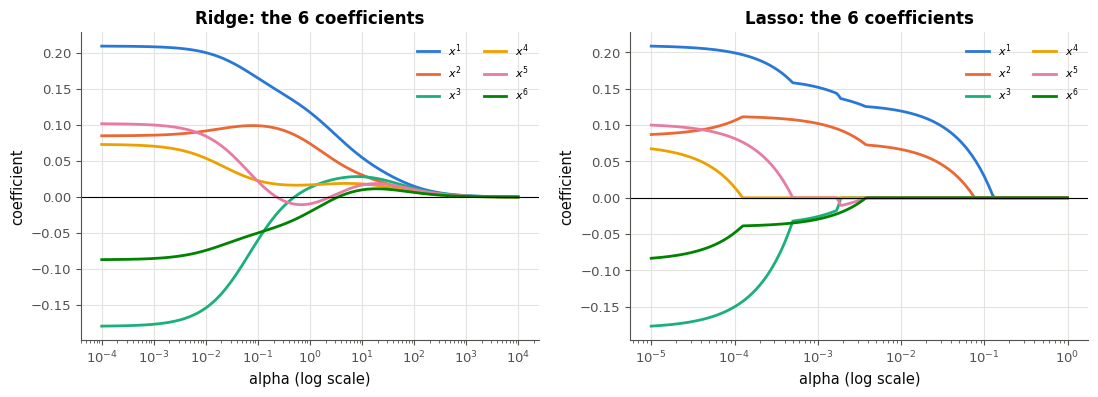

In [44]:
if any(answer is ... or answer is None for answer in [prediction_19a, prediction_19b, prediction_19c, prediction_19d]):
    print("⏳ Ex 9.19 : écris d'abord tes quatre prédictions, puis relance cette cellule.")
else:
    P_19 = PolynomialFeatures(6, include_bias=False).fit_transform(x_day1.reshape(-1, 1))
    Z_19 = (P_19 - P_19.mean(axis=0)) / P_19.std(axis=0)          # 6 columns: x, x², ..., x⁶, z-scored
    ridge_alphas_19 = np.logspace(-4, 4, 161)
    ridge_path_19 = np.array([Ridge(alpha=alpha).fit(Z_19, tempo_day1).coef_ for alpha in ridge_alphas_19])
    lasso_alphas_19 = np.logspace(-5, 0, 201)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")                   # tiny alphas: coordinate descent converges slowly
        lasso_path_19 = np.array([Lasso(alpha=alpha, tol=1e-12, max_iter=1_000_000).fit(Z_19, tempo_day1).coef_
                                  for alpha in lasso_alphas_19])
    grows_19 = [j + 1 for j in range(6) if np.any(np.diff(np.abs(ridge_path_19[:, j])) > 1e-12)]
    signs_19 = [j + 1 for j in range(6) if np.any(np.diff(np.sign(ridge_path_19[:, j])) != 0)]
    last_19 = 1 + int(np.argmax([np.flatnonzero(lasso_path_19[:, j] != 0).max() for j in range(6)]))
    back_19 = [j + 1 for j in range(6) if np.any(np.diff((lasso_path_19[:, j] != 0).astype(int)) > 0)]
    print("a) Ridge: degrees whose |w_j| grows somewhere when alpha grows:", grows_19)
    print("b) Ridge: degrees whose coefficient changes sign:", signs_19, "->", len(signs_19), "coefficient(s)")
    print("c) Lasso: degree of the last nonzero coefficient:", last_19)
    print("d) Lasso: degrees whose coefficient becomes nonzero again after being 0:", back_19)
    print("   Ridge: the norm of w decreases all along:", bool(np.all(np.diff(np.linalg.norm(ridge_path_19, axis=1)) <= 1e-12)))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for j in range(6):
        axes[0].plot(ridge_alphas_19, ridge_path_19[:, j], label=f"$x^{j + 1}$")
        axes[1].plot(lasso_alphas_19, lasso_path_19[:, j], label=f"$x^{j + 1}$")
    for ax, name in zip(axes, ["Ridge", "Lasso"]):
        ax.axhline(0, color="black", lw=0.8)
        ax.set(xscale="log", xlabel="alpha (log scale)", ylabel="coefficient", title=f"{name}: the 6 coefficients")
        ax.legend(fontsize=8, ncol=2)
    plt.show()

**Ex 9.19, après l'expérience.** Dans tes notes : pourquoi un coefficient de Ridge peut-il grandir alors que la pénalité augmente ? Pourquoi le coefficient de $x$ résiste-t-il le plus longtemps au Lasso ?

💡 a) **False** : la norme baisse tout au long du chemin, mais la valeur absolue de cinq des six coefficients remonte à un moment ; celui de $x^2$ dépasse même sa valeur sans pénalité. b) **3** : les coefficients de $x^3$, $x^5$ et $x^6$ changent de signe. c) **1** : le coefficient de $x$ s'annule le dernier, vers $\alpha = 0{,}13$, juste au seuil $\max_j |\mathbf{x}_j^\top \mathbf{y}_c| / n$ de la fiche. d) **False** : le coefficient de $x^5$ s'annule vers $5 \cdot 10^{-4}$, repart, puis s'annule pour de bon vers $4 \cdot 10^{-3}$. Les colonnes $x, x^2, \dots, x^6$ sont très corrélées : quand la pénalité grandit, le modèle redistribue le travail entre elles, et un coefficient peut grandir pour compenser ceux qui rétrécissent. « Rétrécir » est une propriété de la norme, pas de chaque poids ; elle vaut poids par poids en dimension 1 (∂ 9.3) ou quand les features sont orthogonales. Le coefficient de $x$ résiste le plus longtemps parce que $x$ est la colonne la plus corrélée à la cible : c'est elle qui explique le plus pour une même pénalité.

### Ex 9.20 — Early stopping d'une descente de gradient sur un polynôme de degré 12 🔨 ★★ ⏱️ 30 min
**Objectif :** programmer l'early stopping avec patience dans une boucle d'entraînement, et garder les bons poids.  
**Prérequis :** ch. 5 (descente de gradient) · Ex 9.5 (papier) · Ex 9.15 · fiche §9.4 · **Fil rouge :** synthétique (le vent) · **Parcours :** R, C

On ajuste un polynôme de degré 12 au vent par **descente de gradient** sur des mini-batches (ch. 5), sans pénalité : 30 jours d'entraînement (`Z_tr_20`, `y_tr_20`), 30 jours de validation (`Z_val_20`, `y_val_20`). Les lignes de `Z_20` contiennent un 1, puis les 12 puissances du jour standardisées ; le modèle est $\hat{y} = \mathbf{z} \cdot \boldsymbol{\theta}$. Deux fonctions sont fournies : `train_one_epoch_20(theta, X, y, lr, rng)` fait une epoch (trois pas de 10 lignes, dans un ordre tiré par `rng`) et modifie `theta` **sur place**, comme les optimiseurs de PyTorch ; `val_mse_20(theta, X, y)` rend la MSE.

Écris `early_stopping_20(X_tr, y_tr, X_val, y_val, patience, min_delta=0.0, max_epochs=1000, lr=0.02, seed=921)` avec la règle de la fiche (§9.4, le pseudo-code) :
- `theta` part de zéros (`np.zeros(X_tr.shape[1])`, en `float64`) ; crée **un seul** générateur `rng = np.random.default_rng(seed)`, avant la boucle ;
- à chaque epoch (numérotée à partir de 1) : `train_one_epoch_20(theta, X_tr, y_tr, lr, rng)`, puis `val_mse_20(theta, X_val, y_val)` ;
- une amélioration est une loss **strictement** inférieure à `meilleure - min_delta` : seule une amélioration met à jour la meilleure loss et la copie des poids ; on s'arrête quand `patience` epochs de suite n'ont pas amélioré ;
- renvoie `(stop_epoch, kept_epoch, kept_theta, val_losses)` : l'epoch de l'arrêt (`max_epochs` si la patience ne s'épuise jamais), l'epoch dont on garde les poids, **une copie** de ces poids, et la liste des MSE de validation de toutes les epochs faites.

La vérification lance ta fonction trois fois et contrôle :
a) avec une patience de 1 : `[epoch de l'arrêt, epoch des poids gardés]` ;
b) avec une patience de 20 : la même liste ;
c) la MSE de validation des poids que tu as gardés en b) ;
d) avec une patience de 20 et `min_delta = 0.05` : `[epoch de l'arrêt, epoch des poids gardés]` ;
puis elle trace la courbe de validation sur 1 000 epochs, et compare, sur les 305 autres jours, les poids gardés en b) à ceux de l'epoch 1 000.

Dans tes notes : pourquoi faut-il une **copie** des poids (`theta.copy()`) ? Pourquoi la patience de 1 s'arrête-t-elle trop tôt ? Que montre d) sur `min_delta` ?

In [45]:
SPLIT_20 = np.random.default_rng(920).permutation(365)
TRAIN_20, VAL_20 = np.sort(SPLIT_20[:30]), np.sort(SPLIT_20[30:60])   # 30 training days, 30 validation days
TEST_20 = np.sort(SPLIT_20[60:])                                         # the 305 other days
features_20 = PolynomialFeatures(12, include_bias=False).fit_transform(x_year.reshape(-1, 1))
mean_20, std_20 = features_20[TRAIN_20].mean(axis=0), features_20[TRAIN_20].std(axis=0)
Z_20 = np.column_stack([np.ones(365), (features_20 - mean_20) / std_20])   # a column of ones, then 12 z-scores
Z_tr_20, y_tr_20 = Z_20[TRAIN_20], wind_year[TRAIN_20]
Z_val_20, y_val_20 = Z_20[VAL_20], wind_year[VAL_20]


def train_one_epoch_20(theta, X, y, lr, rng, batch_size=10):
    """One epoch of mini-batch gradient descent on the MSE: the rows in a random order (rng), then one step per
    batch of 10 rows. Updates theta IN PLACE, as the optimisers of PyTorch do, and returns None."""
    order = rng.permutation(len(y))
    for start in range(0, len(y), batch_size):
        rows = order[start:start + batch_size]
        residual = X[rows] @ theta - y[rows]
        theta -= lr * 2 / len(rows) * (X[rows].T @ residual)


def val_mse_20(theta, X, y):
    """The MSE of the linear model theta on (X, y), as a Python float."""
    return float(np.mean((X @ theta - y) ** 2))

{'patience': 1}: stop at epoch 30, weights of epoch 29 kept
9.20a: [30, 29]
{'patience': 20}: stop at epoch 76, weights of epoch 56 kept
9.20b: [76, 56]
9.20c: 2.485703131382868
{'patience': 20, 'min_delta': 0.05}: stop at epoch 57, weights of epoch 37 kept
9.20d: [57, 37]
MSE on the 305 other days: weights kept with patience 20 3.387 · weights of epoch 1000 3.926


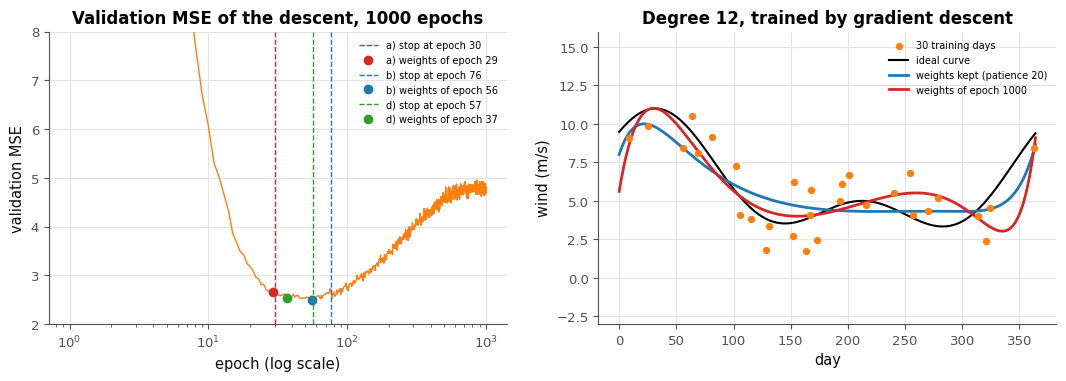

In [46]:
def early_stopping_20(X_tr, y_tr, X_val, y_val, patience, min_delta=0.0, max_epochs=1000, lr=0.02, seed=921):
    """Mini-batch gradient descent from theta = 0, stopped early on the validation MSE with the rule of the fiche.

    One generator rng = np.random.default_rng(seed), created once; each epoch calls
    train_one_epoch_20(theta, X_tr, y_tr, lr, rng), then val_mse_20(theta, X_val, y_val). Epochs are numbered from 1.
    Returns (stop_epoch, kept_epoch, kept_theta, val_losses): the epoch of the stop (max_epochs if the patience never
    runs out), the epoch whose weights are kept, a copy of those weights, and the list of the validation MSE of every
    epoch done."""
    rng = np.random.default_rng(seed)
    theta = np.zeros(X_tr.shape[1])
    best, kept_epoch, kept_theta, wait, losses = math.inf, 0, theta.copy(), 0, []
    for epoch in range(1, max_epochs + 1):
        train_one_epoch_20(theta, X_tr, y_tr, lr, rng)
        loss = val_mse_20(theta, X_val, y_val)
        losses.append(loss)
        if loss < best - min_delta:                     # a real improvement
            best, kept_epoch, kept_theta, wait = loss, epoch, theta.copy(), 0   # a COPY: theta keeps changing
        else:
            wait += 1
            if wait == patience:
                return epoch, kept_epoch, kept_theta, losses
    return max_epochs, kept_epoch, kept_theta, losses


if True:
    runs_20 = {}
    for letter_20, options_20 in [("a", dict(patience=1)), ("b", dict(patience=20)), ("d", dict(patience=20, min_delta=0.05))]:
        result_20 = early_stopping_20(Z_tr_20, y_tr_20, Z_val_20, y_val_20, **options_20)
        if not returned("9.20", "early_stopping_20", result_20):
            break
        if not (isinstance(result_20, (tuple, list)) and len(result_20) == 4):
            print("❌ Ex 9.20 : early_stopping_20 doit renvoyer (stop_epoch, kept_epoch, kept_theta, val_losses).")
            break
        runs_20[letter_20] = result_20
        print(f"{options_20}: stop at epoch {result_20[0]}, weights of epoch {result_20[1]} kept")
        print_answer(f"9.20{letter_20}", [result_20[0], result_20[1]], computed=True)
        if letter_20 == "b":
            theta_check_20 = None if result_20[2] is None else np.asarray(result_20[2], dtype=float)
            if theta_check_20 is None or theta_check_20.shape != (Z_tr_20.shape[1],):
                print(f"❌ Ex 9.20 : kept_theta doit être une copie des {Z_tr_20.shape[1]} poids gardés ; reçu "
                      f"{None if theta_check_20 is None else theta_check_20.shape}.")
            else:
                print_answer("9.20c", val_mse_20(theta_check_20, Z_val_20, y_val_20), computed=True)
    if len(runs_20) == 3:
        theta_end_20, rng_20, curve_20 = np.zeros(13), np.random.default_rng(921), []
        for _ in range(1000):                              # the same descent, without early stopping
            train_one_epoch_20(theta_end_20, Z_tr_20, y_tr_20, 0.02, rng_20)
            curve_20.append(val_mse_20(theta_end_20, Z_val_20, y_val_20))
        kept_theta_20 = np.asarray(runs_20["b"][2] if runs_20["b"][2] is not None else np.full(13, np.nan), dtype=float)
        print(f"MSE on the 305 other days: weights kept with patience 20 {val_mse_20(kept_theta_20, Z_20[TEST_20], wind_year[TEST_20]):.3f}"
              f" · weights of epoch 1000 {val_mse_20(theta_end_20, Z_20[TEST_20], wind_year[TEST_20]):.3f}")
        fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
        axes[0].plot(range(1, 1001), curve_20, color="tab:orange", lw=1)
        for (letter_20, run_20), colour_20 in zip(runs_20.items(), ["tab:red", "tab:blue", "tab:green"]):
            axes[0].axvline(run_20[0], color=colour_20, ls="--", lw=1, label=f"{letter_20}) stop at epoch {run_20[0]}")
            if isinstance(run_20[1], (int, np.integer)) and 1 <= run_20[1] <= 1000:
                axes[0].plot(run_20[1], curve_20[run_20[1] - 1], "o", color=colour_20,
                             label=f"{letter_20}) weights of epoch {run_20[1]}")
        axes[0].set(xscale="log", xlabel="epoch (log scale)", ylabel="validation MSE", ylim=(2, 8),
                    title="Validation MSE of the descent, 1000 epochs")
        axes[0].legend(fontsize=7)
        axes[1].scatter(DAYS[TRAIN_20], y_tr_20, s=18, color="tab:orange", zorder=3, label="30 training days")
        axes[1].plot(DAYS, f_year, color="black", lw=1.5, label="ideal curve")
        axes[1].plot(DAYS, Z_20 @ kept_theta_20, color="tab:blue", label="weights kept (patience 20)")
        axes[1].plot(DAYS, Z_20 @ theta_end_20, color="tab:red", label="weights of epoch 1000")
        axes[1].set(xlabel="day", ylabel="wind (m/s)", ylim=(-3, 16), title="Degree 12, trained by gradient descent")
        axes[1].legend(fontsize=7)
        plt.show()

In [47]:
stop_b_20, kept_b_20, theta_b_20, losses_b_20 = runs_20["b"]
from_zero_20 = "les epochs se numérotent à partir de 1 : la première epoch est l'epoch 1, pas l'epoch 0"
wb.record("9.20a", list(runs_20["a"][:2]), mistakes={
    from_zero_20: [runs_20["a"][0] - 1, runs_20["a"][1] - 1],
    "l'epoch de l'arrêt et celle des poids gardés diffèrent : avec une patience de 1, l'arrêt vient une epoch après la dernière amélioration": [runs_20["a"][0], runs_20["a"][0]]})
wb.record("9.20b", [stop_b_20, kept_b_20], mistakes={
    from_zero_20: [stop_b_20 - 1, kept_b_20 - 1],
    "l'epoch de la dernière amélioration ne compte pas dans l'attente : l'arrêt vient 20 epochs après elle": [stop_b_20 + 1, kept_b_20],
    "on garde les poids de la dernière amélioration, pas ceux de l'arrêt": [stop_b_20, stop_b_20]})
wb.record("9.20c", val_mse_20(theta_b_20, Z_val_20, y_val_20), decimals=4, mistakes={
    "ce sont les poids de l'epoch d'arrêt : tu as gardé une référence vers theta, que la descente continue de modifier ; garde theta.copy()": losses_b_20[stop_b_20 - 1]})
wb.record("9.20d", list(runs_20["d"][:2]), mistakes={
    from_zero_20: [runs_20["d"][0] - 1, runs_20["d"][1] - 1],
    "avec min_delta, une baisse ne compte que si elle dépasse 0,05 : seules ces vraies améliorations mettent à jour la copie des poids": [stop_b_20, kept_b_20]})

WB_ANSWER {"decimals": 0, "element_hashes": ["bb73c864f3527da5b943d9087f42699fc8ddd7c7ee0b40de57e0697939dc4756", "0a9358bbd2c722d620f9909feefcdc11d69f7fcdbf8b58485727fda0ebb48f82"], "hash": "fd6ef7d02a38a7a2256ee8e64fd2e1bb446198f80c6c98ff75218ebab50fba21", "id": "9.20a", "integer": true, "kind": "array", "mistakes": {"f34bc832156edf22ce8980e2add4f7860d89d8fc73b3979507fa570618ca616e": "les epochs se numérotent à partir de 1 : la première epoch est l'epoch 1, pas l'epoch 0", "f58d2aa4aeaab0343bfb8237920f615b418e082a9b5d1ff2577c68012b91ff3c": "l'epoch de l'arrêt et celle des poids gardés diffèrent : avec une patience de 1, l'arrêt vient une epoch après la dernière amélioration"}, "shape": [2]}
📝 Ex 9.20a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["3d896116e9133933c8a14571e8fd79f8015e8e06de347e7a662bc66f835b7004", "aab73f28f8aaa982cbc0213fef514c057aaa75efa6c569171ae8995c3df5faf8"], "hash": "04928a92ac05dd5c53e459ef58ca390d27e14fccddc19d90c85

💡 Avec une patience de 1, la descente s'arrête à l'epoch 30, sur une simple fluctuation (les mini-batches rendent la courbe bruitée), alors que la validation baisse encore. Avec une patience de 20, elle s'arrête à l'epoch 76 et garde les poids de l'epoch 56, le minimum de la courbe sur 1 000 epochs (MSE de validation 2,486). Sans arrêt, la validation remonte vers 4,7 : le polynôme de degré 12 finit par suivre le bruit des 30 jours d'entraînement. Sur les 305 autres jours, les poids gardés font 3,39, ceux de l'epoch 1 000 font 3,93. Avec `min_delta` = 0,05, l'arrêt vient plus tôt (epoch 57) et les poids gardés sont ceux de l'epoch 37, la dernière à battre de plus de 0,05 la meilleure valeur retenue (à l'epoch 56, 2,486 ne bat 2,532 que de 0,046) : pas ceux du minimum (fiche §9.4, exercice 9.5). La copie est indispensable : `train_one_epoch_20` modifie `theta` sur place, et `kept = theta` ne garderait qu'un autre nom pour le même tableau, qui continuerait de bouger jusqu'à l'arrêt.

### Ex 9.21 — Courbes d'apprentissage sur California avec learning_curve 📦 ★★ ⏱️ 30 min
**Objectif :** tracer des courbes d'apprentissage avec scikit-learn et dire si plus de données aiderait chaque modèle.  
**Prérequis :** ch. 8 (validation croisée) · Ex 9.16 · fiche §9.2.2 et §9.3 (courbes d'apprentissage) · **Fil rouge :** California · **Parcours :** R, C

Une courbe d'apprentissage (fiche §9.3) trace l'erreur d'entraînement et l'erreur de validation en fonction du **nombre d'exemples d'entraînement**. Avec `learning_curve` de scikit-learn, trace celles de trois modèles sur les 18 980 districts de California (`X_cal`, `y_cal`) :
- `"linear"` : `LinearRegression()` sur les 8 features ;
- `"degree 2"` et `"degree 3"` : `make_pipeline(ZScore(), PolynomialFeatures(d, include_bias=False), LinearRegression())`, où `ZScore` (fourni) standardise les 8 features avec les seules lignes d'entraînement de chaque tour, avant de former les puissances et les produits.

Paramètres imposés, pour que tout le monde trouve les mêmes nombres : `train_sizes=SIZES_21`, `cv=KFold(5, shuffle=True, random_state=921)`, `scoring="neg_mean_squared_error"`, `shuffle=True` et `random_state=921`. `learning_curve` renvoie trois tableaux : les tailles d'entraînement, puis les scores d'entraînement et de validation, de forme `(nombre de tailles, nombre de folds)`. Attention : scikit-learn **maximise** toujours un score ; avec ce `scoring`, il renvoie donc l'**opposé** de la MSE.

- `curves_21` : le dictionnaire `{"linear": (sizes, train_mse, val_mse), "degree 2": ..., "degree 3": ...}`, avec les MSE moyennes sur les 5 folds ;

a) `final_val_21` : les trois MSE de validation à la plus grande taille, dans l'ordre de `curves_21` ;
b) `crossing_21` : la plus petite taille d'entraînement à laquelle le polynôme de degré 3 a une MSE de validation plus petite que la régression linéaire.

Dans tes notes : quels modèles sous-apprennent, lesquels sur-apprennent avec peu de données ? Plus de données aiderait-il la régression linéaire ? Et le degré 3 ? Avec 1 000 districts, lequel choisirais-tu, et avec 15 000 ?

In [48]:
class ZScore(BaseEstimator, TransformerMixin):
    """The z-score of ch. 2 as a step of a scikit-learn pipeline: fit learns the mean and the standard deviation of
    the rows it receives (the training rows only), transform applies them. StandardScaler (ch. 12) does the same."""

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.mean_, self.std_ = X.mean(axis=0), X.std(axis=0)
        return self

    def transform(self, X):
        return (np.asarray(X, dtype=float) - self.mean_) / self.std_


SIZES_21 = [0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0]   # shares of the training part of each fold

training sizes: [151, 303, 759, 1518, 3036, 6073, 10628, 15184]
  linear: training [0.327, 0.324, 0.347, 0.339, 0.343, 0.338, 0.335, 0.337]
          validation [0.353, 0.345, 0.34, 0.338, 0.338, 0.337, 0.337, 0.337]
degree 2: training [0.198, 0.228, 0.263, 0.269, 0.277, 0.277, 0.277, 0.279]
          validation [0.44, 0.346, 0.309, 0.295, 0.288, 0.284, 0.282, 0.282]
degree 3: training [0.0, 0.099, 0.192, 0.222, 0.241, 0.25, 0.251, 0.255]
          validation [141.441, 2.755, 0.525, 0.346, 0.295, 0.273, 0.266, 0.263]
a) [0.3371, 0.282, 0.2633] · b) 3036
9.21a: [0.3371, 0.282, 0.2633]
9.21b: 3036


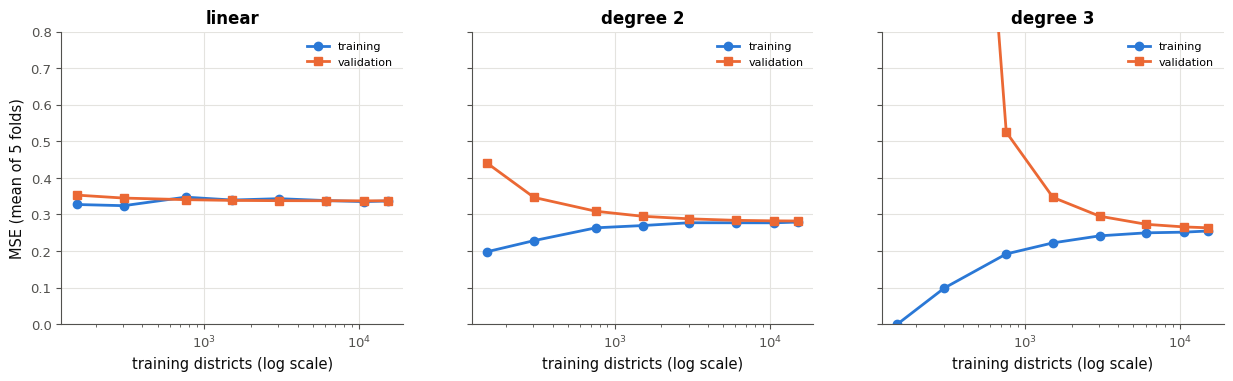

In [49]:
models_21 = {"linear": LinearRegression(),
             "degree 2": make_pipeline(ZScore(), PolynomialFeatures(2, include_bias=False), LinearRegression()),
             "degree 3": make_pipeline(ZScore(), PolynomialFeatures(3, include_bias=False), LinearRegression())}
curves_21 = {}
for name_21, model_21 in models_21.items():
    sizes_21, train_scores_21, val_scores_21 = learning_curve(
        model_21, X_cal, y_cal, train_sizes=SIZES_21, cv=KFold(5, shuffle=True, random_state=921),
        scoring="neg_mean_squared_error", shuffle=True, random_state=921)
    curves_21[name_21] = (sizes_21, -train_scores_21.mean(axis=1), -val_scores_21.mean(axis=1))   # minus: MSE
final_val_21 = [float(curves_21[name][2][-1]) for name in curves_21]
sizes_21 = curves_21["linear"][0]
crossing_21 = int(sizes_21[np.argmax(curves_21["degree 3"][2] < curves_21["linear"][2])])
print("training sizes:", sizes_21.tolist())
for name_21, (_, train_21, val_21) in curves_21.items():
    print(f"{name_21:>8s}: training {np.round(train_21, 3).tolist()}\n          validation {np.round(val_21, 3).tolist()}")
print("a)", np.round(final_val_21, 4).tolist(), "· b)", crossing_21)
print_answer("9.21a", final_val_21)
print_answer("9.21b", crossing_21)
if filled(curves_21):
    if not (isinstance(curves_21, dict) and all(isinstance(value, (tuple, list)) and len(value) == 3
                                                for value in curves_21.values())):
        print('❌ Ex 9.21 : curves_21 doit être un dictionnaire {"linear": (sizes, train_mse, val_mse), ...}.')
    else:
        fig, axes = plt.subplots(1, len(curves_21), figsize=(5 * len(curves_21), 3.8), sharey=True)
        for ax, (name_21, (sizes_21, train_21, val_21)) in zip(np.atleast_1d(axes), curves_21.items()):
            ax.plot(sizes_21, train_21, "o-", label="training")
            ax.plot(sizes_21, val_21, "s-", label="validation")
            ax.set(xscale="log", xlabel="training districts (log scale)", title=name_21, ylim=(0, 0.8))
            ax.legend(fontsize=8)
        np.atleast_1d(axes)[0].set_ylabel("MSE (mean of 5 folds)")
        plt.show()

In [50]:
wb.record("9.21a", final_val_21, decimals=3, mistakes={
    "ce sont des scores de scikit-learn, donc l'opposé de la MSE : change leur signe": [-value for value in final_val_21],
    "ce sont les MSE d'entraînement : la question porte sur la validation": [float(curves_21[name][1][-1]) for name in curves_21]})
wb.record("9.21b", crossing_21, fractional="un nombre de districts est entier : lis-le dans le premier tableau que renvoie learning_curve", mistakes={
    "à cette taille, le degré 3 est encore au-dessus de la régression linéaire en validation : regarde la taille suivante": int(sizes_21[list(sizes_21).index(crossing_21) - 1]),
    "c'est la première taille où le degré 2 bat la régression linéaire : la question porte sur le degré 3": int(sizes_21[np.argmax(curves_21["degree 2"][2] < curves_21["linear"][2])])})

WB_ANSWER {"decimals": 3, "element_coarse": [["e6c6aed1dfee677cdbcd2ad5a66c88549b8b78a5360a2a977f1bef130a525f93"], ["d60057449ede0b425c382f6b855276dab266f9fc765451c2bd04f4dd3ea07b66"], ["330486d2f5fd4eccfb589a7f0c43a1a15de6947076805b8012f4fabc487a8caa"]], "element_hashes": ["6a314cee2511ebd0089e3f362f316a0683171a042a1ca561d94cedf6112b7a77", "7c37fe48b500dbde83e324282de802d1541bbd02db90fd66e52c02e85572f6c3", "757437845a56273507ec44ff03cdbc396720b9a20375a4cba0bfa6e0eda8a174"], "hash": "201fdc5630335629ac0d443132d8cac4fb58a0029d2ca082a9725be37f8df356", "id": "9.21a", "kind": "array", "mistakes": {"414dacc3fb5f9b6844de2855fa408409172d068b01bac412d3e2e2d39f7aff22": "ce sont des scores de scikit-learn, donc l'opposé de la MSE : change leur signe", "8a6fb7b9800f71530ecdfd48e265745e00f1a5bd83eb004e030b1b19cadb4fd1": "ce sont les MSE d'entraînement : la question porte sur la validation"}, "shape": [3]}
📝 Ex 9.21a : réponse enregistrée (array, 3 décimale(s)).
WB_ANSWER {"fractional": "un nombre 

💡 La régression linéaire plafonne vite : ses deux erreurs se rejoignent dès quelques centaines de districts, vers 0,34, et ne bougent plus : c'est l'underfitting, et plus de données n'y change rien. Le degré 3 (164 colonnes) interpole les 151 districts de la plus petite taille (erreur d'entraînement nulle, validation énorme) : c'est l'overfitting. Son écart se referme quand $n$ grandit, et il passe sous la régression linéaire à 3 036 districts ; avec toutes les données, c'est le meilleur des trois (0,263 contre 0,282 et 0,337). Avec 1 000 districts, mieux vaut le degré 2 (0,31 en validation à 759 districts, contre 0,34 et 0,53) ; avec 15 000, le degré 3, et ses deux courbes, presque jointes, disent qu'il ne gagnerait plus grand-chose avec plus de données : il faudrait plus de capacité, ou de meilleures features (🏆 9.31).

### Ex 9.22 — Ridge contre Lasso sur California : chemins de régularisation 📦 ★★ ⏱️ 30 min
**Objectif :** tracer les chemins de régularisation de Ridge et du Lasso sur des features standardisées, et lire ce que le Lasso sélectionne.  
**Prérequis :** ch. 2 (z-score) · Ex 9.17 · fiche §9.5 (Ridge, Lasso, seuil $\alpha_{\max}$) · **Fil rouge :** California · **Parcours :** R, C

Sur les 15 184 districts d'entraînement (`X_cal[TRAIN_CAL]`, `y_train_22`), compare les chemins de régularisation de `Ridge` et de `Lasso` de scikit-learn. Les pénalités traitent toutes les features de la même façon : il faut d'abord les mettre à la même échelle.
- `Z_train_22` : les 8 features des districts d'entraînement, standardisées (z-score du ch. 2) avec la moyenne et l'écart-type de ces mêmes districts ;
- `ridge_path_22` : le tableau `(33, 8)` des `coef_` de `Ridge(alpha=a)` entraîné sur `(Z_train_22, y_train_22)`, une ligne par valeur `a` de `RIDGE_ALPHAS_22` ;
- `lasso_path_22` : le même tableau `(41, 8)` pour `Lasso(alpha=a)` et `LASSO_ALPHAS_22` (les réglages par défaut suffisent).

a) `alpha_max_22` : la plus petite valeur de `alpha` qui met **tous** les poids du Lasso à 0, avec la formule de la fiche (§9.5) : $\max_j |\mathbf{x}_{c,j}^\top \mathbf{y}_c| / n$ ;
b) `n_nonzero_22` : le nombre de poids non nuls du Lasso pour `alpha = 0.05` ;
c) `last_feature_22` : le nom (une chaîne de `FEATURES_CAL`) de la dernière feature qui garde un poids non nul quand `alpha` grandit.

La vérification dessine les deux chemins.

Dans tes notes : décris la différence entre les deux chemins. `Latitude` et `Longitude` ont de gros poids en moindres carrés ; que leur arrive-t-il avec le Lasso, et pourquoi (pense à leur corrélation) ? Pourquoi les `alpha` de Ridge sont-ils bien plus grands que ceux du Lasso ?

In [51]:
RIDGE_ALPHAS_22 = np.logspace(-2, 6, 33)       # 0.01 to 1 000 000
LASSO_ALPHAS_22 = np.logspace(-4, 0, 41)       # 0.0001 to 1
y_train_22 = y_cal[TRAIN_CAL]

a) 0.6327 · b) 6 · c) MedInc
nonzero weights for 0.99 × alpha_max: 1 · for 1.01 × alpha_max: 0
9.22a: 0.6326959971648615
9.22b: 6
9.22c: MedInc


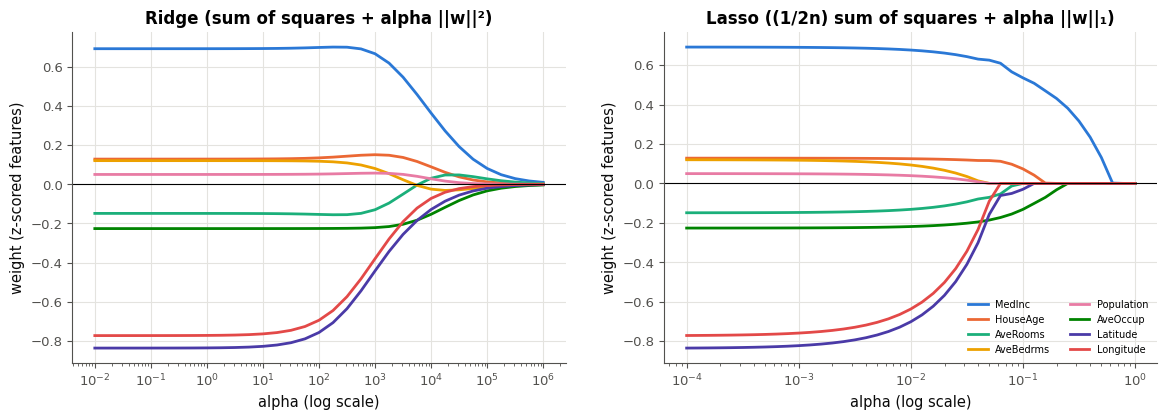

In [52]:
X_train_22 = X_cal[TRAIN_CAL]
Z_train_22 = (X_train_22 - X_train_22.mean(axis=0)) / X_train_22.std(axis=0)
ridge_path_22 = np.array([Ridge(alpha=alpha).fit(Z_train_22, y_train_22).coef_ for alpha in RIDGE_ALPHAS_22])
lasso_path_22 = np.array([Lasso(alpha=alpha).fit(Z_train_22, y_train_22).coef_ for alpha in LASSO_ALPHAS_22])
centred_y_22 = y_train_22 - y_train_22.mean()                 # Z_train_22 is already centred
alpha_max_22 = float(np.max(np.abs(Z_train_22.T @ centred_y_22)) / len(y_train_22))
n_nonzero_22 = int(np.sum(Lasso(alpha=0.05).fit(Z_train_22, y_train_22).coef_ != 0))
last_feature_22 = FEATURES_CAL[int(np.argmax(np.abs(Z_train_22.T @ centred_y_22)))]
print("a)", round(alpha_max_22, 4), "· b)", n_nonzero_22, "· c)", last_feature_22)
print("nonzero weights for 0.99 × alpha_max:", np.count_nonzero(Lasso(alpha=0.99 * alpha_max_22).fit(Z_train_22, y_train_22).coef_),
      "· for 1.01 × alpha_max:", np.count_nonzero(Lasso(alpha=1.01 * alpha_max_22).fit(Z_train_22, y_train_22).coef_))
print_answer("9.22a", alpha_max_22)
print_answer("9.22b", n_nonzero_22)
print_answer("9.22c", last_feature_22)
if filled(ridge_path_22, lasso_path_22):
    if np.shape(ridge_path_22) != (33, 8) or np.shape(lasso_path_22) != (41, 8):
        print(f"❌ Ex 9.22 : attendu deux tableaux de formes (33, 8) et (41, 8) ; reçu {np.shape(ridge_path_22)} et "
              f"{np.shape(lasso_path_22)}.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
        for j_22, name_22 in enumerate(FEATURES_CAL):
            axes[0].plot(RIDGE_ALPHAS_22, np.asarray(ridge_path_22)[:, j_22], label=name_22)
            axes[1].plot(LASSO_ALPHAS_22, np.asarray(lasso_path_22)[:, j_22], label=name_22)
        for ax, name_22 in zip(axes, ["Ridge (sum of squares + alpha ||w||²)", "Lasso ((1/2n) sum of squares + alpha ||w||₁)"]):
            ax.axhline(0, color="black", lw=0.8)
            ax.set(xscale="log", xlabel="alpha (log scale)", ylabel="weight (z-scored features)", title=name_22)
        axes[1].legend(fontsize=7, ncol=2)
        plt.show()

In [53]:
raw_22 = X_cal[TRAIN_CAL]
raw_alpha_max_22 = float(np.max(np.abs((raw_22 - raw_22.mean(axis=0)).T @ centred_y_22)) / len(y_train_22))
wb.record("9.22a", alpha_max_22, decimals=4, mistakes={
    "tu as oublié de diviser par n, le nombre de districts d'entraînement": alpha_max_22 * len(y_train_22),
    "calcule avec les features standardisées, celles qu'on donne au Lasso": raw_alpha_max_22})
wb.record("9.22b", n_nonzero_22, fractional="un nombre de poids est entier")
wb.record("9.22c", last_feature_22, mistakes={
    "Latitude a un gros poids en moindres carrés, mais le Lasso l'annule avant une autre feature : regarde le chemin": "Latitude",
    "Longitude a un gros poids en moindres carrés, mais le Lasso l'annule tôt : regarde le chemin": "Longitude"})

WB_ANSWER {"decimals": 4, "hash": "7588463049b9cefd195f39900686284a15d0d8b23a79762802419efb7cef98b3", "hash_coarse": "0f06daafd549757ef03859572cb7add470a4ad3020c0e24eb71b996e1970c860", "id": "9.22a", "kind": "float", "magnitude": -1, "mistakes": {"3e8b2ecfcba74f04769afde61aaa18495eb47ad7a4b78fcd6e7ce1cb30aeb8d2": "calcule avec les features standardisées, celles qu'on donne au Lasso", "c23282e8e66c944b7b726710bc85718604bf886f1bf48b884066498595f49542": "tu as oublié de diviser par n, le nombre de districts d'entraînement"}, "sign": 1}
📝 Ex 9.22a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"fractional": "un nombre de poids est entier", "hash": "70d7d4a61f1a11c606d479da0eca1d0480d00f74bc9190a6bb32343add97edaa", "id": "9.22b", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 9.22b : réponse enregistrée (int).
WB_ANSWER {"hash": "921bcf5616570b3753b52068e88853c787a48fb8bef04a7a67864978d687dfd3", "id": "9.22c", "kind": "str", "mistakes": {"8377a8c0d66c7a3f3d8656512bd948472c83891765

💡 Ridge fait baisser la norme des huit poids en douceur, sans les mettre à zéro : les deux plus gros (`Latitude` et `Longitude`) fondent, mais quatre autres (`MedInc`, `HouseAge`, `AveRooms` et `Population`) grandissent un peu avant de rétrécir, comme en 9.19, et deux changent de signe en chemin (`AveRooms` et `AveBedrms`). Le Lasso les annule un à un : `AveBedrms` vers $\alpha \approx 0{,}045$ et `Population` vers 0,048 (d'où les 6 poids non nuls à 0,05), puis `Longitude`, `AveRooms`, `Latitude`, `HouseAge` et `AveOccup` ; `MedInc` (le revenu médian) reste seul jusqu'au seuil $\alpha_{\max} = 0{,}633$. `Latitude` et `Longitude` ont les deux plus gros poids en moindres carrés (−0,84 et −0,77 sur les features standardisées), mais elles sont très corrélées (−0,93 : la Californie s'étire du nord-ouest au sud-est) et leurs poids se compensent en partie. Le Lasso, qui paie chaque unité de poids, lâche `Longitude` dès $\alpha \approx 0{,}056$ et garde `Latitude` jusqu'à 0,13. Pour un modèle à expliquer, le Lasso donne une liste courte de features ; mais entre deux features très corrélées, il en garde une et lâche l'autre, alors qu'elles portent en partie la même information. Ici, son choix est stable (sur 40 sous-échantillons de 1 000 districts, `Latitude` survit chaque fois à `Longitude`) ; entre deux features presque interchangeables, il peut basculer d'un échantillon à l'autre. Les deux objectifs n'ont pas la même échelle : Ridge pénalise une **somme** de 15 184 carrés, le Lasso une somme divisée par $2n$ ; ses `alpha` sont donc bien plus petits pour un effet comparable.

### Ex 9.23 — Lasso par descente de coordonnées et soft_threshold 🔨 ★★★ ⏱️ 60 min
**Objectif :** écrire le seuillage doux et le Lasso par descente de coordonnées, et les vérifier contre scikit-learn.  
**Prérequis :** Ex 9.14 · ∂ 9.6 · Ex 9.16 · fiche §9.5 (encadré 🧮 sur le Lasso) · **Fil rouge :** synthétique · **mylearn :** `linear.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/linear.py`, mêmes règles qu'en 9.14 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `soft_threshold(z, gamma)` puis la classe `Lasso` (lis leurs docstrings, et le pseudo-code de l'encadré 🧮 de la fiche §9.5) :
- `soft_threshold` : sans boucle ni `if` sur les valeurs (`np.sign`, `np.abs`, `np.maximum`) ; le résultat garde la forme de `z` (un tableau de dimension 0 pour un nombre) et vaut **exactement** 0 sur $[-\gamma, \gamma]$ ; une `ValueError` si `gamma < 0` ;
- `Lasso.fit` : une `ValueError` si `alpha <= 0` (dans `fit`, comme pour `Ridge`) ; avec `fit_intercept=True`, centre `X` et `y` ; pars de $\mathbf{w} = \mathbf{0}$ et du résidu $\mathbf{r} = \mathbf{y}_c$, puis fais des passes sur les coordonnées comme dans le pseudo-code, en tenant le **résidu à jour** à chaque changement de poids (ne recalcule pas $\mathbf{X}\mathbf{w}$ en entier) ;
- une colonne nulle ($z_j = 0$) reçoit $w_j = 0$, **sans** division par zéro ;
- arrête-toi après la **première** passe dont le plus grand changement d'un poids est `< tol`, ou après `max_iter` passes ; `n_iter_` est le nombre de passes faites : 1 quand $\alpha \geq \max_j |\mathbf{x}_{c,j}^\top \mathbf{y}_c| / n$, puisqu'aucun poids ne bouge ;
- mêmes conventions que `Ridge` : `coef_`, `intercept_` en `float`, attributs appris suffixés par `_` (ou privés, préfixés par `_`), `predict`, `score` avec ton `r2_score`.

La vérification essaie les exemples des docstrings, compare ton Lasso à celui de scikit-learn sur 60 exemples de 10 features dont 3 seulement servent (`W_TRUE_23`), vérifie le nombre de poids exactement nuls pour `alpha = 0.25`, puis lance les tests (s'il ne converge pas, ton Lasso peut les ralentir : compte une minute).

Dans tes notes : quelles features le Lasso a-t-il gardées ? Combien de passes lui a-t-il fallu ? Pourquoi le seuillage doux donne-t-il des zéros **exacts**, là où une descente de gradient n'en donnerait presque jamais ?

In [54]:
rng_23 = np.random.default_rng(923)
X_23 = rng_23.normal(size=(60, 10))                               # 60 samples, 10 features
W_TRUE_23 = np.array([3.0, -2.0, 0.0, 0.0, 1.5, 0.0, 0.0, 0.0, 0.0, 0.0])   # only 3 useful features
y_23 = X_23 @ W_TRUE_23 + 1.0 + rng_23.normal(0, 1.0, 60)

In [55]:
if True:
    lin_23 = mylearn.linear
    print("docstring example:", lin_23.soft_threshold(np.array([-3.0, 0.5, 2.0]), 1.0))
    doc_23 = fitted(lin_23.Lasso(alpha=0.5), np.array([[1.0], [2.0], [3.0]]), np.array([3.0, 5.0, 7.0]))
    if not has_weights("9.23", doc_23):
        raise NotImplementedError("Lasso.fit ne crée pas encore coef_ et intercept_")
    print("docstring example: coef_ =", np.round(np.asarray(doc_23.coef_, dtype=float), 4).tolist(),
          "· intercept_ =", round(float(doc_23.intercept_), 4))
    model_23 = fitted(lin_23.Lasso(alpha=0.25, tol=1e-10, max_iter=100_000), X_23, y_23)
    oracle_23 = Lasso(alpha=0.25, tol=1e-12, max_iter=100_000).fit(X_23, y_23)
    coef_23 = np.asarray(model_23.coef_, dtype=float)
    verdict("9.23", coef_23.shape == (10,) and np.allclose(coef_23, oracle_23.coef_, atol=1e-6),
            "les mêmes poids que le Lasso de scikit-learn, zéros compris.",
            "tes poids diffèrent de ceux du Lasso de scikit-learn : relis le pseudo-code de la fiche (§9.5).")
    print("your weights:", np.round(coef_23, 3).tolist(), f"({getattr(model_23, 'n_iter_', '?')} passes)")
    print_answer("9.23", int(np.sum(coef_23 == 0)), computed=True)
    run_mylearn_tests(impl="ref", keyword="test_soft_threshold_ or test_lasso_")

docstring example: [-2.  0.  1.]
docstring example: coef_ = [1.25] · intercept_ = 2.5
✅ Ex 9.23 : les mêmes poids que le Lasso de scikit-learn, zéros compris.
your weights: [2.633, -1.677, 0.0, 0.0, 1.072, 0.0, 0.0, 0.0, 0.0, -0.0] (10 passes)
9.23: 7


pytest: 32 passed, 121 deselected in 0.77s


In [56]:
wb.record("9.23", int(np.sum(coef_23 == 0)), mistakes={
    "c'est le nombre de poids non nuls : la question demande les poids exactement nuls": int(np.sum(coef_23 != 0))})

WB_ANSWER {"hash": "2b2a118dfa59a2f3c67c0260a3322b205195a0b78f41b2bb9e4966038d57c4f5", "id": "9.23", "kind": "int", "magnitude": 0, "mistakes": {"06b72a3968d6c9e6389f3682ca730b7bfbd64bac5baff5660817da8f6d0af552": "c'est le nombre de poids non nuls : la question demande les poids exactement nuls"}, "sign": 1}
📝 Ex 9.23 : réponse enregistrée (int).


💡 Avec `alpha` = 0,25, le Lasso garde exactement les trois features utiles (0, 1 et 4), avec des poids plus petits que les vrais (2,63 ; −1,68 et 1,07 au lieu de 3 ; −2 et 1,5 : le prix de la pénalité), et met les sept autres exactement à 0 ; avec `alpha` = 0,1, quatre features inutiles gardent de petits poids, que le bruit rend un peu utiles sur ces 60 exemples. Le seuillage doux rend 0 dès que $|\rho_j| \leq \alpha$ : la valeur exacte 0, par un `max`. Une descente de gradient sur la valeur absolue oscille autour de 0 sans jamais y tomber exactement. La référence suit le pseudo-code de la fiche ; elle saute les colonnes nulles (`if z[j] == 0.0: continue`), dont le poids reste 0.

## Partie C · Biais, variance et droites bayésiennes

Retour au vent de la partie B : `x_year`, `wind_year` (une année de mesures bruitées) et `f_year` (la courbe idéale). On refait l'expérience du livre (§9.6.1 à 9.6.3) pour **mesurer** le biais² et la variance d'une famille de modèles, puis on ajuste une droite à la manière bayésienne (§9.7). Les deux exercices 🎨 reproduisent des figures du livre avec d'autres données et d'autres réglages.

### Ex 9.24 — Biais et variance mesurés : 50 sous-échantillons de 30 points 🔨 ★★★ ⏱️ 45 min
**Objectif :** mesurer le biais² et la variance d'une famille de modèles, avec une forte et une minuscule pénalité.  
**Prérequis :** Ex 9.4 (papier) · Ex 9.17 · ch. 2 (variance, ddof) · fiche §9.6 (deux encadrés 🧮) · **Fil rouge :** synthétique (le vent) · **mylearn :** `linear.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/linear.py`, mêmes règles qu'en 9.14 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

1. Écris `bias_variance_decomposition(predictions, f_true)` (lis sa docstring ; encadrés 🧮 de la fiche §9.6) : une ligne de `predictions` par modèle, une colonne par point ; le modèle moyen est la moyenne des lignes ; le biais² est la moyenne, sur les points, de (modèle moyen − $f$)², la variance la moyenne, sur les points, de la variance des modèles, avec **ddof = 0** (on divise par le nombre de modèles). Elle renvoie un tuple de deux `float` Python, et lève une `ValueError` si les formes ne collent pas ou s'il y a moins de 2 modèles. Avec ces définitions, biais² + variance vaut exactement l'erreur quadratique moyenne des modèles face à $f$.
2. Dans le notebook, écris `family_24(alpha, n_sets=50, n_points=30, seed=924)` : l'expérience du livre sur l'année de vent. Crée **un seul** générateur `rng = np.random.default_rng(seed)` ; pour chacun des `n_sets` sous-échantillons, tire `days = rng.choice(365, size=n_points, replace=False)`, entraîne `PolyRidge(DEGREE_24, alpha)` (le degré vaut 8) sur `(x_year[days], wind_year[days])`, et range ses prédictions sur les 365 jours (`x_year`) dans la ligne correspondante d'un tableau `(n_sets, 365)`.

La vérification essaie l'exemple de la docstring, puis calcule avec tes deux fonctions le biais² et la variance de la famille face à la courbe idéale `f_year` :
a) pour `alpha = 1` (forte pénalité) : `[biais², variance]` ;
b) pour `alpha = 1e-5` (pénalité minuscule) : `[biais², variance]` ;
vérifie l'identité biais² + variance = erreur quadratique moyenne des 50 modèles, trace la variance jour par jour, puis lance les tests.

Dans tes notes : quel terme change le plus entre a) et b) ? Où, dans l'année, la variance de b) se concentre-t-elle, et pourquoi ? Le biais² de b) n'est pas nul : qu'est-ce qui l'empêche de l'être ?

docstring example: (1.0, 1.0) (expected (1.0, 1.0))
alpha = 1: bias² 0.5531, variance 0.6755
9.24a: [0.5531, 0.6755]
✅ Ex 9.24 : biais² + variance = 1,2286, l'erreur quadratique moyenne des 50 modèles face à la courbe idéale.
alpha = 1e-05: bias² 0.1602, variance 6.2173
9.24b: [0.1602, 6.2173]
✅ Ex 9.24 : biais² + variance = 6,3776, l'erreur quadratique moyenne des 50 modèles face à la courbe idéale.


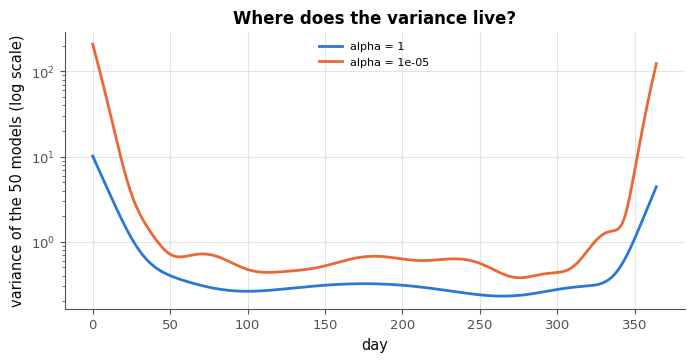

pytest: 14 passed, 139 deselected in 0.73s


In [57]:
DEGREE_24 = 8


def family_24(alpha, n_sets=50, n_points=30, seed=924):
    """The book's experiment (§9.6.1 to 9.6.3) on the noisy year: n_sets subsamples of n_points days, drawn without
    replacement with ONE generator rng = np.random.default_rng(seed); on each one, PolyRidge(DEGREE_24, alpha) fitted
    on (x_year[days], wind_year[days]). Returns the array (n_sets, 365) of the predictions of the n_sets models on
    the 365 days (x_year)."""
    rng = np.random.default_rng(seed)
    predictions = np.empty((n_sets, len(x_year)))
    for s in range(n_sets):
        days = rng.choice(len(x_year), size=n_points, replace=False)
        model = PolyRidge(DEGREE_24, alpha)
        model.fit(x_year[days], wind_year[days])
        predictions[s] = model.predict(x_year)
    return predictions


if True:
    print("docstring example:", mylearn.linear.bias_variance_decomposition([[1.0, 2.0], [3.0, 4.0]], [1.0, 2.0]),
          "(expected (1.0, 1.0))")
    families_24 = {}
    for letter_24, alpha_24 in [("a", 1.0), ("b", 1e-5)]:
        preds_24 = family_24(alpha_24)
        if not returned("9.24", "family_24", preds_24):
            break
        preds_24 = np.asarray(preds_24, dtype=float)
        if preds_24.shape != (50, 365):
            print(f"❌ Ex 9.24 : family_24 doit renvoyer un tableau (50, 365) : un modèle par ligne, un jour par colonne ; "
                  f"reçu une forme {preds_24.shape}.")
            break
        decomposition_24 = mylearn.linear.bias_variance_decomposition(preds_24, f_year)
        if not returned("9.24", "bias_variance_decomposition", decomposition_24):
            break
        bias2_24, variance_24 = (float(value) for value in decomposition_24)
        print(f"alpha = {alpha_24:g}: bias² {bias2_24:.4f}, variance {variance_24:.4f}")
        print_answer(f"9.24{letter_24}", [bias2_24, variance_24], computed=True)
        error_24 = float(np.mean((preds_24 - f_year) ** 2))
        verdict("9.24", abs(error_24 - bias2_24 - variance_24) <= 1e-9 * max(1.0, error_24),
                f"biais² + variance = {fr(error_24, 4)}, l'erreur quadratique moyenne des 50 modèles face à la courbe idéale.",
                f"biais² + variance devrait valoir {fr(error_24, 4)}, l'erreur quadratique moyenne des 50 modèles face à la courbe idéale.")
        families_24[alpha_24] = preds_24
    if len(families_24) == 2:
        fig, ax = plt.subplots(figsize=(8, 3.6))
        for alpha_24, preds_24 in families_24.items():
            ax.plot(DAYS, preds_24.var(axis=0), label=f"alpha = {alpha_24:g}")
        ax.set(yscale="log", xlabel="day", ylabel="variance of the 50 models (log scale)", title="Where does the variance live?")
        ax.legend(fontsize=8)
        plt.show()
    run_mylearn_tests(impl="ref", keyword="test_bias_variance_decomposition_")

In [58]:
for letter_24, alpha_24 in [("a", 1.0), ("b", 1e-5)]:
    preds_24 = families_24[alpha_24]
    bias2_24, variance_24 = mylearn.linear.bias_variance_decomposition(preds_24, f_year)
    wb.record(f"9.24{letter_24}", [bias2_24, variance_24], decimals=4, mistakes={
        "la variance divise par le nombre de modèles (ddof = 0), comme l'exige la docstring": [bias2_24, float(np.mean(preds_24.var(axis=0, ddof=1)))],
        "l'ordre demandé est [biais², variance]": [variance_24, bias2_24],
        "c'est l'erreur quadratique moyenne des modèles : le biais² compare le modèle MOYEN à la courbe idéale": [float(np.mean((preds_24 - f_year) ** 2)), variance_24]})

WB_ANSWER {"decimals": 4, "element_coarse": [["8e5bf0913ae1143e6324496d77d41a2148aa5cbb301c89eeb73f1033b46abc72"], ["41734a56784063249125284e70a95a85bf552c58d9960ac83af2e7d566cacabe"]], "element_hashes": ["12038f29c89f0159429ef5371635196595a632c3fe89295991e9032cb702d997", "c14ea0df75cee662a565a8b234ec06758ca65bd7f07e367b38bfa0d32529c63e"], "hash": "4436d4042a18a324109dfa373855d5613edbb876baffc9bce9cb2ef076382d45", "id": "9.24a", "kind": "array", "mistakes": {"309aa906188839df584aabf7e2fef89ab71bf9fa13db23ff2a074f3feed10b1f": "l'ordre demandé est [biais², variance]", "4466b0de512d5515ac7fa1e6419ec8470aa05038471fb47270b1668cd9ea6755": "c'est l'erreur quadratique moyenne des modèles : le biais² compare le modèle MOYEN à la courbe idéale", "5f7f5fbe3fcf0666b6cef448db6a7a8206a50493f3ce4e73d4c297be7f71d9df": "la variance divise par le nombre de modèles (ddof = 0), comme l'exige la docstring"}, "shape": [2]}
📝 Ex 9.24a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "e

💡 a) $\alpha = 1$ : biais² 0,553 et variance 0,676. b) $\alpha = 10^{-5}$ : biais² 0,160 et variance 6,217. La variance est multipliée par neuf, le biais² divisé par trois et demi : c'est surtout la variance qui paie la pénalité minuscule. Jour par jour, elle se concentre aux deux bords de l'année : un sous-échantillon de 30 jours tirés au hasard laisse souvent un trou près d'un bord, et le polynôme, que rien n'y retient, s'envole (la figure 9.15 du livre a besoin d'une seconde échelle pour la même raison). Le biais² de b) n'est pas nul, pour trois raisons. (1) Avec 50 jeux, le modèle moyen reste lui-même bruité : environ variance / 50 ≈ 0,12 se range dans le biais² mesuré. (2) Les 50 sous-échantillons puisent dans la **même** année bruitée (fiche §9.6.1) : en moyenne, les modèles suivent aussi le bruit de cette année-là, qui n'est pas la courbe idéale. (3) La famille elle-même a un petit biais : avec des mesures sans aucun bruit (égales à la courbe idéale), la moyenne de 2 000 polynômes ajustés sur 30 jours s'en écarte encore (biais² 0,04). Enfin, la variance de b) est une mesure très instable : de rares sous-échantillons, qui laissent un grand trou près d'un bord, donnent des courbes qui s'envolent très loin et pèsent lourd dans la moyenne. Avec 1 000 sous-échantillons de la même année au lieu de 50, elle monte à 123 ; et sur 40 autres graines, la mesure sur 50 jeux va de 6 à 104 dans 8 cas sur 10 (médiane 17). La conclusion tient (la pénalité minuscule fait exploser la variance), pas le chiffre.

### Ex 9.25 — Reproduire les figures 9.13 et 9.15, puis la courbe en U 🎨 ★★★ ⏱️ 40 min
**Objectif :** dessiner les deux familles de courbes du livre et la courbe en U du compromis biais-variance, avec tes propres mesures.  
**Prérequis :** Ex 9.24 · livre §9.6.2 à 9.6.4 (figures 9.13 et 9.15) · fiche §9.6 · **Fil rouge :** synthétique (le vent) · **Parcours :** C

Les figures 9.13 et 9.15 du livre superposent les 50 courbes d'une famille : rigide (forte pénalité), puis souple (pénalité minuscule), avec, pour la seconde, une échelle verticale élargie, tant ses courbes s'envolent aux bords. Reproduis-les avec **ta** famille de 9.24, puis ajoute ce que le livre ne montre pas : la courbe en U.

Écris :
- `draw_family_25(ax, predictions, f_true, title, ylim=None)` : sur `ax`, toutes les courbes de la famille (une ligne de `predictions` par modèle : traits fins et transparents, par exemple `lw=0.7, alpha=0.35`), le modèle moyen et la courbe idéale, en fonction des jours 0 à 364 ; puis le titre, les étiquettes des axes, et les limites verticales `ylim` si elles sont données ;
- `draw_u_25(ax, alphas, bias2, variance, noise_var)` : sur `ax`, en fonction de `alpha`, le biais², la variance et biais² + variance + `noise_var` (l'erreur attendue sur une nouvelle mesure), plus le bruit en ligne horizontale (`ax.axhline`) ; échelles logarithmiques sur les deux axes, une légende.

La vérification dessine quatre panneaux : (a) la famille de `alpha = 1` ; (b) celle de `alpha = 1e-5`, à l'échelle de (a) ; (c) la même, à toute l'échelle ; (d) le U, mesuré avec ta `family_24` et ta `bias_variance_decomposition` pour 17 valeurs de `alpha`, de $10^{-6}$ à $10^{2}$. Elle contrôle le nombre de courbes de chaque panneau, puis affiche le `alpha` de la plus petite erreur attendue.

Dans tes notes : où est le creux du U ? Pourquoi le biais² mesuré n'est-il pas parfaitement croissant ? Compare tes panneaux à ceux de la fiche (figure `biais_variance.png`) : qu'est-ce qui diffère dans le protocole ?

✅ Ex 9.25 : quatre panneaux : les deux familles du livre, la seconde à toute l'échelle, et le U.


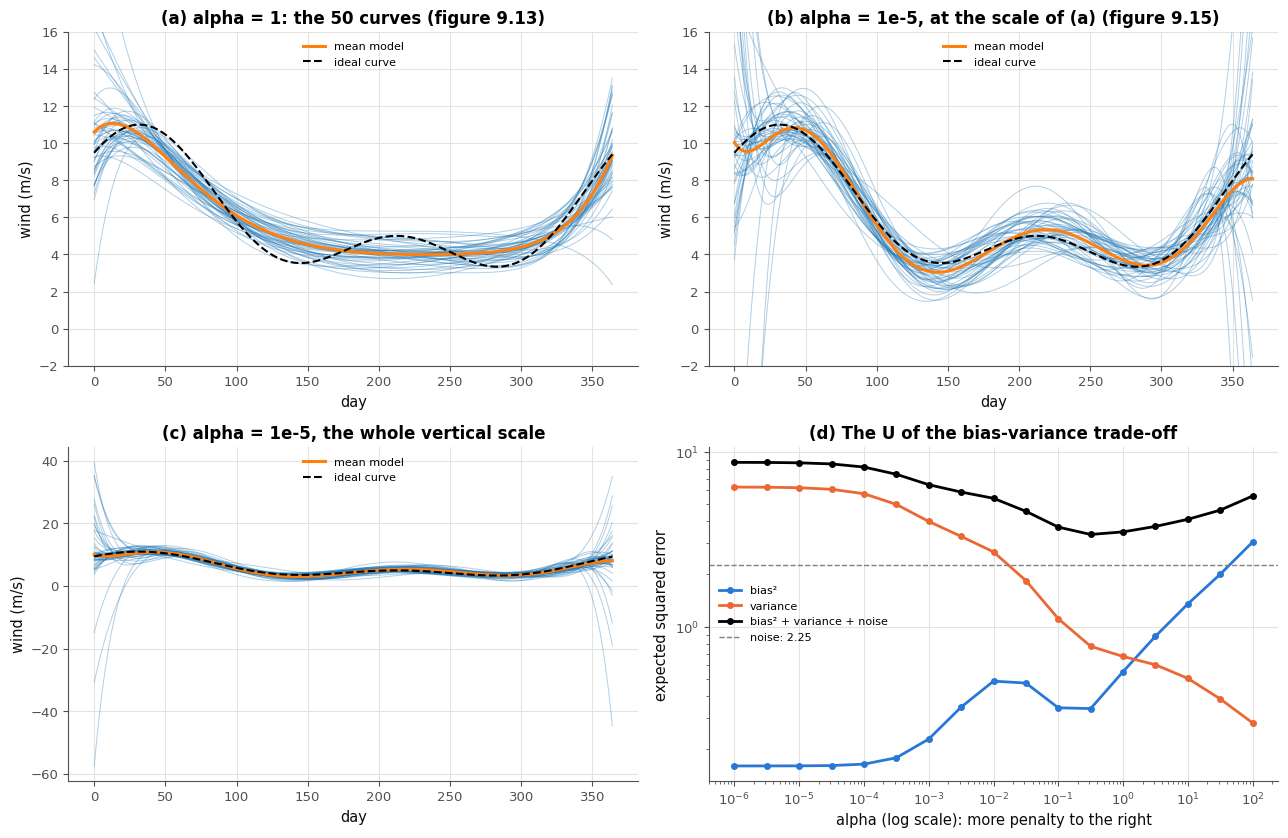

smallest expected error at alpha = 0.316228: bias² 0.340 + variance 0.772 + noise 2.25


In [59]:
def draw_family_25(ax, predictions, f_true, title, ylim=None):
    """Draw on ax every curve of the family (one row of `predictions` per model: thin, transparent lines), the mean
    model and the ideal curve f_true, against the days 0 to 364; then the title, the labels, and ylim if given."""
    days = np.arange(np.shape(predictions)[1])
    for curve in predictions:
        ax.plot(days, curve, color="tab:blue", lw=0.7, alpha=0.35)
    ax.plot(days, np.mean(predictions, axis=0), color="tab:orange", lw=2.2, label="mean model")
    ax.plot(days, f_true, color="black", lw=1.5, ls="--", label="ideal curve")
    ax.set(xlabel="day", ylabel="wind (m/s)", title=title)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(fontsize=8, loc="upper center")


def draw_u_25(ax, alphas, bias2, variance, noise_var):
    """Draw on ax, against alpha (logarithmic scales on both axes): the bias², the variance, bias² + variance +
    noise_var, and the noise as a horizontal line; with a legend and labels."""
    bias2, variance = np.asarray(bias2, dtype=float), np.asarray(variance, dtype=float)
    ax.plot(alphas, bias2, "o-", ms=4, label="bias²")
    ax.plot(alphas, variance, "o-", ms=4, label="variance")
    ax.plot(alphas, bias2 + variance + noise_var, "o-", ms=4, color="black", label="bias² + variance + noise")
    ax.axhline(noise_var, color="gray", ls="--", lw=1, label=f"noise: {noise_var:g}")
    ax.set(xscale="log", yscale="log", xlabel="alpha (log scale): more penalty to the right",
           ylabel="expected squared error", title="(d) The U of the bias-variance trade-off")
    ax.legend(fontsize=8)


def n_curves_25(ax):
    """The number of curves drawn on ax: its lines, plus the segments of its line collections."""
    from matplotlib.collections import LineCollection
    return len(ax.lines) + sum(len(c.get_segments()) for c in ax.collections if isinstance(c, LineCollection))


if True:
    strong_25, weak_25 = family_24(1.0), family_24(1e-5)
    if any(family is None or np.shape(family) != (50, 365) for family in (strong_25, weak_25)):
        raise NotImplementedError("corrige d'abord family_24 (9.24) : un tableau (50, 365) est attendu")
    strong_25, weak_25 = np.asarray(strong_25, dtype=float), np.asarray(weak_25, dtype=float)
    ALPHAS_25 = 10.0 ** np.arange(-6, 2.5, 0.5)
    stats_25 = np.array([mylearn.linear.bias_variance_decomposition(family_24(alpha), f_year) for alpha in ALPHAS_25],
                        dtype=float)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
    try:
        draw_family_25(axes[0, 0], strong_25, f_year, "(a) alpha = 1: the 50 curves (figure 9.13)", ylim=(-2, 16))
        draw_family_25(axes[0, 1], weak_25, f_year, "(b) alpha = 1e-5, at the scale of (a) (figure 9.15)", ylim=(-2, 16))
        draw_family_25(axes[1, 0], weak_25, f_year, "(c) alpha = 1e-5, the whole vertical scale")
        draw_u_25(axes[1, 1], ALPHAS_25, stats_25[:, 0], stats_25[:, 1], NOISE_STD ** 2)
    except NotImplementedError:
        plt.close(fig)                                     # no empty figure before the functions are written
        raise
    fig.tight_layout()
    n_lines_25 = [n_curves_25(ax) for ax in axes.ravel()]
    verdict("9.25", min(n_lines_25[:3]) >= 52 and n_lines_25[3] >= 3 and axes[1, 1].get_xscale() == "log",
            "quatre panneaux : les deux familles du livre, la seconde à toute l'échelle, et le U.",
            f"attendu au moins 52 courbes dans chaque famille (50 modèles, le modèle moyen, la courbe idéale) et au moins "
            f"3 courbes, en échelle log, pour le U ; reçu {n_lines_25} courbes et l'échelle "
            f"« {axes[1, 1].get_xscale()} ».")
    plt.show()
    best_25 = int(np.argmin(stats_25.sum(axis=1)))
    print(f"smallest expected error at alpha = {ALPHAS_25[best_25]:g}: bias² {stats_25[best_25, 0]:.3f} + variance "
          f"{stats_25[best_25, 1]:.3f} + noise {NOISE_STD ** 2:.2f}")

💡 Les 50 courbes de $\alpha = 1$ se ressemblent, et ratent toutes la seconde bosse de l'année, vers le jour 210 : biais élevé, variance faible. Celles de $\alpha = 10^{-5}$ suivent la forme en moyenne, mais s'éparpillent, et quelques-unes s'envolent aux bords (panneau (c) : de −58 à 40 m/s). Le creux du U est vers $\alpha \approx 0{,}3$ (biais² 0,34 + variance 0,77 + bruit 2,25). À gauche, c'est la variance qui fait monter l'erreur ; à droite, la montée du biais². Le creux n'est pas là où les deux courbes se croisent (vers $\alpha \approx 2$) : il est là où la baisse de l'une compense juste la hausse de l'autre. Le biais² mesuré n'est pas croissant partout : il a une bosse vers $\alpha = 0{,}01$. Ce n'est pas seulement le hasard des 50 jeux : la bosse reste avec 1 000 jeux, et même avec un bruit neuf pour chaque jeu. Rien n'oblige le biais² à croître avec la pénalité : elle ne pousse pas le modèle moyen tout droit vers une constante, elle rétrécit d'abord certaines combinaisons des puissances de $x$, et le modèle moyen peut s'écarter de la courbe idéale avant de s'en rapprocher. Le compromis biais-variance décrit une tendance, pas une loi valable pour chaque valeur. Par rapport à la figure de la fiche (un sinus, 20 points tirés à chaque jeu avec un bruit neuf, 200 jeux, des puissances de $x$ non standardisées), on a ici 50 sous-échantillons d'**une seule** année bruitée, comme dans le livre : les jeux partagent leur bruit, ce qui s'écarte du cadre de l'encadré 🧮.

### Ex 9.26 — Le posterior des droites sur une grille pente-ordonnée 🔨 ★★★ ⏱️ 45 min
**Objectif :** calculer, sur une grille, la probabilité a posteriori de chaque droite, en log et sans sous-débordement.  
**Prérequis :** Ex 9.7 (papier) · ch. 4 (règle de Bayes, log-probabilités) · fiche §9.7 (encadré 🧮) · **Fil rouge :** synthétique · **mylearn :** `linear.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/linear.py`, mêmes règles qu'en 9.14 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `bayes_line_posterior(x, y, slopes, intercepts, noise_std=0.1, prior_std=1.0)` (lis sa docstring ; encadré 🧮 « le posterior d'une droite » de la fiche §9.7) :
- le résultat a la forme `(n_b, n_s)` : une **ligne** par ordonnée à l'origine, une **colonne** par pente (le plus simple : `S, B = np.meshgrid(slopes, intercepts)`, deux tableaux de cette forme) ;
- calcule le log du prior plus la somme, sur les points, des logs des vraisemblances, retranche le maximum, puis passe à l'exponentielle et normalise (somme 1) : jamais de produit de vraisemblances, qui tomberait à 0 par underflow avec beaucoup de points (ch. 4) ;
- sans aucun point (`x` et `y` vides), le résultat est le prior normalisé ;
- une `ValueError` si `len(x) != len(y)` ou si un écart-type est ≤ 0.

La vérification essaie l'exemple de la docstring, calcule le posterior de 5 points (`X_26`, `Y_26`, simulés autour de la droite $y = -0{,}5\,x + 0{,}3$) sur une grille de 201 × 201 droites, compare sa moyenne à la formule fermée (C. Bishop, 2006, éq. 3.53 et 3.54), le dessine, puis lance les tests.

Dans tes notes : la croix de la droite simulée tombe-t-elle au centre de la tache ? Pourquoi la tache est-elle penchée (pense à la position des 5 points sur l'axe des $x$) ?

In [60]:
SLOPES = np.linspace(-2, 2, 201)              # the grid of the book: slopes and intercepts from -2 to 2
INTERCEPTS = np.linspace(-2, 2, 201)
rng_26 = np.random.default_rng(926)
X_26 = rng_26.uniform(-1, 1, 5)
Y_26 = -0.5 * X_26 + 0.3 + rng_26.normal(0, 0.2, 5)   # 5 points around the line y = -0.5 x + 0.3

docstring example: [[0.1015, 0.4551], [0.276, 0.1674]] (expected [[0.1015, 0.4551], [0.276, 0.1674]])
posterior mean (slope, intercept): grid [-0.4324, 0.2038] · closed form [-0.4324, 0.2038]
✅ Ex 9.26 : une table de probabilités dont la moyenne est celle de la formule fermée.


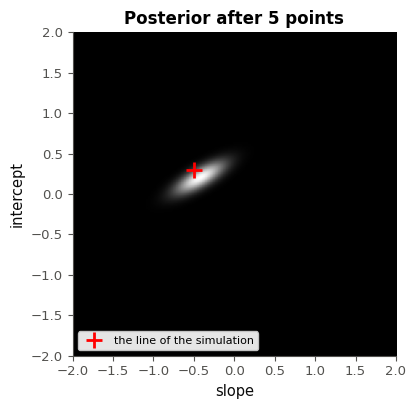

pytest: 17 passed, 136 deselected in 1.08s


In [61]:
if True:
    doc_26 = mylearn.linear.bayes_line_posterior([2.0], [2.0], slopes=[0.0, 1.0], intercepts=[0.0, 1.0],
                                                 noise_std=1.0, prior_std=1.0)
    if returned("9.26", "bayes_line_posterior", doc_26):
        print("docstring example:", np.round(np.asarray(doc_26, dtype=float), 4).tolist(),
              "(expected [[0.1015, 0.4551], [0.276, 0.1674]])")
    post_26 = mylearn.linear.bayes_line_posterior(X_26, Y_26, SLOPES, INTERCEPTS, noise_std=0.2, prior_std=1.0)
    if returned("9.26", "bayes_line_posterior", post_26):
        post_26 = np.asarray(post_26, dtype=float)
        if post_26.shape != (len(INTERCEPTS), len(SLOPES)):
            print(f"❌ Ex 9.26 : attendu un tableau ({len(INTERCEPTS)}, {len(SLOPES)}) : une ligne par ordonnée à "
                  f"l'origine, une colonne par pente ; reçu une forme {post_26.shape}.")
        else:
            S_26, B_26 = np.meshgrid(SLOPES, INTERCEPTS)
            grid_mean_26 = np.array([np.sum(post_26 * S_26), np.sum(post_26 * B_26)])
            Phi_26 = np.column_stack([X_26, np.ones(len(X_26))])                    # columns: slope, intercept
            precision_26 = np.eye(2) / 1.0 ** 2 + Phi_26.T @ Phi_26 / 0.2 ** 2       # Bishop (2006), eq. 3.54
            exact_mean_26 = np.linalg.solve(precision_26, Phi_26.T @ Y_26 / 0.2 ** 2)  # eq. 3.53
            print("posterior mean (slope, intercept): grid", np.round(grid_mean_26, 4).tolist(),
                  "· closed form", np.round(exact_mean_26, 4).tolist())
            verdict("9.26", abs(post_26.sum() - 1) < 1e-9 and np.allclose(grid_mean_26, exact_mean_26, atol=2e-3),
                    "une table de probabilités dont la moyenne est celle de la formule fermée.",
                    "ta table ne somme pas à 1, ou sa moyenne s'écarte de la formule fermée : relis l'encadré 🧮 de la fiche (§9.7).")
            fig, ax = plt.subplots(figsize=(4.6, 4.2))
            ax.imshow(post_26, origin="lower", extent=[SLOPES[0], SLOPES[-1], INTERCEPTS[0], INTERCEPTS[-1]], cmap="gray")
            ax.plot(-0.5, 0.3, "r+", ms=12, mew=2, label="the line of the simulation")
            ax.set(xlabel="slope", ylabel="intercept", title="Posterior after 5 points")
            ax.grid(False)
            ax.legend(fontsize=8, loc="lower left", frameon=True, framealpha=0.9)
            plt.show()
    run_mylearn_tests(impl="ref", keyword="test_bayes_line_posterior_")

💡 La moyenne du posterior sur la grille coïncide avec la formule fermée à $10^{-3}$ près : pente −0,432, ordonnée 0,204. La croix de la droite simulée (−0,5 ; 0,3) tombe dans la tache, pas en son centre : avec 5 points bruités, le posterior résume ce que disent ces points-là. La tache est penchée parce que les 5 abscisses sont surtout négatives (leur moyenne vaut −0,50) : vers $x = -0{,}5$, une pente un peu plus grande (moins négative) abaisse la droite, et une ordonnée un peu plus haute la remet en place. Pente et ordonnée sont donc liées (corrélation de +0,75 dans le posterior), et la tache s'étire le long d'une diagonale montante ; avec des points centrés sur $x = 0$, elle ne serait pas penchée. La référence forme les deux grilles avec `np.meshgrid`, ajoute le log du prior et la somme des logs des vraisemblances, retranche le maximum, puis normalise.

### Ex 9.27 — Reproduire la figure 9.20 : prior, vraisemblances, posteriors et droites tirées 🎨 ★★★ ⏱️ 40 min
**Objectif :** dessiner les mises à jour bayésiennes successives d'une droite et des droites tirées du posterior.  
**Prérequis :** Ex 9.26 · livre §9.7 (figures 9.18 à 9.20) · fiche §9.7 · **Fil rouge :** synthétique · **Parcours :** M, C

La figure 9.20 du livre déroule la règle de Bayes point par point : la vraisemblance d'un nouveau point, le posterior qui devient le prior suivant, et des droites tirées au hasard dans ce posterior. Reproduis-la avec tes propres réglages : trois points (`X_27`, `Y_27`) simulés autour de la droite $y = 0{,}4\,x - 0{,}6$, un bruit d'écart-type `NOISE_27` = 0,15 et un prior d'écart-type `PRIOR_27` = 0,8, sur la grille de 9.26.

Écris :
- `sample_lines_27(posterior, slopes, intercepts, n_lines, rng)` : `n_lines` droites tirées au hasard dans la grille, chaque case avec la probabilité que lui donne `posterior` (par exemple `rng.choice(posterior.size, size=n_lines, p=...)` sur la table aplatie, puis `np.unravel_index` pour retrouver la ligne et la colonne de chaque case tirée) ; elle renvoie un tableau `(n_lines, 2)` de `(pente, ordonnée)` ;
- `bayes_figure_27(x, y, slopes, intercepts, noise_std, prior_std, n_lines, rng)` : une figure de `len(x) + 1` lignes et 4 colonnes. La ligne 0 montre le prior et `n_lines` droites tirées du prior (ses deux autres panneaux peuvent rester vides, ou être retirés) ; la ligne $k$ montre les $k$ premiers points (le $k$-ième en rouge), la vraisemblance de ce $k$-ième point seul, le posterior après les $k$ premiers points (ta `bayes_line_posterior`), et `n_lines` droites tirées de ce posterior. Elle renvoie la figure. Pour les images (`ax.imshow(..., origin="lower", extent=[-2, 2, -2, 2])`), `ax.grid(False)` retire le quadrillage que le style du workbook dessine par-dessus.

La vérification essaie `sample_lines_27` sur deux petites tables, dessine la figure avec 20 droites par ligne, et compte ses panneaux.

Dans tes notes : comment la tache du posterior évolue-t-elle d'un point à l'autre ? Que deviennent les 20 droites ? Pourquoi la vraisemblance d'un seul point est-elle une bande, et pourquoi sa pente dans le diagramme dépend-elle de l'abscisse du point ?

In [62]:
rng_27 = np.random.default_rng(927)
X_27 = rng_27.uniform(-1, 1, 3)
Y_27 = 0.4 * X_27 - 0.6 + rng_27.normal(0, 0.15, 3)    # 3 points around the line y = 0.4 x - 0.6
NOISE_27, PRIOR_27 = 0.15, 0.8                         # noise_std and prior_std

✅ Ex 9.27 : une table dont toute la probabilité est sur une case ne donne que cette droite (pente 0, ordonnée 1).
✅ Ex 9.27 : tirée avec la probabilité 0,75, la pente 1 sort dans une part 0,747 des 4 000 tirages.


✅ Ex 9.27 : 4 lignes de panneaux, comme la figure 9.20 du livre.


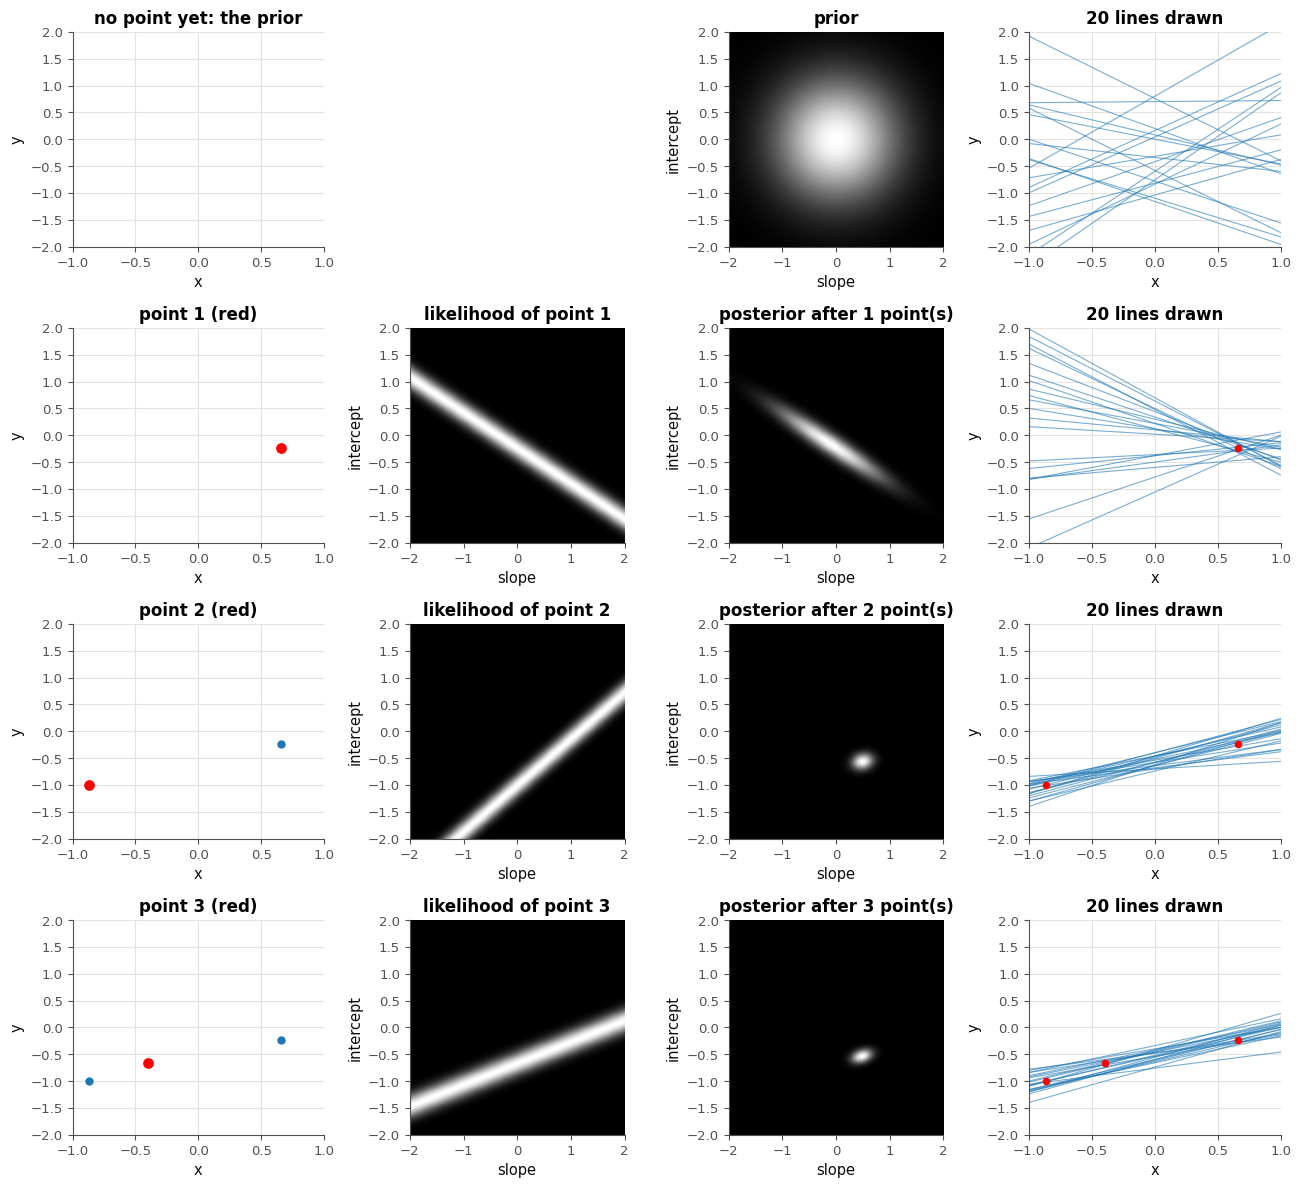

In [63]:
def sample_lines_27(posterior, slopes, intercepts, n_lines, rng):
    """n_lines lines drawn at random from the grid, each cell with the probability given by `posterior` (shape
    (len(intercepts), len(slopes)), summing to 1). Returns an array (n_lines, 2) of (slope, intercept)."""
    probs = np.asarray(posterior, dtype=float)
    cells = rng.choice(probs.size, size=n_lines, p=probs.ravel() / probs.sum())
    rows, cols = np.unravel_index(cells, probs.shape)
    return np.column_stack([np.asarray(slopes, dtype=float)[cols], np.asarray(intercepts, dtype=float)[rows]])


def bayes_figure_27(x, y, slopes, intercepts, noise_std, prior_std, n_lines, rng):
    """Figure 9.20 of the book with your own settings: a first row for the prior, then one row per point. Four
    columns: the points seen so far (the new one in red), the likelihood of the new point, the posterior, and
    n_lines lines drawn from it. Returns the matplotlib figure."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    S, B = np.meshgrid(slopes, intercepts)
    extent = [slopes[0], slopes[-1], intercepts[0], intercepts[-1]]
    ends = np.array([-1.0, 1.0])
    fig, axes = plt.subplots(len(x) + 1, 4, figsize=(13, 3.0 * (len(x) + 1)))
    for k, (ax_data, ax_like, ax_post, ax_lines) in enumerate(axes):
        posterior = mylearn.linear.bayes_line_posterior(x[:k], y[:k], slopes, intercepts, noise_std, prior_std)
        ax_data.scatter(x[:k], y[:k], color="tab:blue", s=25)
        if k == 0:
            ax_like.axis("off")
            ax_data.set_title("no point yet: the prior")
        else:
            ax_data.scatter(x[k - 1], y[k - 1], color="red", s=45, zorder=3)
            likelihood = np.exp(-(y[k - 1] - S * x[k - 1] - B) ** 2 / (2 * noise_std ** 2))
            ax_like.imshow(likelihood, origin="lower", extent=extent, cmap="gray", vmin=0, vmax=1)
            ax_like.set(title=f"likelihood of point {k}", xlabel="slope", ylabel="intercept")
            ax_like.grid(False)
            ax_data.set_title(f"point {k} (red)")
        ax_data.set(xlim=(-1, 1), ylim=(-2, 2), xlabel="x", ylabel="y")
        ax_post.imshow(posterior, origin="lower", extent=extent, cmap="gray")
        ax_post.set(title="prior" if k == 0 else f"posterior after {k} point(s)", xlabel="slope", ylabel="intercept")
        ax_post.grid(False)
        for slope, intercept in sample_lines_27(posterior, slopes, intercepts, n_lines, rng):
            ax_lines.plot(ends, slope * ends + intercept, color="tab:blue", lw=0.8, alpha=0.6)
        ax_lines.scatter(x[:k], y[:k], color="red", s=20, zorder=3)
        ax_lines.set(xlim=(-1, 1), ylim=(-2, 2), title=f"{n_lines} lines drawn", xlabel="x", ylabel="y")
    fig.tight_layout()
    return fig


if True:
    one_27 = np.zeros((3, 4))
    one_27[2, 1] = 1.0                                    # all the probability on one cell: slope 0, intercept 1
    lines_27 = sample_lines_27(one_27, np.array([-1.0, 0.0, 1.0, 2.0]), np.array([-1.0, 0.0, 1.0]), 5,
                               np.random.default_rng(0))
    if returned("9.27", "sample_lines_27", lines_27):
        lines_27 = np.asarray(lines_27, dtype=float)
        verdict("9.27", lines_27.shape == (5, 2) and np.allclose(lines_27, [[0.0, 1.0]] * 5),
                "une table dont toute la probabilité est sur une case ne donne que cette droite (pente 0, ordonnée 1).",
                f"attendu un tableau (5, 2) dont chaque ligne vaut [0, 1] (pente, ordonnée) ; reçu {lines_27.tolist()}. "
                "La ligne de la table est l'ordonnée, la colonne la pente.")
        two_27 = sample_lines_27(np.array([[0.25, 0.75]]), np.array([0.0, 1.0]), np.array([0.0]), 4000,
                                 np.random.default_rng(1))
        two_27 = None if two_27 is None else np.asarray(two_27, dtype=float)
        share_27 = float(np.mean(two_27[:, 0] == 1.0)) if two_27 is not None and two_27.shape == (4000, 2) else math.nan
        if two_27 is not None and two_27.shape == (4000, 2) and lines_27.shape == (5, 2):
            verdict("9.27", abs(share_27 - 0.75) < 0.03,
                    f"tirée avec la probabilité 0,75, la pente 1 sort dans une part {fr(share_27, 3)} des 4 000 tirages.",
                    f"la pente 1, de probabilité 0,75, sort dans une part {fr(share_27, 3)} des 4 000 tirages : tire les "
                    "cases avec les probabilités de la table (rng.choice(..., p=...)).")
    try:
        fig_27 = bayes_figure_27(X_27, Y_27, SLOPES, INTERCEPTS, NOISE_27, PRIOR_27, 20, np.random.default_rng(927))
    except NotImplementedError:
        plt.close("all")                                  # no empty figure before the function is written
        raise
    if returned("9.27", "bayes_figure_27", fig_27):
        verdict("9.27", len(fig_27.axes) >= 4 * len(X_27) + 2,
                f"{len(X_27) + 1} lignes de panneaux, comme la figure 9.20 du livre.",
                f"attendu au moins {4 * len(X_27) + 2} panneaux (le prior et ses droites, puis 4 panneaux par point) ; "
                f"reçu {len(fig_27.axes)}.")
        plt.show()
    else:
        plt.close("all")                                  # no stray empty figure

💡 Le prior est une tache ronde centrée sur la droite $y = 0$ ; ses 20 droites partent dans tous les sens. Chaque point ajoute une bande de vraisemblance : toutes les droites qui passent près de lui, c'est-à-dire, dans le diagramme, la bande « ordonnée ≈ $y_0 - x_0 \times$ pente », de pente $-x_0$. Le posterior est le produit du prior et des bandes : il se resserre à chaque point, et les droites tirées se ressemblent de plus en plus. Après trois points, elles passent toutes près des trois points, et la tache entoure la droite simulée sans forcément être centrée sur elle. La référence calcule la vraisemblance d'un point directement, avec la formule de la fiche, et la montre ramenée à 1 à son maximum, comme le livre (encadré ⚠️ de la fiche : c'est une vraisemblance, pas une distribution sur les droites).

## Partie D · Pièges, refactorisation, double descente et défi

Deux erreurs de méthode à corriger ou à éviter (9.28, 9.29), une expérience qui nuance le compromis biais-variance (9.30), puis un défi sur California (9.31). Les outils et les données des parties A à C restent disponibles.

### Ex 9.28 — Régularisation piégée : quatre erreurs qui faussent Ridge 🐛 ★★★ ⏱️ 30 min
**Objectif :** repérer les erreurs d'une étude Ridge (fuite, échelles, ordonnée pénalisée, choix sur le test) et la refaire honnêtement.  
**Prérequis :** Ex 9.17 · ch. 8 (fuites, validation croisée) · fiche §9.3 (features polynomiales) et §9.5 (pièges de la régularisation) · **Fil rouge :** California · **Parcours :** C

Un collègue ajuste une régression Ridge sur les features polynomiales de degré 3 des 8 mesures de California, avec 500 districts d'entraînement seulement (`TRAIN_28`) ; les 18 480 autres (`TEST_28`) servent de test. Son code est la fonction `colleague_28`, en six étapes, A à F : lis-la attentivement. Elle utilise `Ridge` de scikit-learn.

a) `bugs_28` : les lettres des étapes qui faussent l'étude (par exemple `"XY"`). Pour chacune, demande-toi ce qu'elle laisse passer du test vers le modèle, ou ce qu'elle fait pénaliser à tort.

Écris ensuite `honest_28()`, la même étude **sans** ces erreurs. Pour que tout le monde trouve les mêmes nombres, suis ce protocole :
1. le découpage `TRAIN_28` / `TEST_28` d'abord ;
2. les features polynomiales de degré 3 des 8 mesures **brutes** (`PolynomialFeatures(3, include_bias=False)`), puis le z-score de chacune des 164 colonnes, avec la moyenne et l'écart-type des **seules** lignes qui servent à entraîner ;
3. **ta** `Ridge` (`mylearn.linear.Ridge`), avec son ordonnée à l'origine, non pénalisée ;
4. `alpha` choisi dans `ALPHAS_28` par validation croisée sur les 500 districts d'entraînement : les folds de `KFold(5, shuffle=True, random_state=928).split(TRAIN_28)` (des positions dans `TRAIN_28`), la plus petite MSE de validation moyenne ; dans chaque tour, le z-score se calcule sur les lignes d'entraînement du tour ;
5. le modèle retenu est réentraîné sur les 500 districts, puis noté **une seule fois** sur le test : sa RMSE.

`honest_28()` renvoie `(alpha, test_rmse)`. La vérification contrôle :
b) le `alpha` retenu ;
c) la RMSE de test.

Dans tes notes : pour chaque erreur, ce qu'elle laisse passer ou ce qu'elle fausse (compare la RMSE annoncée par le collègue à la tienne). Laquelle pèse le plus, et pourquoi justement au degré 3 ? Lesquelles ne coûtent presque rien sur ces données, et pourquoi faut-il les corriger quand même ?

In [64]:
SPLIT_28 = np.random.default_rng(928).permutation(len(y_cal))
TRAIN_28, TEST_28 = SPLIT_28[:500], SPLIT_28[500:]      # 500 districts to learn from, 18 480 for the test
ALPHAS_28 = [10.0 ** k for k in range(-3, 5)]          # 0.001 to 10 000


def colleague_28():
    """Ridge on the degree-3 polynomial features of the 8 measurements of California, learned on 500 districts."""
    # A. the 8 measurements of every district, and the target
    X, y = X_cal, y_cal
    # B. the z-score of the 8 measurements
    Z = (X - X.mean(axis=0)) / X.std(axis=0)
    # C. the degree-3 polynomial features of the z-scores: 164 columns
    P = PolynomialFeatures(3, include_bias=False).fit_transform(Z)
    # D. a column of ones, so that the intercept is learned like the other weights
    P = np.column_stack([np.ones(len(P)), P])
    # E. the split: 500 training districts, the others for the test
    P_train, P_test, y_train, y_test = P[TRAIN_28], P[TEST_28], y[TRAIN_28], y[TEST_28]
    # F. alpha: the value of the grid whose model makes the smallest error on the test; report it with its RMSE
    rmse = {}
    for alpha in ALPHAS_28:
        model = Ridge(alpha=alpha, fit_intercept=False).fit(P_train, y_train)
        rmse[alpha] = float(np.sqrt(np.mean((model.predict(P_test) - y_test) ** 2)))
    best = min(rmse, key=rmse.get)
    return best, rmse[best]

In [65]:
bugs_28 = "BCDF"


def honest_28():
    """The same study without the errors, with the protocol of the statement. Returns (alpha, test_rmse)."""
    poly = PolynomialFeatures(3, include_bias=False)

    def fit_predict(rows_fit, rows_eval, alpha):
        P_fit, P_eval = poly.fit_transform(X_cal[rows_fit]), poly.fit_transform(X_cal[rows_eval])
        mean, std = P_fit.mean(axis=0), P_fit.std(axis=0)          # statistics of the fitted rows only
        model = mylearn.linear.Ridge(alpha=alpha)                   # the intercept is not penalised
        model.fit((P_fit - mean) / std, y_cal[rows_fit])
        return model.predict((P_eval - mean) / std)

    folds = list(KFold(5, shuffle=True, random_state=928).split(TRAIN_28))
    cv_mse = [np.mean([mse(y_cal[TRAIN_28[val]], fit_predict(TRAIN_28[tr], TRAIN_28[val], alpha)) for tr, val in folds])
              for alpha in ALPHAS_28]
    best = ALPHAS_28[int(np.argmin(cv_mse))]
    return best, math.sqrt(mse(y_cal[TEST_28], fit_predict(TRAIN_28, TEST_28, best)))      # the test, once


print_answer("9.28a", bugs_28)
if True:
    result_28 = honest_28()
    if returned("9.28", "honest_28", result_28):
        if not (isinstance(result_28, (tuple, list)) and len(result_28) == 2):
            print("❌ Ex 9.28 : honest_28 doit renvoyer un couple (alpha, test_rmse).")
        else:
            reported_28 = colleague_28()
            print(f"the colleague: alpha = {reported_28[0]:g}, test RMSE announced {reported_28[1]:.4f}")
            print(f"the honest study: alpha = {float(result_28[0]):g}, test RMSE {float(result_28[1]):.4f}")
            print_answer("9.28b", float(result_28[0]), computed=True)
            print_answer("9.28c", float(result_28[1]), computed=True)

9.28a: BCDF


the colleague: alpha = 10, test RMSE announced 0.7085
the honest study: alpha = 10, test RMSE 0.5621
9.28b: 10.0
9.28c: 0.5620928059192549


In [66]:
reported_28 = colleague_28()
wb.record("9.28a", bugs_28, mistakes={
    "l'étape E découpe les données : les erreurs viennent de ce qui a été fait AVANT elle, pas du découpage": "BCDEF",
    "E découpe les données au bon endroit pour le test ; l'erreur est l'étape qui calcule, avant elle, des statistiques sur toutes les lignes": "CDEF",
    "E ne fausse rien ; il manque l'étape qui fabrique des colonnes d'échelles très différentes, que Ridge pénalise ensuite de la même façon": "BDEF",
    "E ne fausse rien ; il manque l'étape qui fait pénaliser l'ordonnée à l'origine": "BCEF",
    "il manque une étape qui calcule des statistiques sur toutes les lignes, test compris": "CDF",
    "il manque l'étape qui fabrique des colonnes d'échelles très différentes, que Ridge pénalise ensuite de la même façon": "BDF",
    "il manque une étape qui fait pénaliser l'ordonnée à l'origine": "BCF",
    "il manque une étape qui choisit alpha en regardant le test": "BCD",
    "l'étape A ne fait que charger les données": "ABCDF"})
alpha_mistakes_28 = {f"alpha = {alpha:g} n'est pas la valeur de la plus petite MSE de validation moyenne : relis ta validation "
                     f"croisée (le z-score refait dans chaque tour, la moyenne sur les 5 folds)": alpha
                     for alpha in ALPHAS_28 if alpha != result_28[0]}
wb.record("9.28b", float(result_28[0]), decimals=4, mistakes=alpha_mistakes_28)
wb.record("9.28c", float(result_28[1]), decimals=4, mistakes={
    "c'est la RMSE annoncée par le collègue : refais l'étude sans ses erreurs": reported_28[1],
    "c'est une MSE : la question demande la RMSE (sa racine)": float(result_28[1]) ** 2})

WB_ANSWER {"hash": "84606badd248511097f185b2f2cad9b04a81bb8eb9d21e869920f05a6084db81", "id": "9.28a", "kind": "str", "mistakes": {"0cfe3d38e691d5b56fac1fcac861fb447b5fc6c239d5ea74f266bf2c5b09c8d4": "il manque une étape qui calcule des statistiques sur toutes les lignes, test compris", "242b6592c1812989d20e99a4a3eea2e56f2524b70433becbb1ba7fdcc980c861": "E ne fausse rien ; il manque l'étape qui fait pénaliser l'ordonnée à l'origine", "476e46edbc785079ab628900d148f9a6451818957e4adc45cacf4cffb201612d": "il manque une étape qui choisit alpha en regardant le test", "5cc421acc2558cb2325794ff9a345364fe2778399bae2bc14eb0a2c1c97f4888": "l'étape A ne fait que charger les données", "7150312144f9580feee07d62e6e1c05a866bef2288d97a44105ffd2eea928904": "il manque l'étape qui fabrique des colonnes d'échelles très différentes, que Ridge pénalise ensuite de la même façon", "96b39aa20abf76091ff0190fbb753ce52745f5e95206d894dd5f053b908ab8d5": "E découpe les données au bon endroit pour le test ; l'erreur est

💡 Les étapes **B**, **C**, **D** et **F** faussent l'étude. B standardise avec toutes les lignes, test compris : une fuite (ch. 8). C forme les puissances et les produits **après** le z-score, sans les standardiser à nouveau : un z-score dépasse rarement 3, mais son cube peut valoir des centaines (`AveBedrms` atteint un z-score de 8,4, dont le cube vaut près de 600), et les 164 colonnes ont des écarts-types de 0,7 à 26 ; la même pénalité devient injuste entre colonnes. D apprend l'ordonnée à l'origine comme un poids : elle est pénalisée, et rétrécit vers 0 quand `alpha` grandit (fiche §9.5). F choisit `alpha` sur le test et publie le score de ce choix : le chiffre annoncé n'est plus une estimation honnête (en général, il est optimiste). L'étude honnête retient `alpha` = 10 par validation croisée et obtient une RMSE de test de 0,562, contre 0,708 annoncé par le collègue. Ajoutées une à une à l'étude honnête, les erreurs coûtent : C, 0,117 (0,679) ; D, 0,003 ; B, rien de visible (−0,0004 : les statistiques de 18 980 districts ressemblent beaucoup à celles de 500) ; F, rien ici, car le test choisit le même `alpha` que la validation croisée. B, D et F sont à corriger quand même : sur d'autres données, rien ne garantit qu'elles resteront sans effet, et F rend de toute façon le chiffre annoncé invérifiable. C pèse au degré 3 parce que les cubes et les produits de trois z-scores ont des échelles très différentes (les valeurs extrêmes d'une feature sont élevées au cube).

### Ex 9.29 — Refactoriser l'expérience biais-variance en fonction testée 🛠️ ★★★ ⏱️ 30 min
**Objectif :** transformer un script d'expérience copié-collé en une fonction paramétrée, documentée et testée.  
**Prérequis :** Ex 9.17 · Ex 9.24 · Ex 8.20 (écrire des tests) · fiche §9.6 · **Fil rouge :** synthétique (le vent) · **Parcours :** C

Une collègue a mesuré le biais² et la variance pour trois valeurs de `alpha` en recopiant trois fois le même bloc : c'est la fonction `script_29`, définie et exécutée dans la cellule suivante. Le copier-coller y a glissé deux incohérences : repère-les (dans tes notes).

1. Écris `bias_variance_study(x, y, f_true, fit_predict, params, n_sets=50, n_points=30, seed=0)` : la même expérience, écrite **une** fois, avec une docstring (ce qu'elle fait, ses paramètres, ce qu'elle renvoie), et **sans aucune variable du notebook** : pytest copiera ta fonction seule dans un fichier de test, avec NumPy (`np`), `math` et `pytest`.
   - pour chaque valeur `p` de `params`, crée un générateur `rng = np.random.default_rng(seed)` pour **cette** valeur (ainsi, toutes les valeurs voient les mêmes sous-échantillons) ; pour chacun des `n_sets` jeux, tire `idx = rng.choice(len(x), size=n_points, replace=False)`, et range les prédictions `fit_predict(x[idx], y[idx], x, p)` ;
   - calcule le biais² et la variance de la famille face à `f_true` avec NumPy (les formules de 9.24, ddof = 0) ;
   - renvoie deux tableaux `(bias2, variance)`, un nombre par valeur de `params`.
2. Écris au moins quatre fonctions de test (leur nom commence par `test_`), comme en 8.20 : chacune appelle `bias_variance_study` sur de petites données, avec un `fit_predict` simple défini dans le test (une constante, la moyenne des `y` reçus…), et vérifie **une** propriété avec `assert`. Range-les dans la liste `TESTS_29`.

La vérification :
a) appelle ta fonction sur le vent, avec `wind_fit_predict_29` (le modèle de 9.24) et `alpha` = 1, 0,01 et $10^{-5}$ (`seed=924`), et contrôle `[[biais²…], [variance…]]` ;
puis lance tes tests sur ta fonction (ils doivent tous passer) et sur six versions boguées (`BUGS_29`) : chacune doit faire échouer au moins un de tes tests.

Dans tes notes : les deux incohérences du script, et ce qu'elles changent à ses chiffres. Quelle propriété attrape chacune des six versions boguées ?

In [67]:
def script_29():
    """The colleague's script, as she wrote it: three copies of the same block, one per value of alpha."""
    rng = np.random.default_rng(924)
    predictions = np.empty((50, 365))
    for s in range(50):
        days = rng.choice(365, size=30, replace=False)
        model = PolyRidge(8, 1.0).fit(x_year[days], wind_year[days])
        predictions[s] = model.predict(x_year)
    mean_model = predictions.mean(axis=0)
    print("alpha = 1:    bias²", round(float(np.mean((mean_model - f_year) ** 2)), 4),
          "· variance", round(float(np.mean(predictions.var(axis=0))), 4))

    predictions = np.empty((50, 365))
    for s in range(50):
        days = rng.choice(365, size=30, replace=False)
        model = PolyRidge(8, 0.01).fit(x_year[days], wind_year[days])
        predictions[s] = model.predict(x_year)
    mean_model = predictions.mean(axis=0)
    print("alpha = 0.01: bias²", round(float(np.mean((mean_model - f_year) ** 2)), 4),
          "· variance", round(float(np.mean(predictions.var(axis=0))), 4))

    rng = np.random.default_rng(924)
    predictions = np.empty((50, 365))
    for s in range(50):
        days = rng.choice(365, size=30, replace=False)
        model = PolyRidge(8, 1e-5).fit(x_year[days], wind_year[days])
        predictions[s] = model.predict(x_year)
    mean_model = predictions.mean(axis=0)
    print("alpha = 1e-5: bias²", round(float(np.mean((mean_model - f_year) ** 2)), 4),
          "· variance", round(float(np.mean(predictions.var(axis=0, ddof=1))), 4))


def wind_fit_predict_29(x_train, y_train, x_eval, alpha):
    """The fit_predict of the wind: PolyRidge of degree 8 (your Ridge), fitted on the subsample, predicting at x_eval."""
    model = PolyRidge(8, alpha)
    model.fit(x_train, y_train)
    return model.predict(x_eval)


def study_bug_1(x, y, f_true, fit_predict, params, n_sets=50, n_points=30, seed=0):
    rng = np.random.default_rng(seed)
    bias2, variance = [], []
    for p in params:
        predictions = np.array([fit_predict(x[idx], y[idx], x, p)
                                for idx in (rng.choice(len(x), size=n_points, replace=False) for _ in range(n_sets))])
        bias2.append(np.mean((predictions.mean(axis=0) - f_true) ** 2))
        variance.append(np.mean(predictions.var(axis=0)))
    return np.array(bias2), np.array(variance)


def study_bug_2(x, y, f_true, fit_predict, params, n_sets=50, n_points=30, seed=0):
    bias2, variance = [], []
    for p in params:
        rng = np.random.default_rng(seed)
        predictions = np.array([fit_predict(x[idx], y[idx], x, p)
                                for idx in (rng.choice(len(x), size=n_points, replace=False) for _ in range(n_sets))])
        bias2.append(np.mean((predictions.mean(axis=0) - f_true) ** 2))
        variance.append(np.mean(predictions.var(axis=0, ddof=1)))
    return np.array(bias2), np.array(variance)


def study_bug_3(x, y, f_true, fit_predict, params, n_sets=50, n_points=30, seed=0):
    bias2, variance = [], []
    for p in params:
        rng = np.random.default_rng(seed)
        predictions = np.array([fit_predict(x[idx], y[idx], x, p)
                                for idx in (rng.choice(len(x), size=n_points, replace=True) for _ in range(n_sets))])
        bias2.append(np.mean((predictions.mean(axis=0) - f_true) ** 2))
        variance.append(np.mean(predictions.var(axis=0)))
    return np.array(bias2), np.array(variance)


def study_bug_4(x, y, f_true, fit_predict, params, n_sets=50, n_points=30, seed=0):
    bias2, variance = [], []
    for p in params:
        rng = np.random.default_rng(seed)
        predictions = np.array([fit_predict(x[idx], y[idx], x, p)
                                for idx in (rng.choice(len(x), size=n_points, replace=False) for _ in range(n_sets))])
        bias2.append(np.mean((predictions - f_true) ** 2))
        variance.append(np.mean(predictions.var(axis=0)))
    return np.array(bias2), np.array(variance)


def study_bug_5(x, y, f_true, fit_predict, params, n_sets=50, n_points=30, seed=0):
    bias2, variance = [], []
    for p in params:
        rng = np.random.default_rng(seed)
        predictions = np.array([fit_predict(x[idx], y[idx], x, p)
                                for idx in (rng.choice(len(x), size=n_points, replace=False) for _ in range(n_sets))])
        bias2.append(np.mean((predictions.mean(axis=0) - f_true) ** 2))
        variance.append(np.mean(predictions.var(axis=0)))
    return np.array(variance), np.array(bias2)


def study_bug_6(x, y, f_true, fit_predict, params, n_sets=50, n_points=30, seed=0):
    bias2, variance = [], []
    for p in params:
        rng = np.random.default_rng()
        predictions = np.array([fit_predict(x[idx], y[idx], x, p)
                                for idx in (rng.choice(len(x), size=n_points, replace=False) for _ in range(n_sets))])
        bias2.append(np.mean((predictions.mean(axis=0) - f_true) ** 2))
        variance.append(np.mean(predictions.var(axis=0)))
    return np.array(bias2), np.array(variance)


BUGS_29 = [study_bug_1, study_bug_2, study_bug_3, study_bug_4, study_bug_5, study_bug_6]
with wb.attempt("9.29"):                      # the script uses PolyRidge, hence your Ridge (9.17)
    script_29()

alpha = 1:    bias² 0.5531 · variance 0.6755
alpha = 0.01: bias² 0.9281 · variance 11.022
alpha = 1e-5: bias² 0.1602 · variance 6.3442


In [68]:
def bias_variance_study(x, y, f_true, fit_predict, params, n_sets=50, n_points=30, seed=0):
    """Measure the squared bias and the variance of a family of models, for several values of a hyperparameter.

    For each value p of `params`, a generator np.random.default_rng(seed) is created (so every value sees the
    same subsamples); n_sets subsamples of n_points indices are drawn without replacement, and
    fit_predict(x[idx], y[idx], x, p) gives the predictions of the model fitted on each one, at every point x.

    Parameters
    ----------
    x, y : arrays of shape (n,)
        The data the subsamples are drawn from.
    f_true : array of shape (n,)
        The noise-free target at the points x.
    fit_predict : callable
        fit_predict(x_train, y_train, x_eval, p) -> predictions at x_eval of a model fitted with the hyperparameter p.
    params : list
        The values of the hyperparameter.
    n_sets, n_points, seed : int
        Number of subsamples, size of each subsample, seed of the draws.

    Returns
    -------
    (bias2, variance) : two arrays of shape (len(params),)
        bias2 = mean over x of (mean model - f_true)²; variance = mean over x of the variance of the models (ddof=0).
    """
    x, y, f_true = np.asarray(x), np.asarray(y, dtype=float), np.asarray(f_true, dtype=float)
    bias2, variance = [], []
    for p in params:
        rng = np.random.default_rng(seed)                  # the same subsamples for every value of p
        predictions = np.empty((n_sets, len(x)))
        for s in range(n_sets):
            idx = rng.choice(len(x), size=n_points, replace=False)
            predictions[s] = fit_predict(x[idx], y[idx], x, p)
        bias2.append(np.mean((predictions.mean(axis=0) - f_true) ** 2))
        variance.append(np.mean(predictions.var(axis=0)))   # ddof=0: divide by the number of models
    return np.array(bias2), np.array(variance)


def test_one_value_per_param():
    x = np.arange(10.0)
    bias2, variance = bias_variance_study(x, x, x, lambda xt, yt, xe, p: np.full(len(xe), p), [0.0, 1.0, 2.0],
                                          n_sets=3, n_points=4)
    assert bias2.shape == (3,) and variance.shape == (3,)


def test_constant_models_have_no_variance():
    x = np.arange(10.0)
    f = np.linspace(-1, 1, 10)
    bias2, variance = bias_variance_study(x, x, f, lambda xt, yt, xe, p: np.full(len(xe), 2.0), [0], n_sets=4, n_points=3)
    assert variance[0] == pytest.approx(0.0)
    assert bias2[0] == pytest.approx(np.mean((2.0 - f) ** 2))


def test_bias2_plus_variance_is_the_mean_squared_error_of_the_models():
    seen = []

    def mean_of_y(x_train, y_train, x_eval, p):
        prediction = np.full(len(x_eval), y_train.mean())
        seen.append(prediction)
        return prediction

    x = np.arange(12.0)
    f = np.zeros(12)
    bias2, variance = bias_variance_study(x, x ** 2, f, mean_of_y, [0], n_sets=6, n_points=4, seed=3)
    predictions = np.array(seen)
    assert variance[0] == pytest.approx(np.mean(predictions.var(axis=0)))          # ddof = 0
    assert bias2[0] + variance[0] == pytest.approx(np.mean((predictions - f) ** 2))


def test_subsamples_are_drawn_without_replacement():
    def check_distinct(x_train, y_train, x_eval, p):
        assert len(np.unique(x_train)) == len(x_train)
        return np.zeros(len(x_eval))

    x = np.arange(10.0)
    bias_variance_study(x, x, x, check_distinct, [0], n_sets=20, n_points=8, seed=1)


def test_same_seed_same_result():
    x = np.arange(20.0)
    mean_of_y = lambda x_train, y_train, x_eval, p: np.full(len(x_eval), y_train.mean())
    first = bias_variance_study(x, x ** 2, x, mean_of_y, [0], n_sets=5, n_points=5, seed=7)
    second = bias_variance_study(x, x ** 2, x, mean_of_y, [0], n_sets=5, n_points=5, seed=7)
    assert np.array_equal(first[0], second[0]) and np.array_equal(first[1], second[1])


def test_every_param_sees_the_same_subsamples():
    x = np.arange(20.0)
    mean_of_y = lambda x_train, y_train, x_eval, p: np.full(len(x_eval), y_train.mean())   # p is ignored
    bias2, variance = bias_variance_study(x, x ** 2, x, mean_of_y, [1, 2, 3], n_sets=5, n_points=5, seed=2)
    assert np.allclose(bias2, bias2[0]) and np.allclose(variance, variance[0])


TESTS_29 = [test_one_value_per_param, test_constant_models_have_no_variance,
            test_bias2_plus_variance_is_the_mean_squared_error_of_the_models,
            test_subsamples_are_drawn_without_replacement, test_same_seed_same_result,
            test_every_param_sees_the_same_subsamples]

if True:
    result_29 = bias_variance_study(x_year, wind_year, f_year, wind_fit_predict_29, [1.0, 0.01, 1e-5], seed=924)
    if returned("9.29", "bias_variance_study", result_29):
        if not (isinstance(result_29, (tuple, list, np.ndarray)) and len(result_29) == 2
                and all(np.shape(part) == (3,) for part in result_29)):
            print("❌ Ex 9.29 : bias_variance_study doit renvoyer un tuple de deux tableaux (bias2, variance), un nombre "
                  "par valeur de params (ici 3).")
        else:
            table_29 = [np.asarray(part, dtype=float).tolist() for part in result_29]
            print("alpha = 1, 0.01, 1e-5: bias²", np.round(table_29[0], 4).tolist(), "· variance", np.round(table_29[1], 4).tolist())
            print_answer("9.29a", table_29, computed=True)
    if not filled(TESTS_29):
        raise NotImplementedError
    tests_29 = list(TESTS_29) if isinstance(TESTS_29, (list, tuple)) else [TESTS_29]
    if not tests_29:
        raise NotImplementedError
    names_29 = [getattr(test, "__name__", repr(test)) for test in tests_29]
    good_29 = None
    if len(tests_29) < 4:
        print(f"❌ Ex 9.29 : écris au moins quatre tests ; TESTS_29 n'en contient que {len(tests_29)}.")
    if not all(callable(test) for test in tests_29):
        print("❌ Ex 9.29 : TESTS_29 doit être une liste de fonctions de test, pas de leurs noms ni de leurs résultats.")
    elif not all(name.startswith("test_") for name in names_29):
        print(f"❌ Ex 9.29 : pytest ne lance que les fonctions dont le nom commence par test_ : renomme "
              f"{[name for name in names_29 if not name.startswith('test_')]}.")
    else:
        good_29 = wb.run_pytest(tests_29, subject=bias_variance_study, name="bias_variance_study", quiet=True)
        if "NameError" in good_29.output:
            print("❌ Ex 9.29 : un nom est inconnu dans le fichier de test : il ne contient que math, numpy (np), pytest, "
                  "ta fonction et tes tests ; ta fonction ne doit lire aucune variable du notebook.")
        verdict("9.29", good_29.ok, f"tes {good_29.passed} tests passent sur ta fonction." if good_29.passed > 1 else
                "ton test passe sur ta fonction.",
                f"un de tes tests échoue sur ta fonction : le test ou la fonction est faux ({good_29.summary}).")
    if good_29 is not None and not good_29.ok:
        print(good_29.output[-1500:])
    elif good_29 is not None:
        for bug_29 in BUGS_29:
            caught_29 = wb.run_pytest(tests_29, subject=bug_29, name="bias_variance_study", quiet=True)
            verdict("9.29", not caught_29.ok, f"{bug_29.__name__} attrapée ({caught_29.failed} test(s) en échec).",
                    f"{bug_29.__name__} passe tous tes tests : compare son code à ta fonction, et ajoute le test d'une "
                    "propriété qu'elle viole.")

alpha = 1, 0.01, 1e-5: bias² [0.5531, 0.4882, 0.1602] · variance [0.6755, 2.6722, 6.2173]
9.29a: [[0.5531, 0.4882, 0.1602], [0.6755, 2.6722, 6.2173]]


✅ Ex 9.29 : tes 6 tests passent sur ta fonction.


✅ Ex 9.29 : study_bug_1 attrapée (1 test(s) en échec).


✅ Ex 9.29 : study_bug_2 attrapée (1 test(s) en échec).


✅ Ex 9.29 : study_bug_3 attrapée (1 test(s) en échec).


✅ Ex 9.29 : study_bug_4 attrapée (1 test(s) en échec).


✅ Ex 9.29 : study_bug_5 attrapée (2 test(s) en échec).


✅ Ex 9.29 : study_bug_6 attrapée (2 test(s) en échec).


In [69]:
swapped_29 = [table_29[1], table_29[0]]
ddof1_29 = [table_29[0], [value * 50 / 49 for value in table_29[1]]]     # the variance divided by n_sets - 1
wb.record("9.29a", table_29, decimals=4, mistakes={
    "l'ordre demandé est [[biais²…], [variance…]] : ta fonction renvoie (bias2, variance)": swapped_29,
    "la variance divise par le nombre de jeux (ddof = 0), comme en 9.24": ddof1_29})

WB_ANSWER {"decimals": 4, "element_coarse": [["1fdb68cd130e1cfe2ca69259d747c252606b60a26285a965a85ac417e57727d2"], ["de1b66bf587ae862ea6f017e122c57901cf459c031a2bfb4575862dfb4d8bff5"], ["5c97871febf9d8b0cfc5ca1db0db2a70674fd9ee3335a75b6c8c8d8e67d3b6cf"], ["446f7344b815c26a6b57ba040e5b3fa980d0ca3d621c3cbcda91d96b63be4c42"], ["a0ed63cb7a624bfd531fa6b43cd36e52d3575e3127b26021c64ecce712c9ad37"], ["a0bb8bcc16882fa27a97000400df1a1352e438c093c9633b356fbbd811e3559f"]], "element_hashes": ["e0ba67029d66494f754504df1bab04395cdadd36d4733782899444894743ba01", "f14321860993587c8431e64e1af4a8fe44373e6fbf75f120f92cb8f98718cfd1", "d2d9fa6579dc8c21a0144c9cc23193d1ab36e488dbba864d06215f0653005c6c", "b97faf388f525bbef9768173ba606a7bd0d7dc3df698f4893b451efba6b9ba78", "dfdc85694b2d41c54d758f75d52bd8e00ec7e82e1ec08383393218ae014f811c", "ec53b3b8c67bf7b4fa0be0fb878e8791d1613f7f1a97812cbd9d0a245b02e4d2"], "hash": "96b4e5579e420bdbddb15cc40237d7f30b4f7ba6dea5c0caac12cf9ea06c04d5", "id": "9.29a", "kind": "array"

💡 Les deux incohérences : le deuxième bloc ne recrée pas le générateur, et tire donc d'**autres** sous-échantillons que le premier (comparer deux `alpha` sur des jeux différents ajoute du hasard à la comparaison) ; le troisième calcule la variance avec `ddof=1`, contrairement aux deux autres (et à la docstring de `bias_variance_decomposition`). Les tests du corrigé attrapent : la version 1 (un seul générateur pour toutes les valeurs) par « chaque valeur voit les mêmes sous-échantillons » ; la 2 (`ddof=1`) et la 4 (le biais² remplacé par l'erreur moyenne des modèles) par « biais² + variance = erreur quadratique moyenne des modèles » ; la 3 (tirages avec remise) par « sans remise » ; la 5 (résultats inversés) par « des modèles constants n'ont pas de variance » ; la 6 (graine ignorée) par « même graine, même résultat ». Une fonction qui ne lit aucune variable globale se teste sur de petites données faites à la main : c'est ce qui rend ces tests possibles, et rapides.

### Ex 9.30 — Double descente avec des features aléatoires 🔬 ★★★ ⏱️ 45 min
**Objectif :** observer la double descente : l'erreur de test qui culmine au seuil d'interpolation, puis redescend avec beaucoup plus de paramètres que d'exemples.  
**Prérequis :** Ex 9.16 · 📄 9.11 (Belkin et coll., 2019) · fiche §9.6.4 (🕰️ double descente, 🧮 norme minimale) · **Fil rouge :** synthétique · **Parcours :** M, C

On reprend, en petit, l'expérience de Belkin et ses collègues (📄 9.11). Les données : 40 points d'entraînement à 5 entrées (`X_tr_30`, `y_tr_30`), et 2 000 points de test (`X_te_30`, `y_te_30`), d'une fonction non linéaire plus un bruit d'écart-type 0,3. Le modèle : $p$ **features aléatoires** $\max(0,\ \mathbf{x} \cdot \mathbf{v}_k + c_k)$, $k = 1, \dots, p$, dont les $\mathbf{v}_k$ et les $c_k$ sont tirés au hasard une fois pour toutes (on ne les apprend pas), puis une régression linéaire sur ces $p$ colonnes, sans ordonnée à l'origine. Quand $p > n = 40$, une infinité de poids passent par les 40 points (en pratique, à partir d'un $p$ un peu plus grand que 40 : une feature nulle sur les 40 points n'ajoute rien) : on prend celui de **plus petite norme** (encadré 🧮 de la fiche §9.6.4).

Écris :
- `relu_features_30(X, V, c)` : le tableau `max(0, X @ V + c)` (une colonne par colonne de `V`) ;
- `min_norm_fit_30(F, y)` : les poids de plus petite norme parmi ceux qui minimisent $\lVert F\mathbf{w} - \mathbf{y} \rVert^2$ (`np.linalg.pinv(F) @ y`) ;
- `double_descent_30(p_grid, n_draws=20, seed=9300)` : avec un générateur `rng`, pour chacun des `n_draws` tirages, `V` (loi normale d'écart-type $1/\sqrt{5}$, forme `(5, max(p_grid))`) et `c` (loi normale centrée réduite) ; pour chaque `p` de `p_grid`, l'ajustement de norme minimale sur les `p` premières features des 40 points ; elle renvoie deux tableaux `(n_draws, len(p_grid))` : la MSE de test et la MSE d'entraînement.

La vérification essaie tes deux premières fonctions (et compare la seconde à ta `LinearRegression(fit_intercept=False)` de 9.16), lance l'expérience sur `P_GRID_30` (de 1 à 400 features) et contrôle trois propriétés de la médiane des 20 tirages : le pic de l'erreur de test près de $p = 40$, une seconde descente qui passe sous le meilleur résultat d'avant le pic, et une erreur d'entraînement nulle au-delà de $p = 40$. Elle trace les deux courbes.

Dans tes notes : décris les trois régimes de la courbe. Pourquoi l'erreur explose-t-elle à $p = n$ (pense à la norme des poids) ? Pourquoi redescend-elle ensuite ? Que deviendrait le pic avec une petite pénalité Ridge ?

In [70]:
def target_30(X):
    """The function to learn from 5 inputs: a sine, a square, a product and a straight line."""
    return np.sin(2 * X[:, 0]) + 0.5 * X[:, 1] ** 2 - X[:, 2] * X[:, 3] + 0.5 * X[:, 4]


rng_30 = np.random.default_rng(930)
X_tr_30 = rng_30.normal(size=(40, 5))                           # n = 40 training points
y_tr_30 = target_30(X_tr_30) + rng_30.normal(0, 0.3, 40)
X_te_30 = rng_30.normal(size=(2000, 5))                         # 2 000 test points
y_te_30 = target_30(X_te_30) + rng_30.normal(0, 0.3, 2000)
P_GRID_30 = list(range(1, 61)) + list(range(70, 401, 10))       # numbers of random features: 1 to 400

✅ Ex 9.30 : relu_features_30 : max(0, 2 + 0) = 2 et max(0, 2 - 3) = 0.
✅ Ex 9.30 : avec 100 features pour 40 points, ta solution passe par tous les points, avec la plus petite norme.
✅ Ex 9.30 : ta LinearRegression(fit_intercept=False) (9.16) donne la même solution : lstsq rend aussi la solution de norme minimale.


1.2 s · peak of the median test MSE at p = 41 (163.5) · best for p <= 30: 2.35 · p = 400: 1.19
✅ Ex 9.30 : le pic est à p = 41, près du seuil d'interpolation p = n = 40.
✅ Ex 9.30 : seconde descente : avec 400 features, l'erreur de test passe sous le meilleur résultat d'avant le pic.
✅ Ex 9.30 : au-delà de p = n, l'erreur d'entraînement est nulle : le modèle interpole.


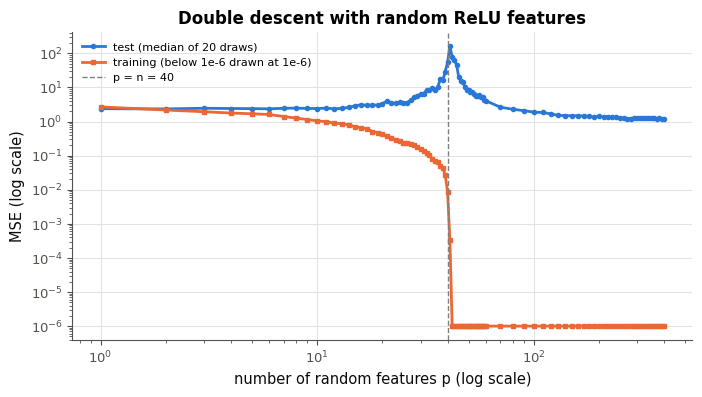

In [71]:
def relu_features_30(X, V, c):
    """The random features max(0, X @ V + c) of the rows of X: one column per column of V (V: (5, p), c: (p,))."""
    return np.maximum(0.0, X @ V + c)


def min_norm_fit_30(F, y):
    """The weights w of smallest norm among those that minimise ||F @ w - y||² (np.linalg.pinv)."""
    return np.linalg.pinv(F) @ y


def double_descent_30(p_grid, n_draws=20, seed=9300):
    """For each of n_draws draws of V (normal, standard deviation 1 / sqrt(5), shape (5, max(p_grid))) and c
    (standard normal, shape (max(p_grid),)): for each p of p_grid, the min-norm fit on the first p random features
    of the 40 training points. Returns two arrays (n_draws, len(p_grid)): the test MSE and the training MSE."""
    rng = np.random.default_rng(seed)
    p_max = max(p_grid)
    test_mse, train_mse = np.empty((n_draws, len(p_grid))), np.empty((n_draws, len(p_grid)))
    for d in range(n_draws):
        V, c = rng.normal(0, 1 / np.sqrt(5), (5, p_max)), rng.normal(0, 1, p_max)
        F_tr, F_te = relu_features_30(X_tr_30, V, c), relu_features_30(X_te_30, V, c)
        for i, p in enumerate(p_grid):
            w = min_norm_fit_30(F_tr[:, :p], y_tr_30)
            test_mse[d, i] = mse(y_te_30, F_te[:, :p] @ w)
            train_mse[d, i] = mse(y_tr_30, F_tr[:, :p] @ w)
    return test_mse, train_mse


if True:
    F_check_30 = relu_features_30(np.array([[1.0, 2.0, 0.0, 0.0, -1.0]]), np.ones((5, 2)), np.array([0.0, -3.0]))
    if returned("9.30", "relu_features_30", F_check_30):
        verdict("9.30", np.shape(F_check_30) == (1, 2) and np.allclose(F_check_30, [[2.0, 0.0]]),
                "relu_features_30 : max(0, 2 + 0) = 2 et max(0, 2 - 3) = 0.",
                f"pour x = (1, 2, 0, 0, -1), V rempli de 1 et c = (0, -3), attendu [[2, 0]] ; reçu {np.asarray(F_check_30).tolist()}.")
    V_30 = np.random.default_rng(1).normal(0, 1 / np.sqrt(5), (5, 100))
    F100_30 = relu_features_30(X_tr_30, V_30, np.random.default_rng(2).normal(0, 1, 100))
    w_30 = min_norm_fit_30(F100_30, y_tr_30)
    if returned("9.30", "min_norm_fit_30", w_30):
        w_30 = np.asarray(w_30, dtype=float)
        exact_30 = np.linalg.pinv(F100_30) @ y_tr_30
        verdict("9.30", w_30.shape == (100,) and np.allclose(w_30, exact_30, atol=1e-6),
                "avec 100 features pour 40 points, ta solution passe par tous les points, avec la plus petite norme.",
                "avec 100 features pour 40 points, attendu la solution de norme minimale, qui passe par tous les points "
                "(np.linalg.pinv(F) @ y).")
        try:
            lstsq_30 = np.asarray(fitted(mylearn.linear.LinearRegression(fit_intercept=False), F100_30, y_tr_30).coef_)
        except NotImplementedError:
            print("⏳ la comparaison avec ta LinearRegression (9.16) s'affichera quand tu l'auras écrite.")
        else:
            verdict("9.30", lstsq_30.shape == (100,) and np.allclose(lstsq_30, exact_30, atol=1e-6),
                    "ta LinearRegression(fit_intercept=False) (9.16) donne la même solution : lstsq rend aussi la "
                    "solution de norme minimale.",
                    "ta LinearRegression(fit_intercept=False) (9.16) devrait donner la même solution de norme minimale "
                    "(np.linalg.lstsq) : relance ses tests.")
    start_30 = time.time()
    result_30 = double_descent_30(P_GRID_30)
    if returned("9.30", "double_descent_30", result_30):
        test_30, train_30 = (np.asarray(part, dtype=float) for part in result_30)
        if test_30.shape != (20, len(P_GRID_30)) or train_30.shape != test_30.shape:
            print(f"❌ Ex 9.30 : attendu deux tableaux (20, {len(P_GRID_30)}) ; reçu {test_30.shape} et {train_30.shape}.")
        else:
            median_30, median_train_30 = np.median(test_30, axis=0), np.median(train_30, axis=0)
            peak_30 = P_GRID_30[int(np.argmax(median_30))]
            before_30 = min(median_30[:P_GRID_30.index(30) + 1])
            print(f"{time.time() - start_30:.1f} s · peak of the median test MSE at p = {peak_30} ({median_30.max():.1f}) · "
                  f"best for p <= 30: {before_30:.2f} · p = 400: {median_30[-1]:.2f}")
            verdict("9.30", 35 <= peak_30 <= 45, f"le pic est à p = {peak_30}, près du seuil d'interpolation p = n = 40.",
                    f"le pic devrait être près de p = n = 40 ; il est à p = {peak_30}.")
            verdict("9.30", median_30[-1] < before_30,
                    "seconde descente : avec 400 features, l'erreur de test passe sous le meilleur résultat d'avant le pic.",
                    "avec 400 features, l'erreur de test devrait repasser sous le meilleur résultat d'avant le pic.")
            verdict("9.30", median_train_30[P_GRID_30.index(50)] < 1e-8,
                    "au-delà de p = n, l'erreur d'entraînement est nulle : le modèle interpole.",
                    "au-delà de p = n, l'erreur d'entraînement devrait être nulle (le modèle interpole).")
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(P_GRID_30, median_30, "o-", ms=3, label="test (median of 20 draws)")
            ax.plot(P_GRID_30, np.maximum(median_train_30, 1e-6), "s-", ms=3, label="training (below 1e-6 drawn at 1e-6)")
            ax.axvline(40, color="gray", ls="--", lw=1, label="p = n = 40")
            ax.set(xscale="log", yscale="log", xlabel="number of random features p (log scale)", ylabel="MSE (log scale)",
                   title="Double descent with random ReLU features")
            ax.legend(fontsize=8)
            plt.show()

💡 Trois régimes. Avec peu de features ($p \ll n$), le modèle est rigide : une erreur de test vers 2,4, pas mieux qu'une constante (2,3). Près de $p = n = 40$, il a juste assez de paramètres pour passer par les 40 points : la solution est unique et doit, pour y arriver, prendre de très grands poids (la norme médiane de $\mathbf{w}$ passe de 7 pour $p = 10$ à 103 pour $p = 41$) ; elle suit le bruit, et l'erreur de test explose (médiane de 164 pour $p = 41$ : quelques-unes des 40 premières features sont nulles sur les 40 points, ou deux d'entre elles ne s'allument que sur un même point, et le rang n'atteint 40 qu'entre $p = 41$ et $p = 44$ selon le tirage). Au-delà, une infinité de solutions interpolent, et celle de plus petite norme a une norme de plus en plus petite (2,6 pour $p = 400$) : la courbe est plus lisse entre les points, et l'erreur redescend, jusqu'à 1,19 pour 400 features, nettement sous le meilleur résultat d'avant le pic (2,35). Une petite pénalité Ridge empêche les poids d'exploser au seuil : avec $\alpha = 0{,}01$, la médiane ne dépasse plus 3,4 ; avec 0,1, le pic disparaît. C'est l'observation de Belkin et coll., et la nuance de Curth et coll. (fiche) : la complexité qui compte, ici, n'est pas le nombre $p$ de paramètres, mais la norme des poids.

### Ex 9.31 — Défi California : le meilleur modèle linéaire régularisé 🏆 ★★★ ⏱️ 90 min
**Objectif :** construire, avec les seules données d'entraînement, un modèle linéaire régularisé qui bat nettement les moindres carrés sur les 8 mesures brutes.  
**Prérequis :** Ex 9.23 · Ex 9.17 · ch. 8 (validation croisée, test une seule fois) · fiche §9.5 et §9.6.4 · **Fil rouge :** California · **Parcours :** C

Prédis la valeur médiane des logements des districts de California avec un **modèle linéaire régularisé** : des features que tu construis à partir des 8 mesures (puissances, produits, logarithmes, distances… : tout ce qui se calcule ligne par ligne), puis `Ridge` ou `Lasso` (les tiens ou ceux de scikit-learn), avec une force de régularisation choisie sur les seules données d'entraînement. Pas d'autre famille de modèles (ni arbres, ni voisins, ni réseaux) : le défi porte sur les features et la régularisation. Les règles :
- tu écris `build_31(X_train, y_train)`, qui renvoie un modèle **entraîné** (avec une méthode `predict`), construit à partir des **seuls** districts qu'elle reçoit (toute statistique, comme un z-score, se calcule sur eux) ;
- `grade_31` (fourni) mesure ta **méthode** par une validation croisée à 5 folds sur les 15 184 districts d'entraînement (`TRAIN_31`) : elle appelle `build_31` sur chaque partie d'entraînement et note la partie de validation ;
- le test (`TEST_31`, 3 796 districts) n'est révélé qu'**une fois** par session, quand tu mets `READY_31 = True` : si tu changes ensuite d'avis, ta note reste celle de la première révélation.

**Objectif : une RMSE d'au plus 0,53 en validation croisée et d'au plus 0,52 sur le test.** Le point de départ fourni, les moindres carrés sur les 8 mesures brutes, fait environ 0,58. Palier bonus 🌟 : au plus 0,49 sur le test (il faut des features mieux pensées ; un indice : la valeur d'un logement dépend beaucoup de l'endroit où il se trouve).

Dans tes notes : ta méthode (features, régularisation, choix de `alpha`), ta RMSE, et le temps de calcul. Pourquoi les features de degré 3 aident-elles ici, alors qu'en 9.28 elles posaient problème ?

In [72]:
SPLIT_31 = np.random.default_rng(931).permutation(len(y_cal))
TEST_31, TRAIN_31 = SPLIT_31[:len(y_cal) // 5], SPLIT_31[len(y_cal) // 5:]   # 3 796 test districts, 15 184 for you
TEST_STATE_31 = {"first": None}                                               # the test is revealed once per session
BASELINE_31 = None                                    # set below: the cross-validated RMSE of the starting point


def grade_31(build, reveal):
    """(result, reason): the RMSE of your METHOD in a 5-fold cross-validation on the training districts (build is
    called on each training part); with reveal=True, the RMSE on the test of build(all the training districts),
    revealed once per session."""
    X_train, y_train = X_cal[TRAIN_31], y_cal[TRAIN_31]
    errors = []
    for tr, va in KFold(5, shuffle=True, random_state=931).split(X_train):
        model = build(X_train[tr].copy(), y_train[tr].copy())
        if model is None or not hasattr(model, "predict"):
            return None, "build_31 doit renvoyer un modèle entraîné, qui a une méthode predict"
        prediction = np.ravel(np.asarray(model.predict(X_train[va]), dtype=float))
        if prediction.shape != (len(va),):
            return None, f"predict doit renvoyer une prédiction par district ({len(va)}), pas {prediction.size}"
        errors.append(mse(y_train[va], prediction))
    result = {"cv": math.sqrt(float(np.mean(errors))), "test": None}
    if BASELINE_31 is not None and abs(result["cv"] - BASELINE_31) < 1e-9:
        return result, "c'est encore le point de départ : le test ne se révèle que pour ta propre méthode"
    if not reveal:
        return result, "le test n'est pas encore révélé : mets READY_31 = True quand ta méthode est arrêtée"
    if TEST_STATE_31["first"] is None:
        model = build(X_train.copy(), y_train.copy())
        TEST_STATE_31["first"] = math.sqrt(mse(y_cal[TEST_31], model.predict(X_cal[TEST_31])))
    else:
        print("⚠️ le test a déjà été révélé dans cette session : ta note reste celle de la première révélation.")
    result["test"] = TEST_STATE_31["first"]
    return result, ""


BASELINE_31 = grade_31(lambda X, y: LinearRegression().fit(X, y), False)[0]["cv"]   # the starting point: about 0.58

In [73]:
class PolyRidge31:
    """Degree-3 polynomial features of the 8 measurements, z-scored with the training rows, then your Ridge."""

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        P = PolynomialFeatures(3, include_bias=False).fit_transform(X)
        self.mean_, self.std_ = P.mean(axis=0), P.std(axis=0)
        self.ridge_ = mylearn.linear.Ridge(alpha=self.alpha)
        self.ridge_.fit((P - self.mean_) / self.std_, y)
        return self

    def predict(self, X):
        return self.ridge_.predict((PolynomialFeatures(3, include_bias=False).fit_transform(X) - self.mean_) / self.std_)


def build_31(X_train, y_train):
    """Choose alpha by a 5-fold cross-validation on the training districts it receives, then refit on all of them."""
    alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
    folds = list(KFold(5, shuffle=True, random_state=0).split(X_train))
    cv_mse = [np.mean([mse(y_train[va], PolyRidge31(alpha).fit(X_train[tr], y_train[tr]).predict(X_train[va]))
                       for tr, va in folds]) for alpha in alphas]
    return PolyRidge31(alphas[int(np.argmin(cv_mse))]).fit(X_train, y_train)


READY_31 = True

if True:
    start_31 = time.time()
    result_31, reason_31 = grade_31(build_31, READY_31)
    if result_31 is None:
        print(f"❌ Ex 9.31 : {reason_31}.")
    else:
        print(f"RMSE of your method in cross-validation: {result_31['cv']:.4f} ({time.time() - start_31:.0f} s)")
    if result_31 is not None and abs(result_31["cv"] - BASELINE_31) < 1e-9:
        print(f"⏳ Ex 9.31 : c'est encore le point de départ (RMSE de {fr(BASELINE_31, 4)} en validation croisée) : "
              "à toi de construire mieux ; le test ne se révèle que pour ta propre méthode.")
    elif result_31 is not None:
        verdict("9.31", result_31["cv"] <= 0.53, f"RMSE de {fr(result_31['cv'], 4)} en validation croisée : objectif atteint.",
                f"RMSE de {fr(result_31['cv'], 4)} en validation croisée : il faut au plus 0,53.")
        if result_31["test"] is None:
            print(f"⏳ Ex 9.31 : {reason_31}.")
        else:
            print(f"RMSE on the 3 796 test districts: {result_31['test']:.4f}")
            verdict("9.31", result_31["test"] <= 0.52, f"RMSE de test de {fr(result_31['test'], 4)} : objectif atteint.",
                    f"RMSE de test de {fr(result_31['test'], 4)} : il faut au plus 0,52.")
            if result_31["test"] <= 0.49:
                print("🌟 Ex 9.31 : moins de 0,49 sur le test : le palier bonus est atteint.")

RMSE of your method in cross-validation: 0.5181 (5 s)
✅ Ex 9.31 : RMSE de 0,5181 en validation croisée : objectif atteint.
RMSE on the 3 796 test districts: 0.5120
✅ Ex 9.31 : RMSE de test de 0,5120 : objectif atteint.


💡 Les moindres carrés sur les 8 mesures brutes font 0,58. Les features de degré 3 (164 colonnes, standardisées avec les districts d'entraînement) et ta `Ridge`, avec `alpha` choisi par validation croisée interne parmi 0,01 à 100, atteignent 0,518 en validation croisée et 0,512 sur le test : l'objectif. Le degré 2 ne suffit pas (environ 0,53 sur le test). Avec 15 000 districts, 164 colonnes ne sur-apprennent presque pas, et une petite pénalité suffit ; en 9.28, avec 500 districts, les mêmes 164 colonnes demandaient une pénalité forte et bien répartie. Pour le palier 🌟, deux features de géographie changent tout : les distances (en degrés) de chaque district à Los Angeles et à San Francisco. Ajoutées aux 8 mesures avant le degré 3, avec la même méthode, elles donnent 0,485 en validation croisée et 0,480 sur le test ; en passant au logarithme ces deux distances (`np.log1p`, puisqu'elles peuvent être nulles) et les quatre colonnes très asymétriques (`AveRooms`, `AveBedrms`, `Population`, `AveOccup`, avec `np.log`), 0,478 et 0,468.

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu dire, à partir de deux erreurs et d'une référence, si un modèle sous-apprend ou sur-apprend, et quoi faire dans chaque cas ?
2. Sais-tu dériver les moindres carrés et Ridge en dimension 1, et expliquer pourquoi le Lasso met des poids exactement à zéro ?
3. Sais-tu calculer le biais² et la variance d'une famille de modèles, et dire pourquoi le compromis biais-variance n'est pas une loi ?

**Pour aller plus loin** : le guide « Linear Models » de scikit-learn et le chapitre 6 d'*An Introduction to Statistical Learning*, cités dans la fiche. La suite : le ch. 10 (neurones), où un modèle linéaire suivi d'une activation devient un neurone.